# Análisis exploratorio del dataset IMS Bearing

El siguiente notebook presenta una análisis exploratorio de experimentos en rodamientos provisto por el centro para mantenimiento de sistemas inteligentes (IMS por sus siglas en inglés).

In [2]:
# librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
# Descarga del dataset subido a google drive
IMS_dataset_path = 'datos/IMS_bearing_dataset'

if os.path.exists(IMS_dataset_path):
    print("El dataset ya se encuentra descargado.")
else:
    print("Descargando el dataset...")
    try:
        import gdown
    except ImportError:
        !pip install gdown

    # https://drive.google.com/file/d/10gqsuR_mHLCniKr2CTtAc1iPNeiNkOdD/view?usp=drive_link
    file_id = "10gqsuR_mHLCniKr2CTtAc1iPNeiNkOdD"
    !gdown --id {file_id} -O NASA_IMS_bearing_dataset.zip


    !mkdir -p datos/IMS_bearing_dataset
    print(f"descomprimiendo el daset en {IMS_dataset_path}...")
    !unzip NASA_IMS_bearing_dataset.zip -d {IMS_dataset_path} >> /dev/null
    !rm NASA_IMS_bearing_dataset.zip
    print("Dataset descargado y descomprimido correctamente.")

El dataset ya se encuentra descargado.


## Funciones útiles

In [4]:
def cargar_archivo(ruta):
  """
    Carga un archivo CSV y asigna nombre a las columnas.

    Esta función lee un archivo CSV desde la ruta proporcionada, asumiendo que
    los valores están separados por tabulaciones ('\t'). Luego, asigna nombres
    genéricos a las columnas del dataset en el formato 'Canal 1', 'Canal 2', ...,
    según la cantidad de columnas que tenga el archivo.

    Args:
        ruta (str): La ruta completa al archivo CSV que se desea cargar.

    Returns:
        pd.DataFrame: Un DataFrame de pandas con los datos cargados, con nombres
        de columnas asignados como 'Canal 1', 'Canal 2', etc.

    Example:
        >>> cargar_archivo('ruta/al/archivo.csv')
        <DataFrame con las columnas renombradas>
  """
  dataset = pd.read_csv(ruta, sep='\t')
  cantidad_columnas = len(dataset.columns)
  dataset.columns = [f"Canal {i}" for i in range(1, cantidad_columnas + 1)]
  return dataset

In [7]:
dataset_path_1st = 'datos/IMS_bearing_dataset/1st_test/1st_test'
dataset_path_2nd = 'datos/IMS_bearing_dataset/2nd_test/2nd_test'
dataset_path_3rd = 'datos/IMS_bearing_dataset/3rd_test/4th_test/txt'

## Exploracion de los datos


In [5]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt # plotting
import numpy as np # linear algebra
import os # accessing directory structure
import pandas as pd # data processing, CSV file
import scipy
from scipy.special import entr
from statsmodels.tsa.ar_model import AutoReg, ar_select_order

In [10]:
dataset = pd.read_csv(f'{dataset_path_2nd}/2004.02.12.10.32.39', sep='\t')
dataset.columns = ['Bearing 1','Bearing 2','Bearing 3','Bearing 4']
dataset.head()

,Bearing 1,Bearing 2,Bearing 3,Bearing 4
0,-0.042,-0.073,-0.007,-0.105
1,0.015,0.000,0.007,0.000
2,-0.051,0.020,-0.002,0.100
3,-0.107,0.010,0.127,0.054
4,-0.078,-0.212,0.042,-0.044


In [12]:
dataset = pd.read_csv(f'{dataset_path_1st}/2003.10.22.12.06.24', sep='\t')
dataset.columns = ['Bearing 1','Bearing 2','Bearing 3','Bearing 4','Bearing 5','Bearing 6','Bearing 7','Bearing 8']
dataset.head()

,Bearing 1,Bearing 2,Bearing 3,Bearing 4,Bearing 5,Bearing 6,Bearing 7,Bearing 8
0,-0.105,-0.017,-0.164,-0.183,-0.049,0.029,-0.115,-0.122
1,-0.183,-0.098,-0.195,-0.125,-0.005,-0.007,-0.171,-0.071
2,-0.178,-0.161,-0.159,-0.178,-0.100,-0.115,-0.112,-0.078
3,-0.208,-0.129,-0.261,-0.098,-0.151,-0.205,-0.063,-0.066
4,-0.232,-0.061,-0.281,-0.125,0.046,-0.088,-0.078,-0.078


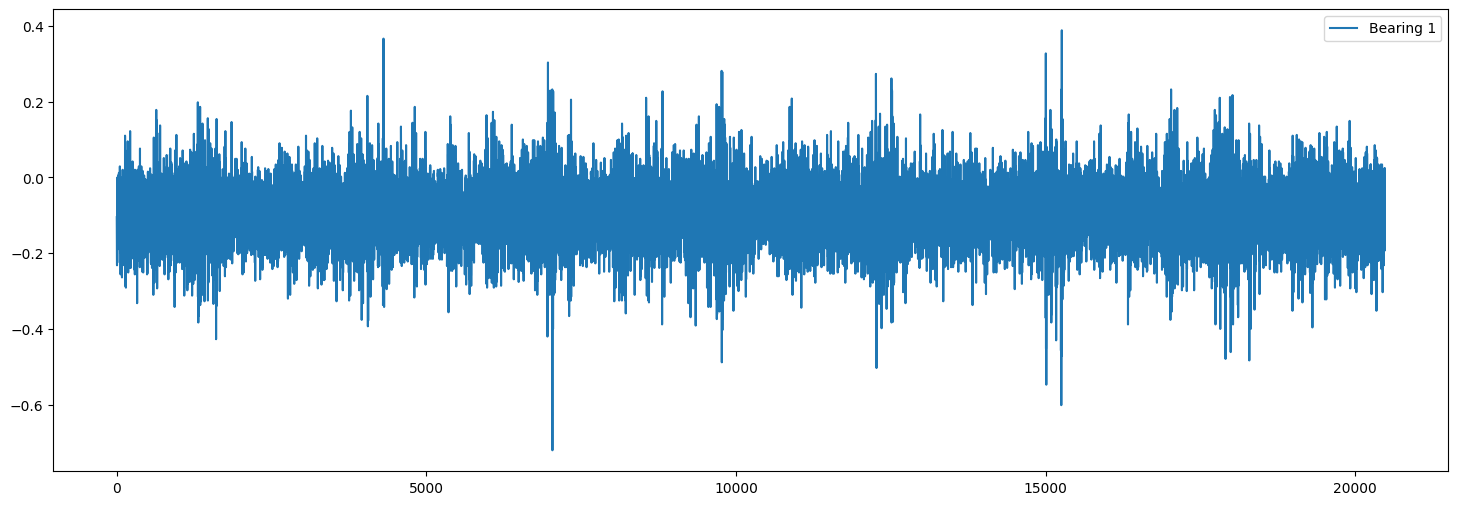

In [13]:
# Señal cruda del rodamiento 1
dataset[['Bearing 1']].plot(figsize=(18,6));

In [15]:
dataset = pd.read_csv(f'{dataset_path_1st}/2003.11.25.23.39.56', sep='\t')
dataset.columns = ['Bearing 1','Bearing 2','Bearing 3','Bearing 4','Bearing 5','Bearing 6','Bearing 7','Bearing 8']
dataset.head()

,Bearing 1,Bearing 2,Bearing 3,Bearing 4,Bearing 5,Bearing 6,Bearing 7,Bearing 8
0,-0.066,-0.068,-0.063,-0.417,-0.271,-0.107,-0.078,-0.081
1,-0.078,-0.154,-0.193,-0.122,-0.254,-0.154,0.034,-0.107
2,-0.146,-0.222,-0.320,0.037,0.205,-0.349,0.090,-0.093
3,-0.083,-0.330,-0.088,-0.176,-0.417,0.103,-0.061,-0.190
4,-0.156,-0.183,0.012,-0.247,-0.667,-0.430,-0.095,0.007


## Revisión de los archivos

A continuación se consulta la cantidad de archivos con mediciones de los sensores con el fin de determinar si es una opción factible combinar los archivos de cada prueba (1st_test, 2nd_test y 3rd_test) y graficarlos para buscar patrones.

In [16]:
# Revisión de los archivos
import os

path_1st_test = 'datos/IMS_bearing_dataset/1st_test/1st_test'
path_2nd_test = 'datos/IMS_bearing_dataset/2nd_test/2nd_test'
path_3rd_test = 'datos/IMS_bearing_dataset/3rd_test/4th_test/txt'

file_list_1st_test = os.listdir(path_1st_test)
file_list_2nd_test = os.listdir(path_2nd_test)
file_list_3rd_test = os.listdir(path_3rd_test)

num_files_1st_test = len(file_list_1st_test)
num_files_2nd_test = len(file_list_2nd_test)
num_files_3rd_test = len(file_list_3rd_test)

print(f'Number of files in {path_1st_test}: {num_files_1st_test}')
print(f'Number of files in {path_2nd_test}: {num_files_2nd_test}')
print(f'Number of files in {path_3rd_test}: {num_files_3rd_test}')


Number of files in datos/IMS_bearing_dataset/1st_test/1st_test: 2156
Number of files in datos/IMS_bearing_dataset/2nd_test/2nd_test: 984
Number of files in datos/IMS_bearing_dataset/3rd_test/4th_test/txt: 6324


Se observa que la tercera prueba fue la que recolectó mayor cantidad de archivos con 6.324, seguida de la primera prueba con 2.156 archivos de 20.000 (aproximadamente) lecturas cada uno. Debido a la gran cantidad de archivos no parece factible combinarlos para realizar las gráficas.

El gran volumen de datos hace que tampoco sea viable generar una gráfica por cada archivo. Por ello se procede a revisar los primeros y los últimos archivos de cada experimento ya que el documento README adjunto indica la presencia de fallas al final de cada experimento.

### Verificación de la longitud de cada archivo
Se procede a verificar la longitud de cada archivo, ya que en el documento [Readme Document for IMS Bearing Data.pdf](https://file.notion.so/f/f/1022c098-f574-4b46-86a3-faf147fb3f26/76e16648-6f57-4f28-9589-caa2c6149a49/Readme_Document_for_IMS_Bearing_Data.pdf?table=block&id=22603b0a-b1d2-80eb-9df2-e5344fa9474c&spaceId=1022c098-f574-4b46-86a3-faf147fb3f26&expirationTimestamp=1753948800000&signature=5eKVFHFalBteXRsy7uQgwUos4nivNGgSFkoi9WjiXdY&downloadName=Readme+Document+for+IMS+Bearing+Data.pdf) se explica que los archivos tienen una longitud aproximada de 20.000 lectura dado que se realizaron mediciones de 1 segundo a 20hz. Con la longitud de cada archivo se espera saber si se requiere hacer alguna adpación a los datos antes de usarlos para alimentar a algún modelo.

In [17]:
def obtener_longitud_archivos(ruta_carpeta):
    """
    Lee todos los archivos CSV/TSV de una carpeta y obtiene la cantidad de filas de cada uno.

    Args:
        ruta_carpeta (str): Ruta absoluta o relativa de la carpeta que contiene los archivos.

    Returns:
        pandas.DataFrame: Un DataFrame con dos columnas:
            - **archivo**: nombre del archivo.
            - **longitud**: número de filas que contiene el archivo.

    Raises:
        NotADirectoryError: Si la ruta proporcionada no es una carpeta válida.
        FileNotFoundError: Si algún archivo no puede ser encontrado al momento de lectura.
        pandas.errors.ParserError: Si el formato de algún archivo no corresponde al esperado.
    """
    if not os.path.isdir(ruta_carpeta):
        raise NotADirectoryError(f"La ruta '{ruta_carpeta}' no es una carpeta válida.")

    file_list = os.listdir(ruta_carpeta)
    if not file_list:
        raise FileNotFoundError(f"No se encontraron archivos en la carpeta '{ruta_carpeta}'.")

    file_data = []
    for file_name in file_list:
        file_path = os.path.join(ruta_carpeta, file_name)
        if not os.path.isfile(file_path):
            raise FileNotFoundError(f"El archivo '{file_path}' no existe o no es un archivo válido.")

        df = pd.read_csv(file_path, sep='\t', header=None)  # Asume separación por tabulador
        total_faltantes = df.isna().sum().sum()
        file_data.append({'archivo': file_name, 'longitud': len(df), 'faltantes': total_faltantes})

    return pd.DataFrame(file_data)



In [18]:
metadata_archivos_1st_test = obtener_longitud_archivos('datos/IMS_bearing_dataset/1st_test/1st_test')
metadata_archivos_2nd_test = obtener_longitud_archivos('datos/IMS_bearing_dataset/2nd_test/2nd_test')
metadata_archivos_3rd_test = obtener_longitud_archivos('datos/IMS_bearing_dataset/3rd_test/4th_test/txt')


In [19]:
print(f"Longitud de archivos en 1st_test: {metadata_archivos_1st_test['longitud'].unique()}")
print(f"Datos faltantes en 1st_test: {metadata_archivos_1st_test['faltantes'].sum()}")

print()
print(f"Longitud de archivos en 2nd_test: {metadata_archivos_2nd_test['longitud'].unique()}")
print(f"Datos faltantes en 2nd_test: {metadata_archivos_2nd_test['faltantes'].sum()}")

print()
print(f"Longitud de archivos en 3rd_test: {metadata_archivos_3rd_test['longitud'].unique()}")
print(f"Datos faltantes en 3rd_test: {metadata_archivos_3rd_test['faltantes'].sum()}")

Longitud de archivos en 1st_test: [20480]
Datos faltantes en 1st_test: 0

Longitud de archivos en 2nd_test: [20480]
Datos faltantes en 2nd_test: 0

Longitud de archivos en 3rd_test: [20480]
Datos faltantes en 3rd_test: 0


Se pudo validar que todos los archivos tienen una longitud de 20480 mediciones.



# Gráficas de los primeros archivos de cada prueba

Ya se observó que cada prueba recolectó una basta cantidad de archivos con mediciones por lo que se plantea ahora graficar sólo los primeros archivos de cada prueba correspondientes a las etapas finales de los experimentos.

Con este análisis se espera observar la forma de señal de las mediciones realizadas en los rodamientos. Al inicio de los experimentos los rodamientos se encontraban en óptimas condiciones, por ello las siguientes gráficas muestran la operación normal de los rodamientos.

In [20]:
# Impresión del nombre de los últimos archivos de cada prueba
copy_files_1st_test = file_list_1st_test.copy()
copy_files_2nd_test = file_list_2nd_test.copy()
copy_files_3rd_test = file_list_3rd_test.copy()

copy_files_1st_test.sort()
copy_files_2nd_test.sort()
copy_files_3rd_test.sort()

print(f"Primer archivo en 1st_test: {copy_files_1st_test[0]}")
print(f"Primer archivo en 2nd_test: {copy_files_2nd_test[0]}")
print(f"Primer archivo en 3rd_test: {copy_files_3rd_test[0]}")


Primer archivo en 1st_test: 2003.10.22.12.06.24
Primer archivo en 2nd_test: 2004.02.12.10.32.39
Primer archivo en 3rd_test: 2004.03.04.09.27.46


## Gráfica de 1st_test

In [21]:
dataset = pd.read_csv(f'{path_1st_test}/2003.10.22.12.06.24', sep='\t')
dataset.columns = ['Canal 1','Canal 2','Canal 3','Canal 4','Canal 5','Canal 6','Canal 7','Canal 8']
dataset.head()


,Canal 1,Canal 2,Canal 3,Canal 4,Canal 5,Canal 6,Canal 7,Canal 8
0,-0.105,-0.017,-0.164,-0.183,-0.049,0.029,-0.115,-0.122
1,-0.183,-0.098,-0.195,-0.125,-0.005,-0.007,-0.171,-0.071
2,-0.178,-0.161,-0.159,-0.178,-0.100,-0.115,-0.112,-0.078
3,-0.208,-0.129,-0.261,-0.098,-0.151,-0.205,-0.063,-0.066
4,-0.232,-0.061,-0.281,-0.125,0.046,-0.088,-0.078,-0.078


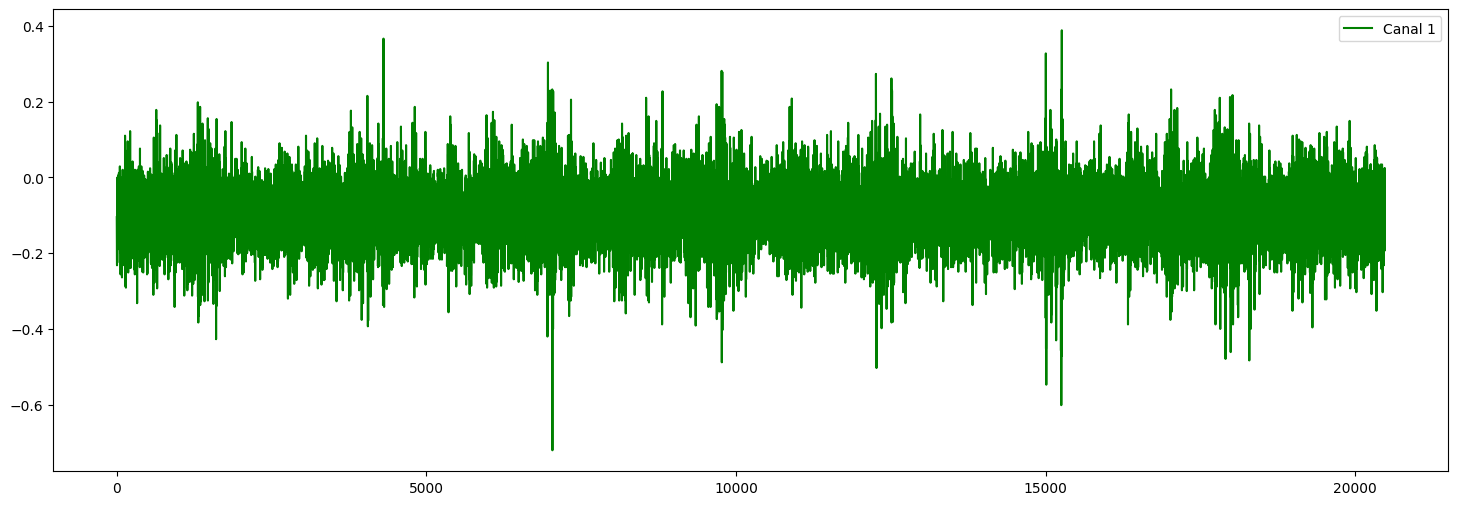

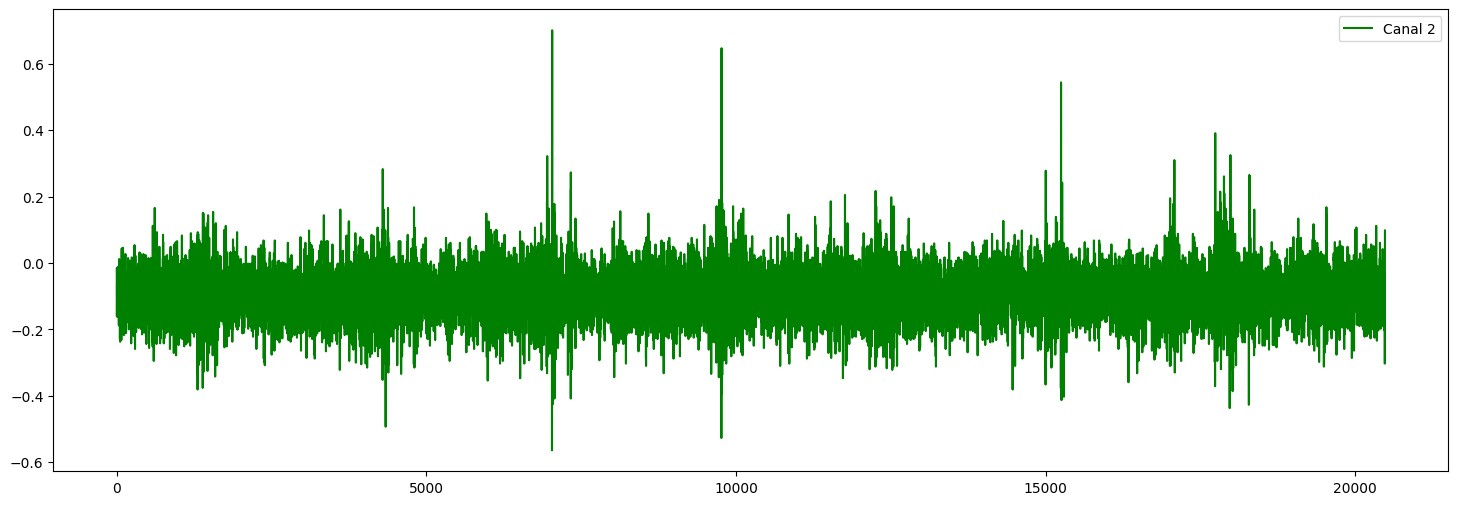

In [22]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 1
dataset[['Canal 1']].plot(figsize=(18,6), color='green');
dataset[['Canal 2']].plot(figsize=(18,6), color='green');

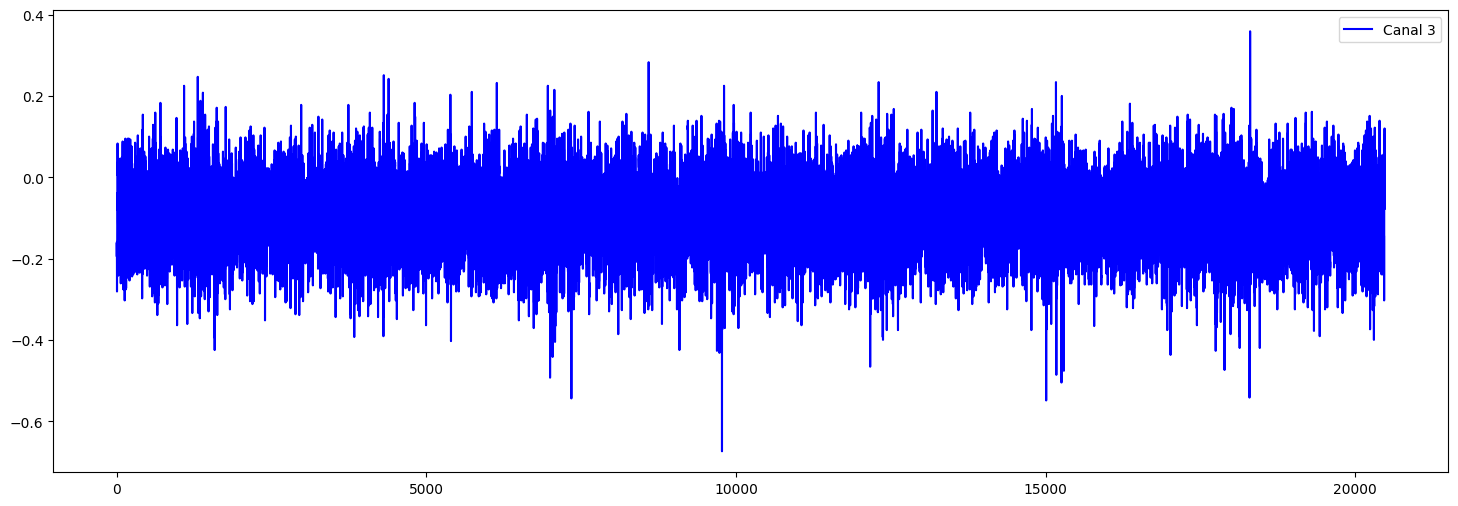

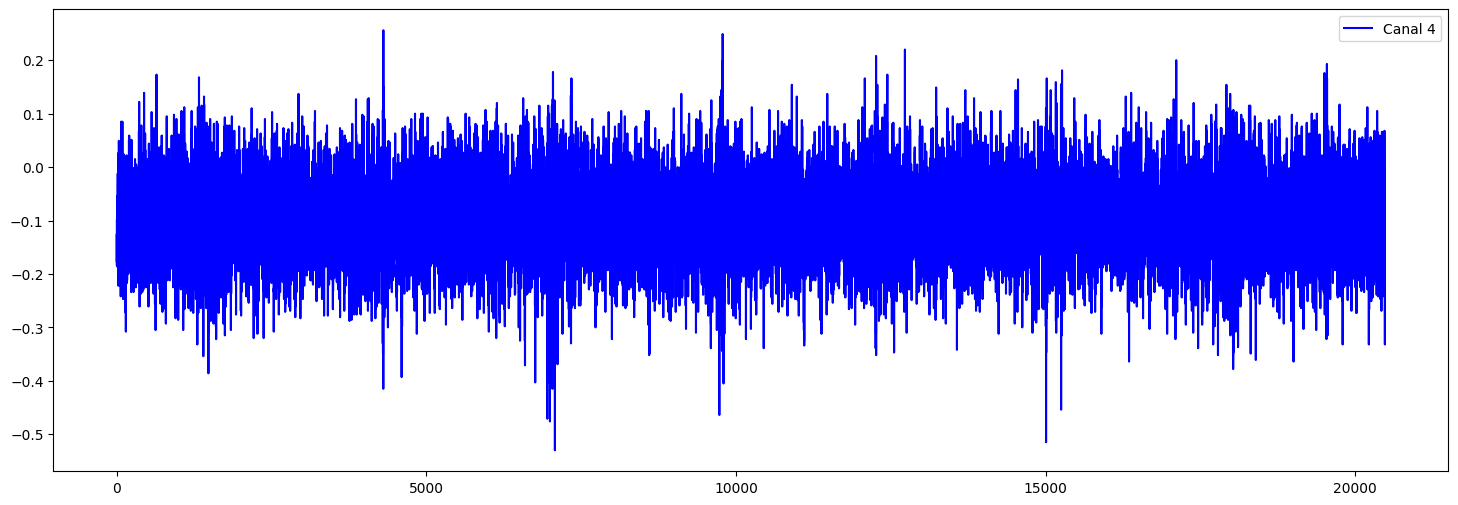

In [23]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 2
dataset[['Canal 3']].plot(figsize=(18,6), color='blue');
dataset[['Canal 4']].plot(figsize=(18,6), color='blue');

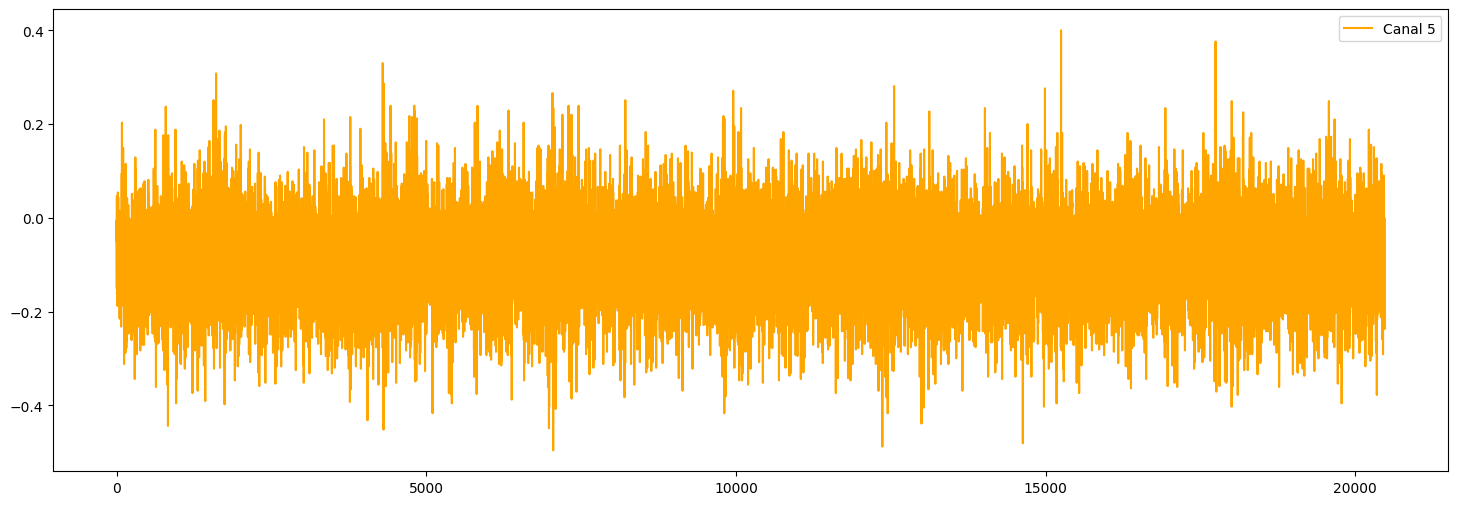

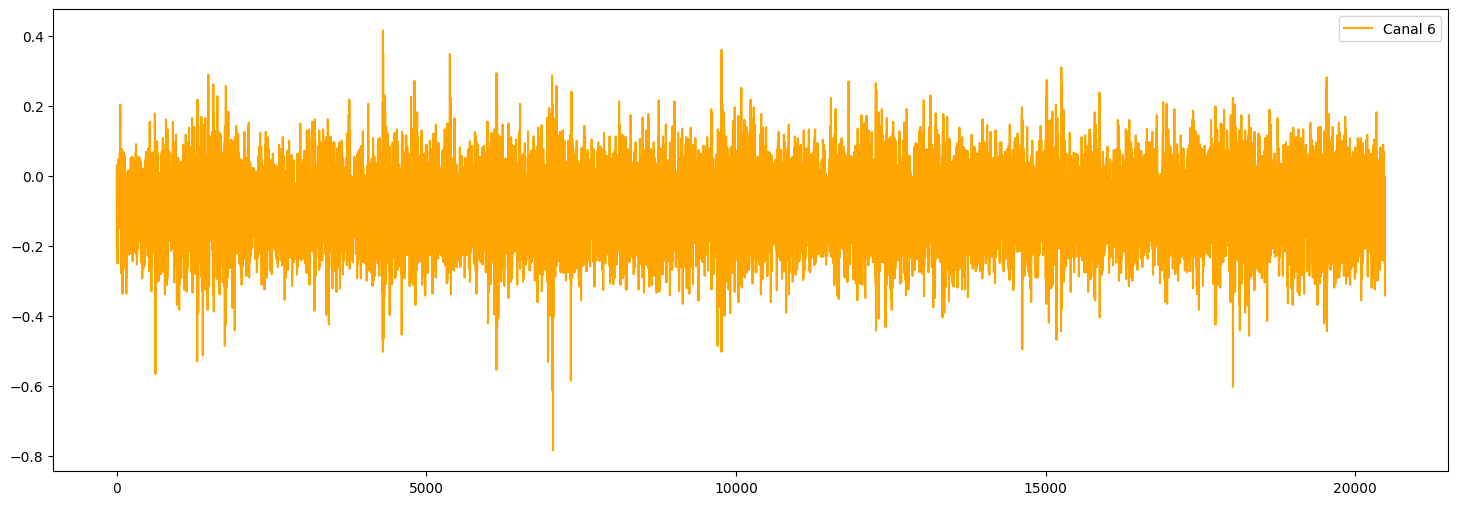

In [24]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 3 (Falla en la pista interior)
dataset[['Canal 5']].plot(figsize=(18,6), color='orange');
dataset[['Canal 6']].plot(figsize=(18,6), color='orange');

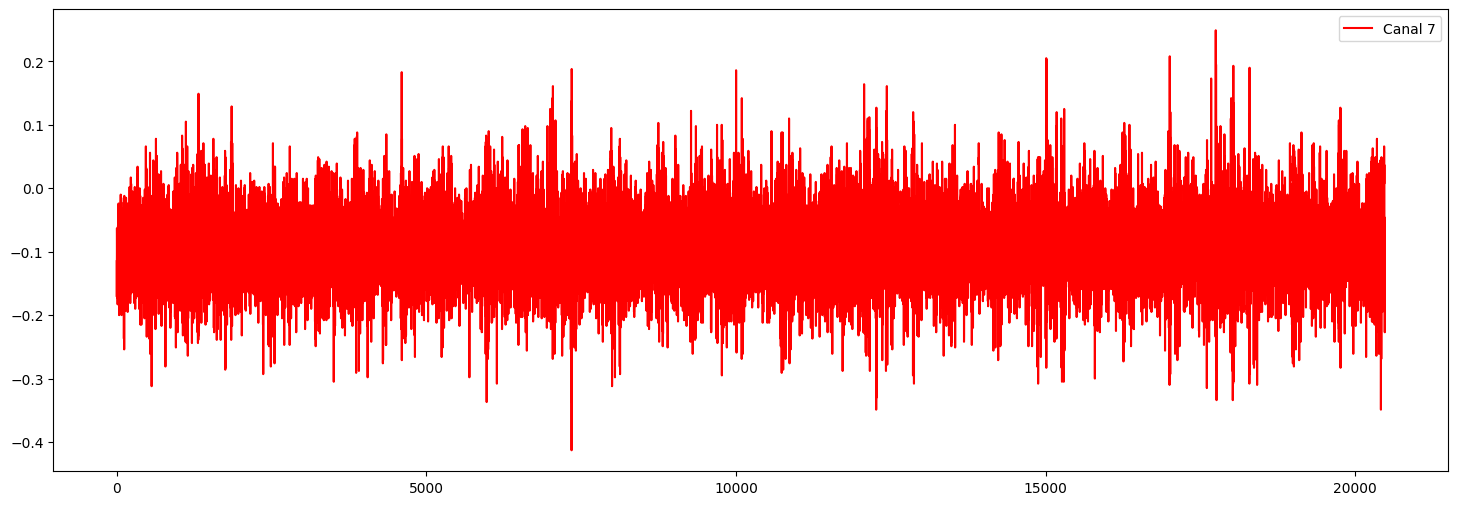

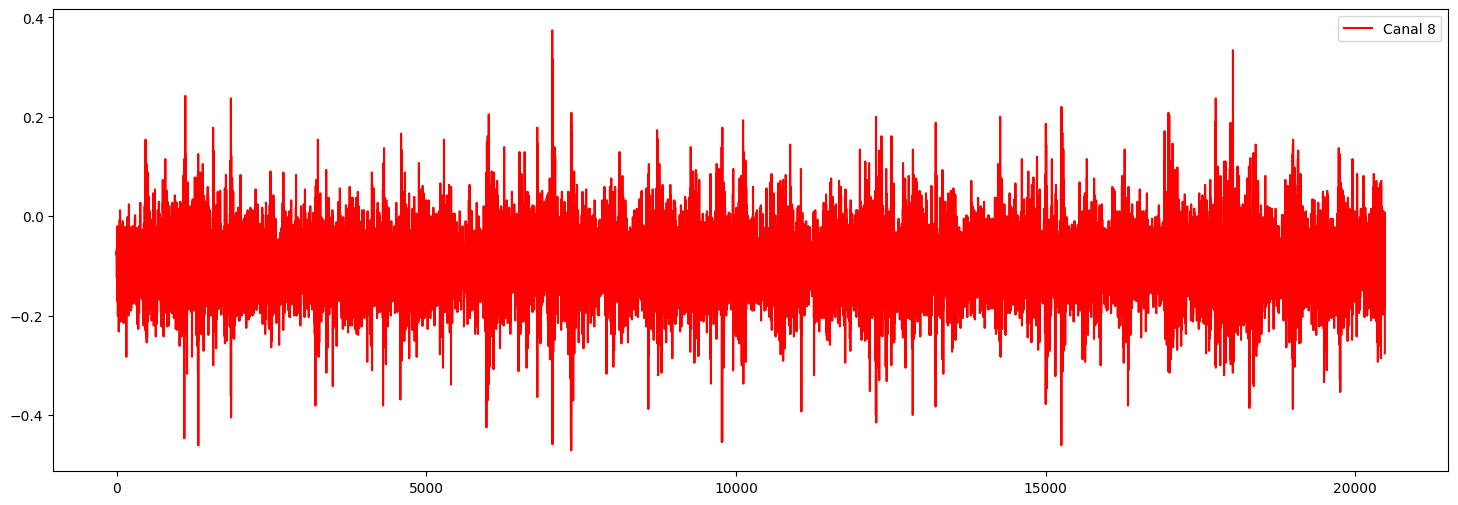

In [25]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 4 (defecto en el elemento rodante )
dataset[['Canal 7']].plot(figsize=(18,6), color='red');
dataset[['Canal 8']].plot(figsize=(18,6), color='red');

## Gráfica de 2nd_test

* Contienen 4 sensores montados en 4 rodamientos
* Al final del experimento  el rodamiento 1 presentó una falla en la pista exterior.

In [26]:
pd.read_csv(f'{path_2nd_test}/2004.02.12.10.32.39', sep='\t')

,-0.049,-0.071,-0.132,-0.010
0,-0.042,-0.073,-0.007,-0.105
1,0.015,0.000,0.007,0.000
2,-0.051,0.020,-0.002,0.100
3,-0.107,0.010,0.127,0.054
4,-0.078,-0.212,0.042,-0.044
...,...,...,...,...
20474,0.049,-0.051,-0.039,-0.044
20475,0.037,0.061,0.115,0.007
20476,-0.012,0.007,0.056,-0.007
20477,-0.012,0.093,0.017,-0.044


In [27]:
dataset = pd.read_csv(f'{path_2nd_test}/2004.02.12.10.32.39', sep='\t')
dataset.columns = ['Canal 1','Canal 2','Canal 3','Canal 4']
dataset.head()


,Canal 1,Canal 2,Canal 3,Canal 4
0,-0.042,-0.073,-0.007,-0.105
1,0.015,0.000,0.007,0.000
2,-0.051,0.020,-0.002,0.100
3,-0.107,0.010,0.127,0.054
4,-0.078,-0.212,0.042,-0.044


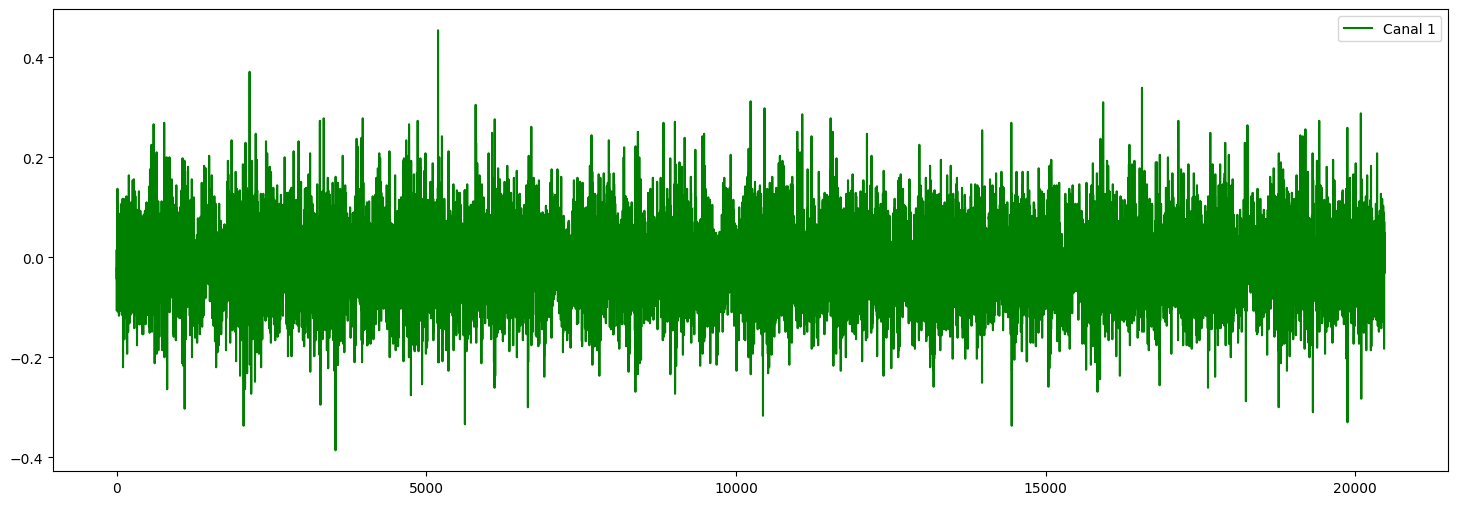

In [28]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 1 (Falla en la pista exterior)
dataset[['Canal 1']].plot(figsize=(18,6), color='green');

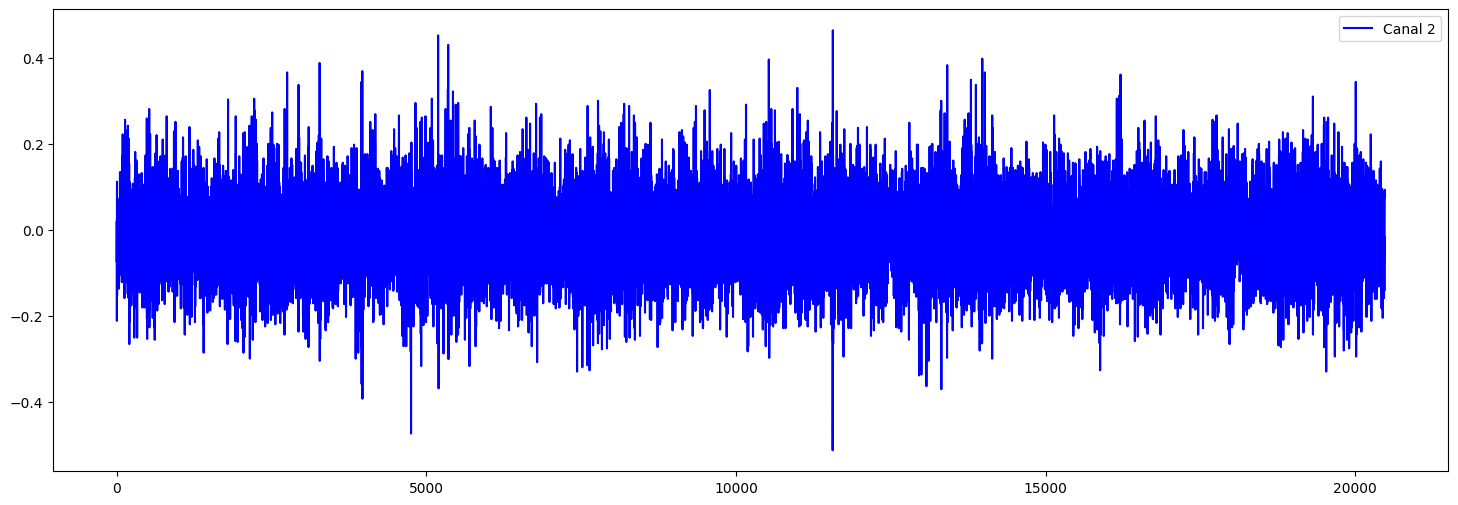

In [29]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 2
dataset[['Canal 2']].plot(figsize=(18,6), color='blue');

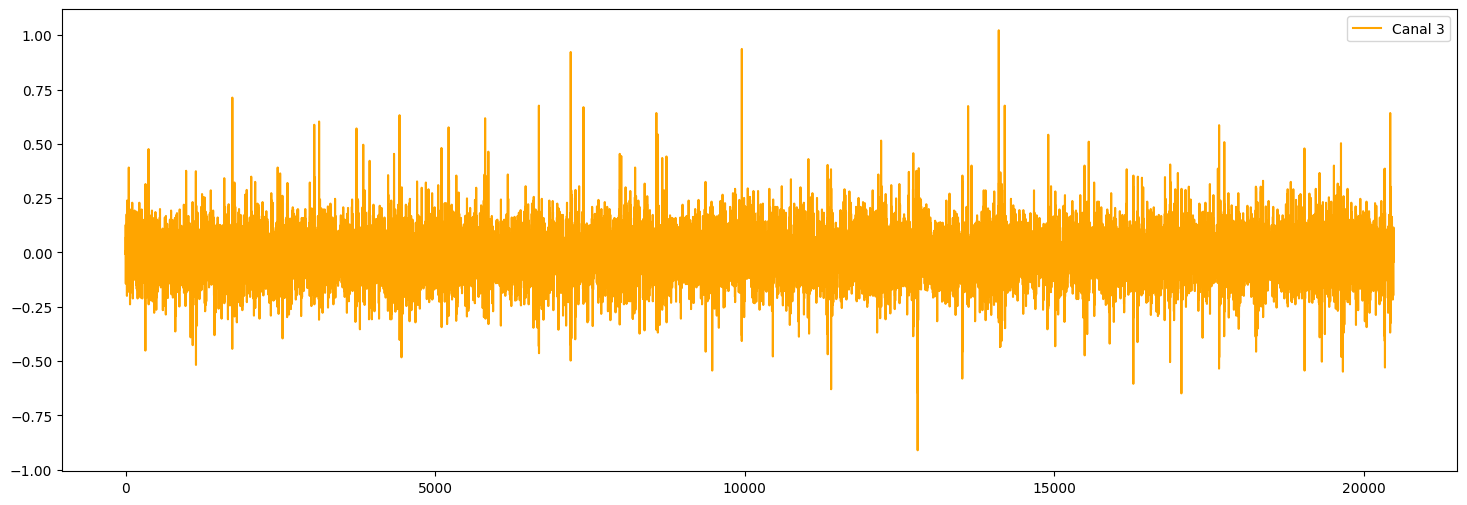

In [30]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 3
dataset[['Canal 3']].plot(figsize=(18,6), color='orange');

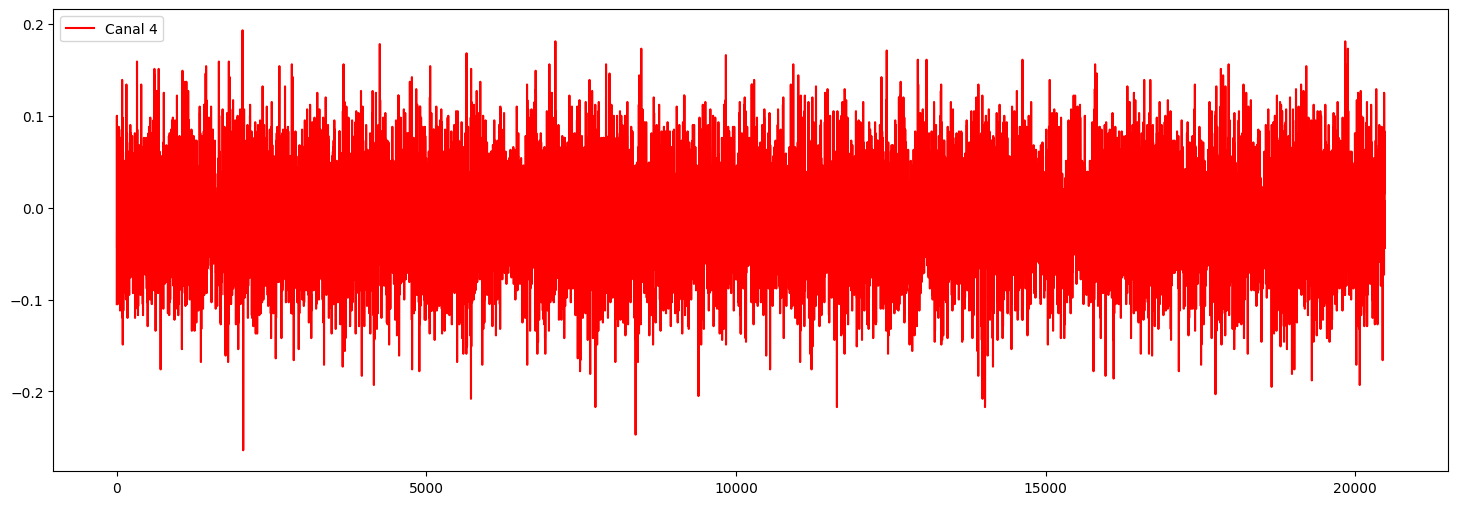

In [31]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 4
dataset[['Canal 4']].plot(figsize=(18,6), color='red');

## Gráfica de 3rd_test


In [32]:
dataset = pd.read_csv(f'{path_3rd_test}/2004.03.04.09.27.46', sep='\t')
dataset.columns = ['Canal 1','Canal 2','Canal 3','Canal 4']
dataset.head()


,Canal 1,Canal 2,Canal 3,Canal 4
0,0.103,0.083,-0.061,-0.012
1,0.095,-0.039,-0.007,0.039
2,0.000,0.110,0.022,-0.002
3,0.005,0.154,-0.127,-0.020
4,0.010,0.027,-0.007,-0.039


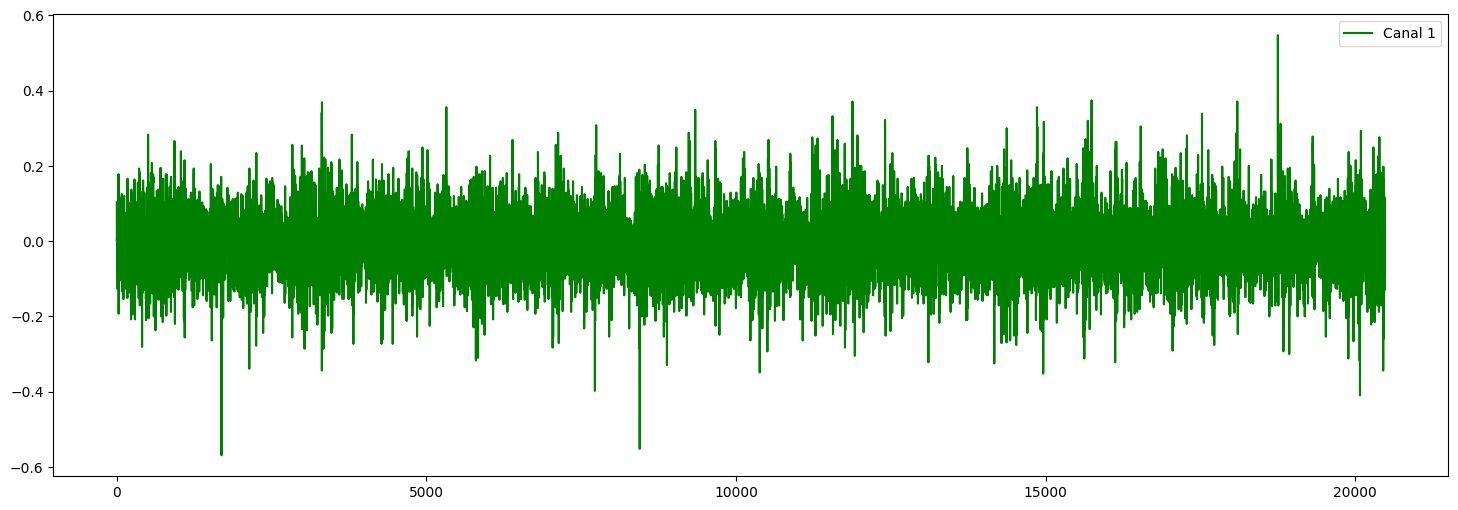

In [33]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 1 (Falla en la pista exterior)
dataset[['Canal 1']].plot(figsize=(18,6), color='green');

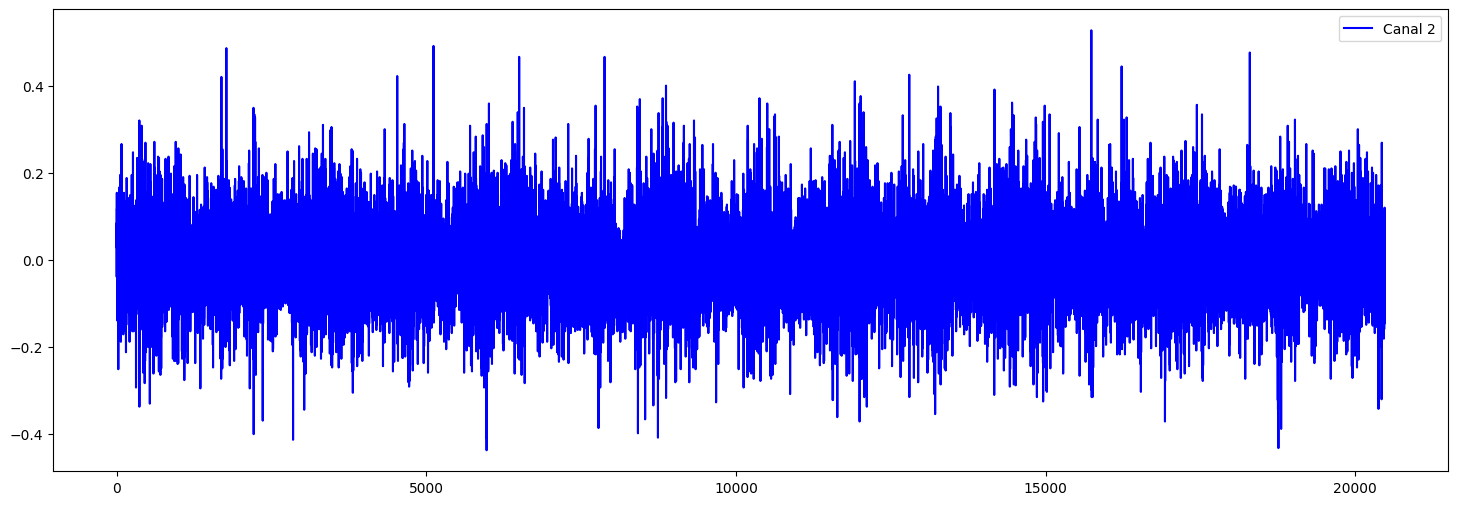

In [34]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 2
dataset[['Canal 2']].plot(figsize=(18,6), color='blue');

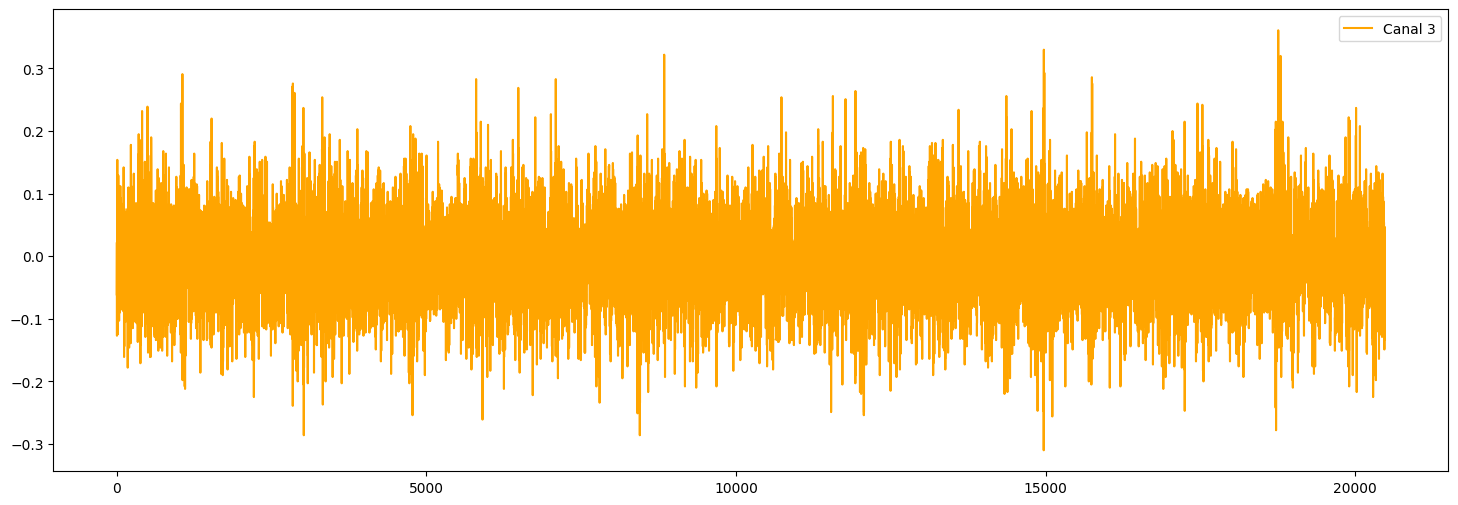

In [35]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 3 (falla en la pista exterior)
dataset[['Canal 3']].plot(figsize=(18,6), color='orange');

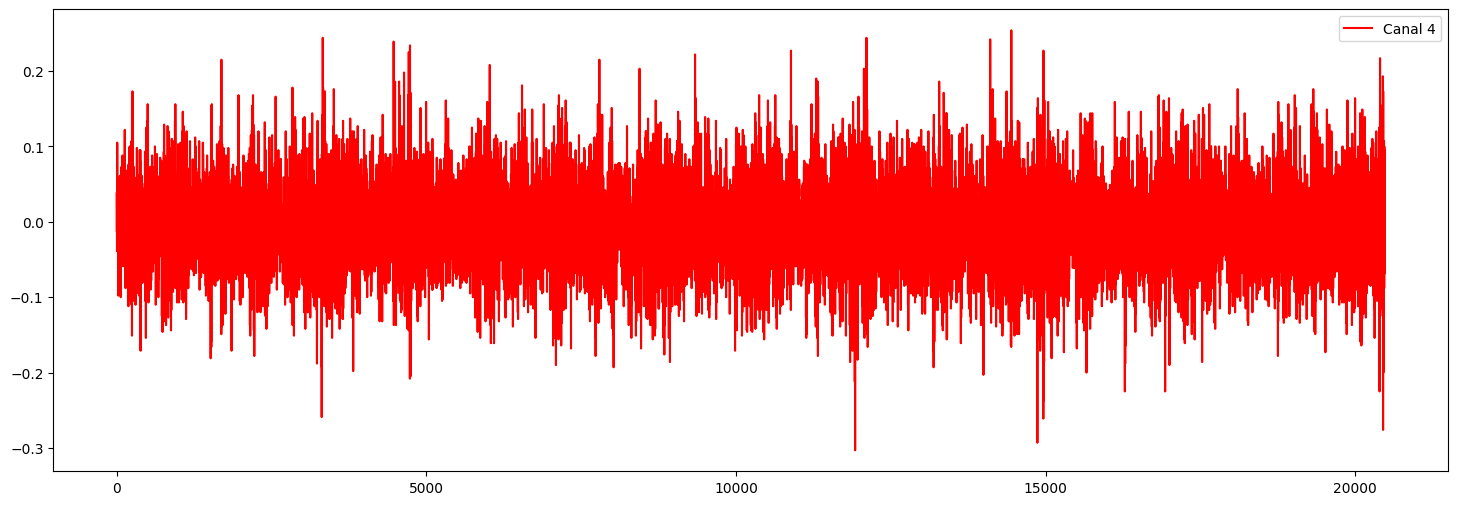

In [36]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 4
dataset[['Canal 4']].plot(figsize=(18,6), color='red');

## Análisis

Las gráficas de los 3 experimentos tienen formas de señales muy variadas con picos muy marcados.

# Gráficas de los últimos archivos de cada prueba

Ya se observó que cada prueba recolectó una basta cantidad de archivos con mediciones por lo que se plantea ahora graficar sólo los últimos archivos de cada prueba correspondientes a las etapas finales de los experimentos.

Se espera observar las fallas descritas en el archivo [Readme Document for IMS Bearing Data.pdf](https://file.notion.so/f/f/1022c098-f574-4b46-86a3-faf147fb3f26/76e16648-6f57-4f28-9589-caa2c6149a49/Readme_Document_for_IMS_Bearing_Data.pdf?table=block&id=22603b0a-b1d2-80eb-9df2-e5344fa9474c&spaceId=1022c098-f574-4b46-86a3-faf147fb3f26&expirationTimestamp=1753948800000&signature=5eKVFHFalBteXRsy7uQgwUos4nivNGgSFkoi9WjiXdY&downloadName=Readme+Document+for+IMS+Bearing+Data.pdf) adjunto al conjunto de datos:
* **1st_test**: Falla en la pista interior del rodamiento 3 y un defecto en el elemento rodante del rodamiento 4.
* **2nd_test**: Falla en la pista exterior del rodamiento 1.
* **3rd_test**: Falla en la pista exterior del rodamiento 3.

In [37]:
# Impresión del nombre de los últimos archivos de cada prueba
copy_files_1st_test = file_list_1st_test.copy()
copy_files_2nd_test = file_list_2nd_test.copy()
copy_files_3rd_test = file_list_3rd_test.copy()

copy_files_1st_test.sort()
copy_files_2nd_test.sort()
copy_files_3rd_test.sort()

print(f"Último archivo en 1st_test: {copy_files_1st_test[-1]}")
print(f"Último archivo en 2nd_test: {copy_files_2nd_test[-1]}")
print(f"Último archivo en 3rd_test: {copy_files_3rd_test[-1]}")


Último archivo en 1st_test: 2003.11.25.23.39.56
Último archivo en 2nd_test: 2004.02.19.06.22.39
Último archivo en 3rd_test: 2004.04.18.02.42.55


## Gráfica de 1st_test


* Contienen 8 sensores montados en 4 rodamientos:
  * Rodamiento 1 tiene los sensores 1 y 2
  * Rodamiento 2 tiene los sensores 3 y 4
  * Rodamiento 3 tiene los sensores 5 y 6
  * Rodamiento 4 tiene los sensores 7 y 8
* Al final de esta prueba el rodamiento 3 presentó una falla en la pista interior y el rodamiento 4 un defecto en el elemento rodante.

In [38]:
dataset = pd.read_csv(f'{path_1st_test}/2003.11.25.23.39.56', sep='\t')
dataset.columns = ['Canal 1','Canal 2','Canal 3','Canal 4','Canal 5','Canal 6','Canal 7','Canal 8']
dataset.head()


,Canal 1,Canal 2,Canal 3,Canal 4,Canal 5,Canal 6,Canal 7,Canal 8
0,-0.066,-0.068,-0.063,-0.417,-0.271,-0.107,-0.078,-0.081
1,-0.078,-0.154,-0.193,-0.122,-0.254,-0.154,0.034,-0.107
2,-0.146,-0.222,-0.320,0.037,0.205,-0.349,0.090,-0.093
3,-0.083,-0.330,-0.088,-0.176,-0.417,0.103,-0.061,-0.190
4,-0.156,-0.183,0.012,-0.247,-0.667,-0.430,-0.095,0.007


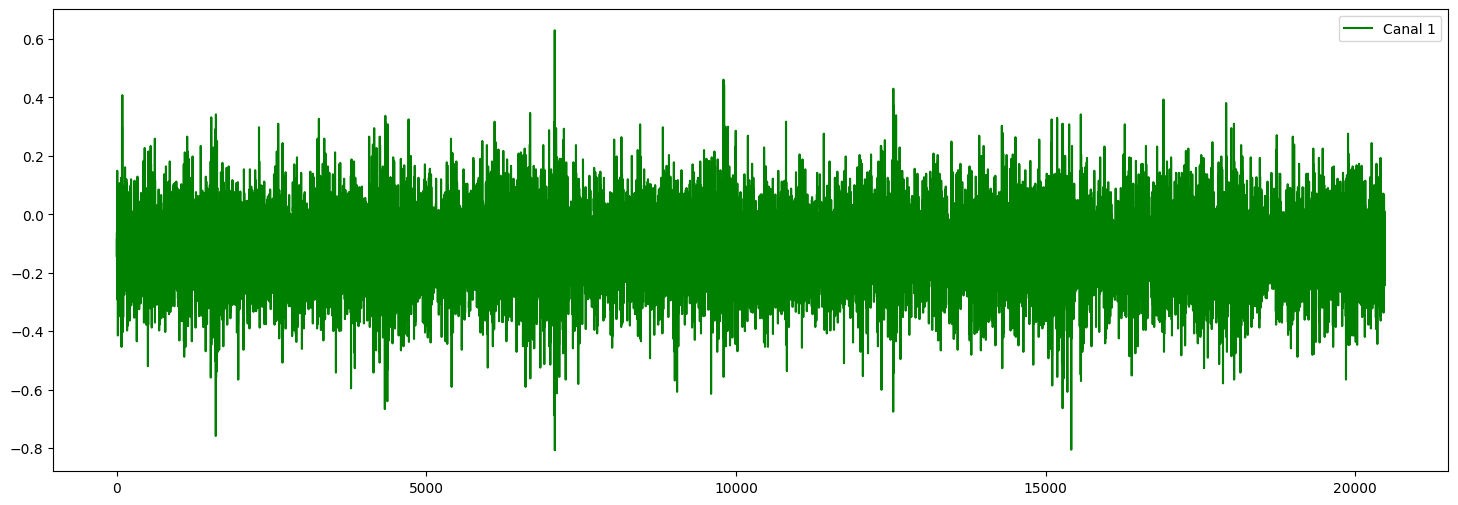

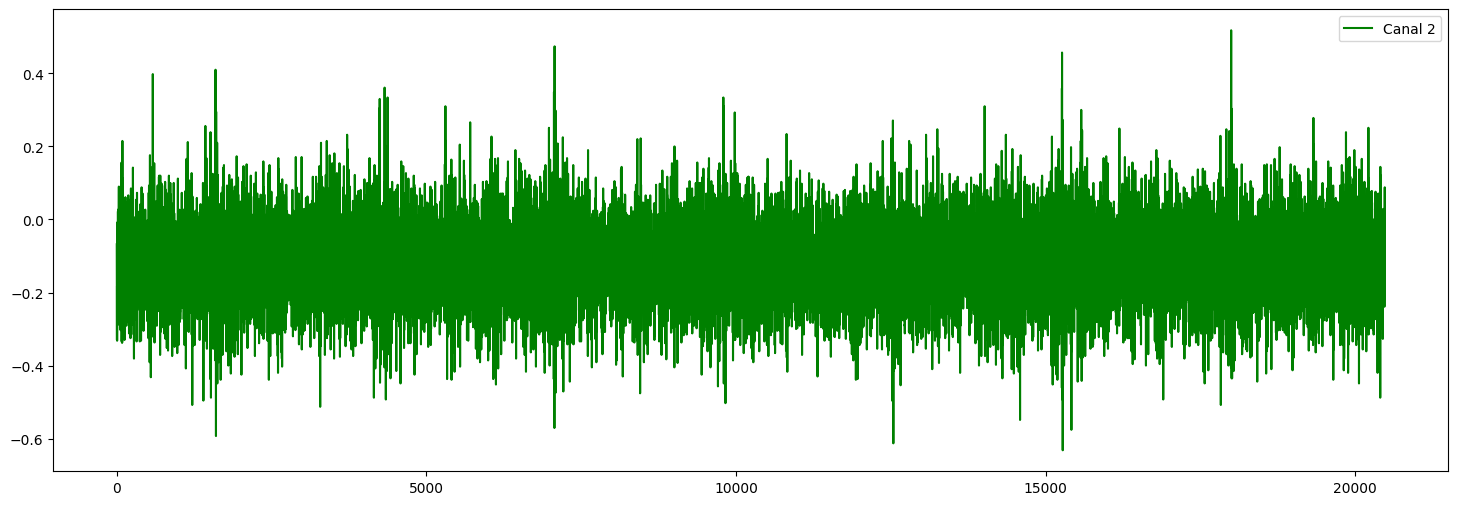

In [39]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 1
dataset[['Canal 1']].plot(figsize=(18,6), color='green');
dataset[['Canal 2']].plot(figsize=(18,6), color='green');

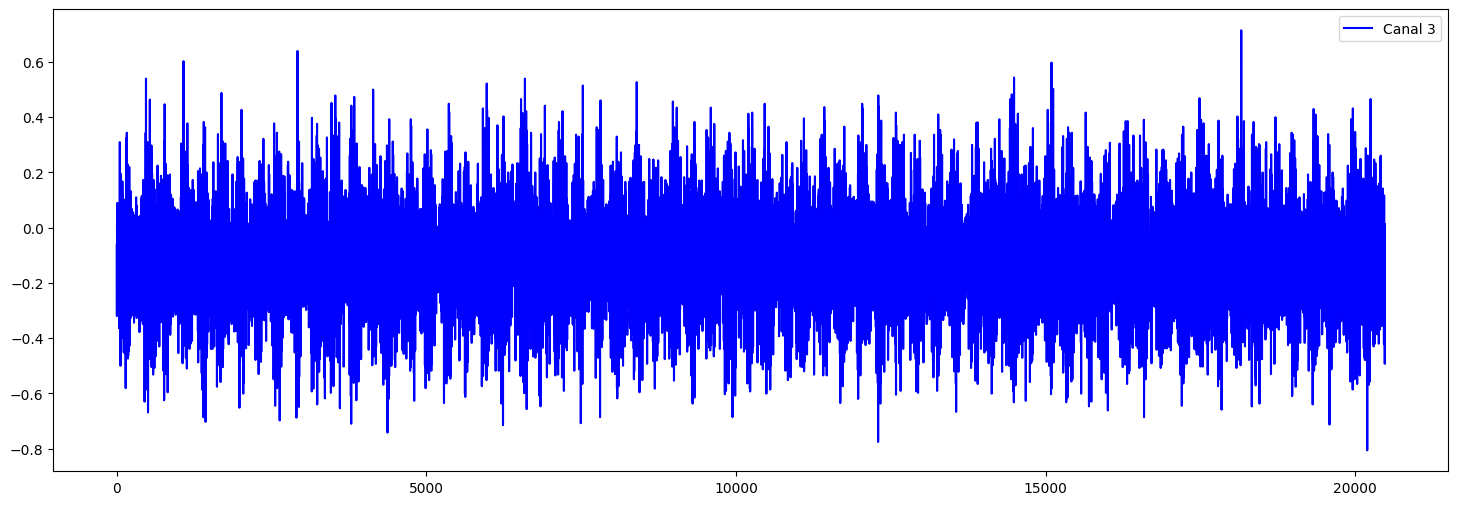

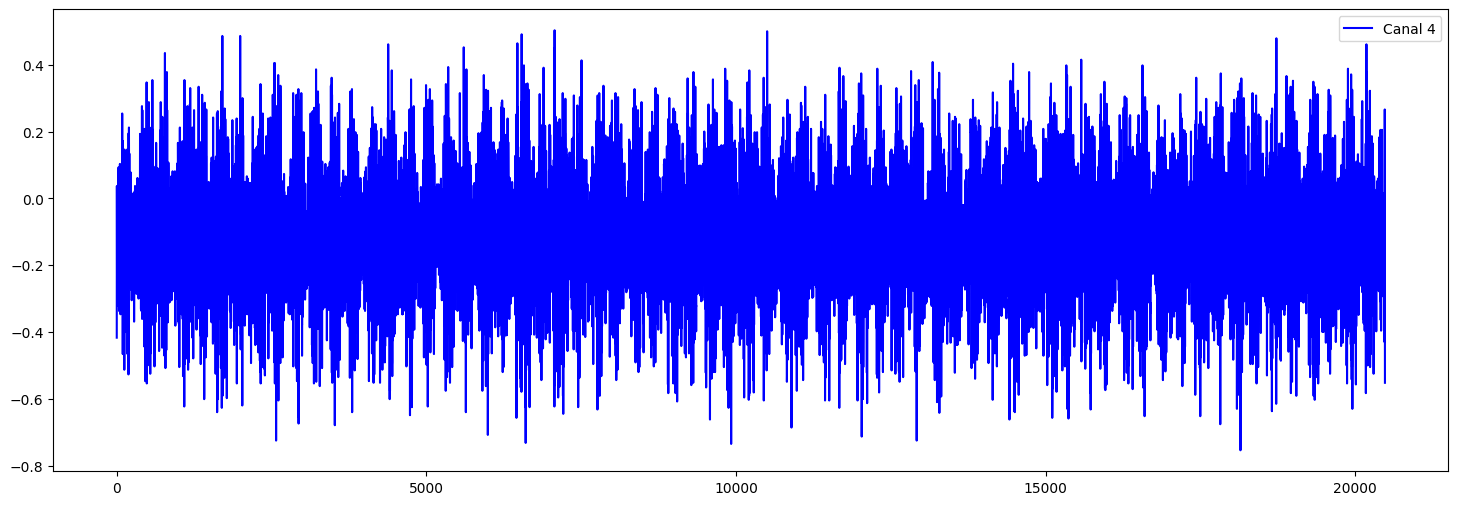

In [40]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 2
dataset[['Canal 3']].plot(figsize=(18,6), color='blue');
dataset[['Canal 4']].plot(figsize=(18,6), color='blue');

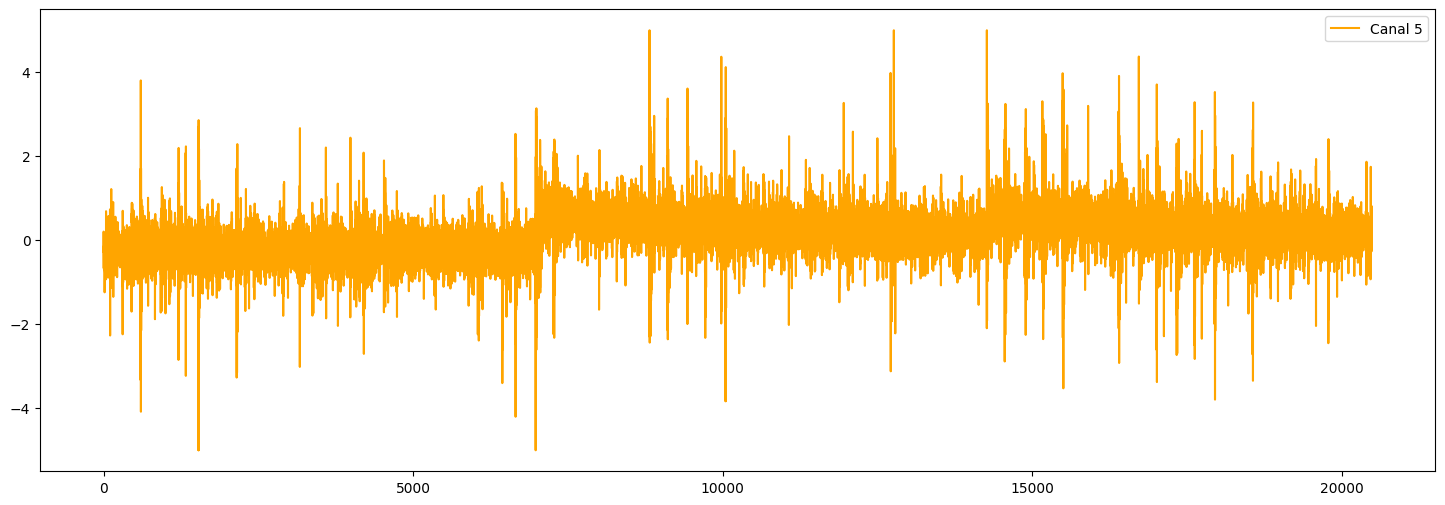

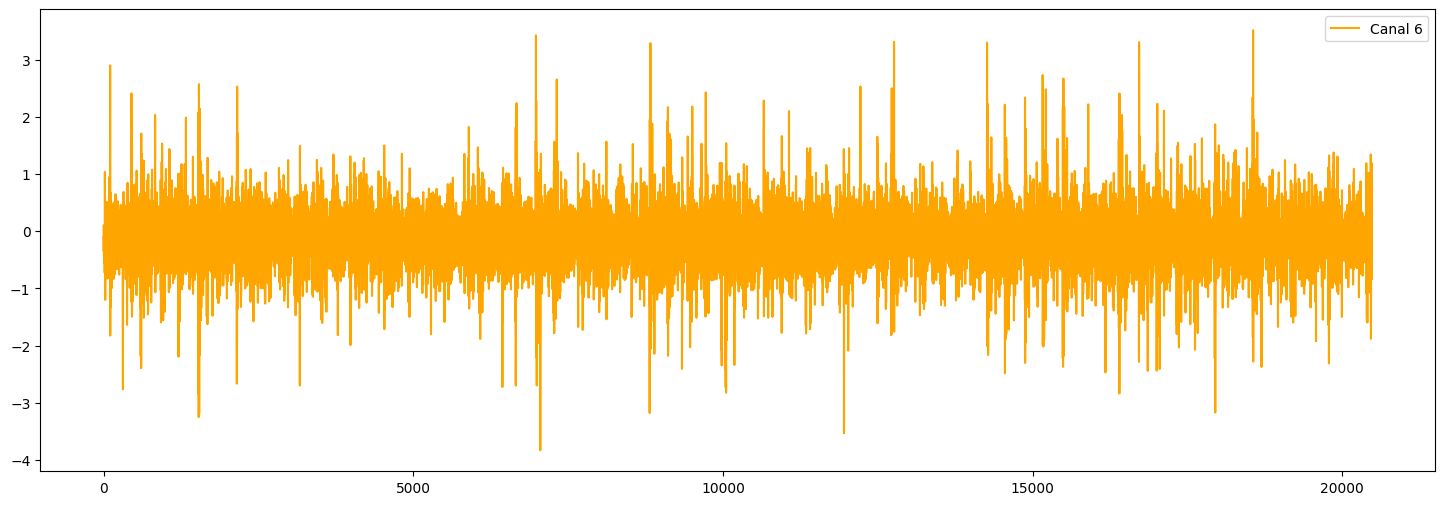

In [41]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 3 (Falla en la pista interior)
dataset[['Canal 5']].plot(figsize=(18,6), color='orange');
dataset[['Canal 6']].plot(figsize=(18,6), color='orange');

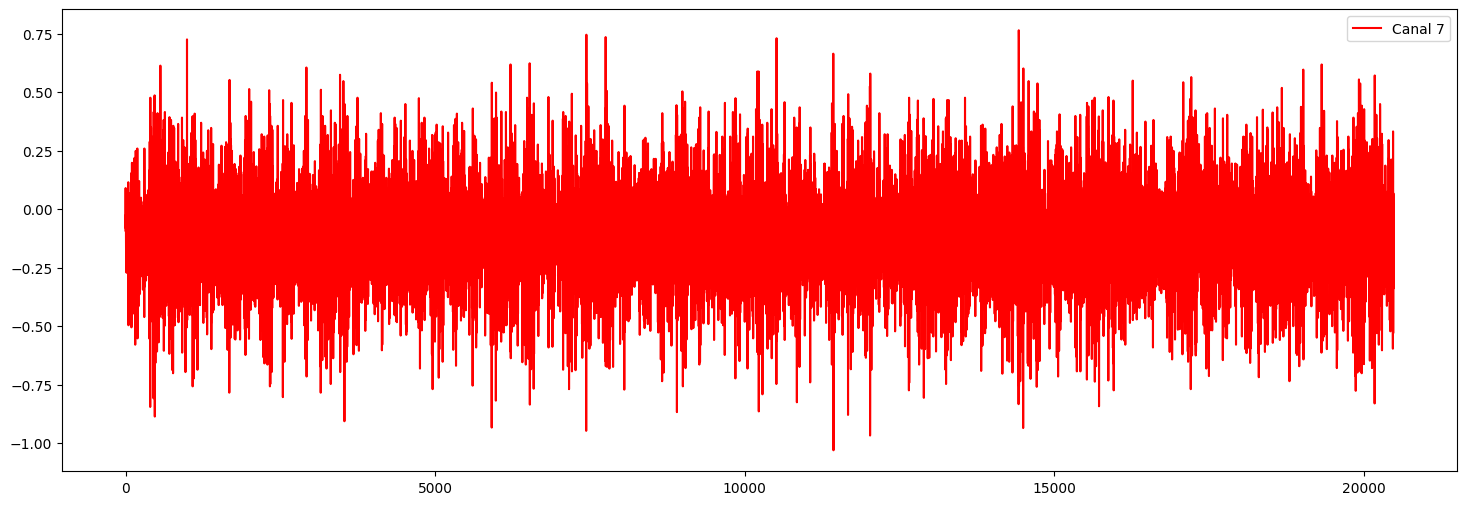

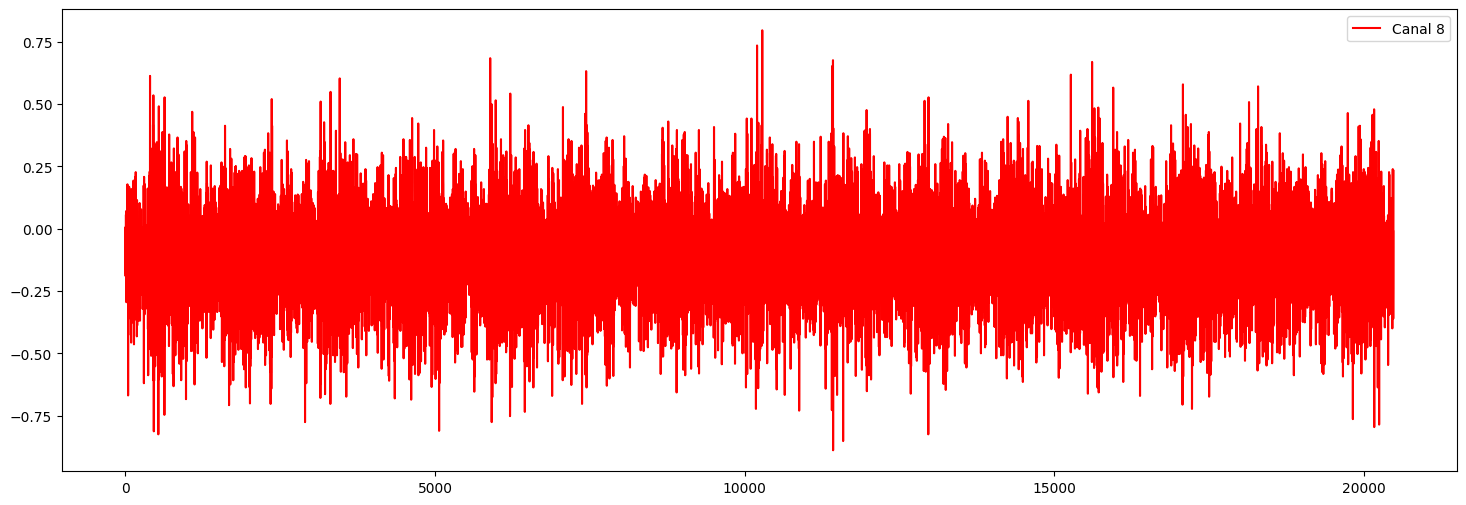

In [42]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 4 (defecto en el elemento rodante )
dataset[['Canal 7']].plot(figsize=(18,6), color='red');
dataset[['Canal 8']].plot(figsize=(18,6), color='red');

## Gráfica de 2nd_test

* Contienen 4 sensores montados en 4 rodamientos
* Al final del experimento  el rodamiento 1 presentó una falla en la pista exterior.

In [43]:
pd.read_csv(f'{path_2nd_test}/2004.02.19.06.22.39', sep='\t')

,-0.002,-0.002.1,-0.002.2,-0.002.3
0,-0.002,-0.002,0.000,-0.002
1,-0.002,-0.002,-0.002,0.000
2,-0.002,-0.002,-0.002,0.000
3,0.000,-0.002,-0.002,-0.002
4,-0.002,-0.002,-0.002,0.000
...,...,...,...,...
20474,-0.002,-0.002,-0.002,-0.002
20475,-0.002,-0.002,0.000,-0.002
20476,-0.002,0.000,0.000,-0.002
20477,-0.002,-0.002,0.000,-0.002


In [44]:
dataset = pd.read_csv(f'{path_2nd_test}/2004.02.19.06.22.39', sep='\t')
dataset.columns = ['Canal 1','Canal 2','Canal 3','Canal 4']
dataset.head()


,Canal 1,Canal 2,Canal 3,Canal 4
0,-0.002,-0.002,0.000,-0.002
1,-0.002,-0.002,-0.002,0.000
2,-0.002,-0.002,-0.002,0.000
3,0.000,-0.002,-0.002,-0.002
4,-0.002,-0.002,-0.002,0.000


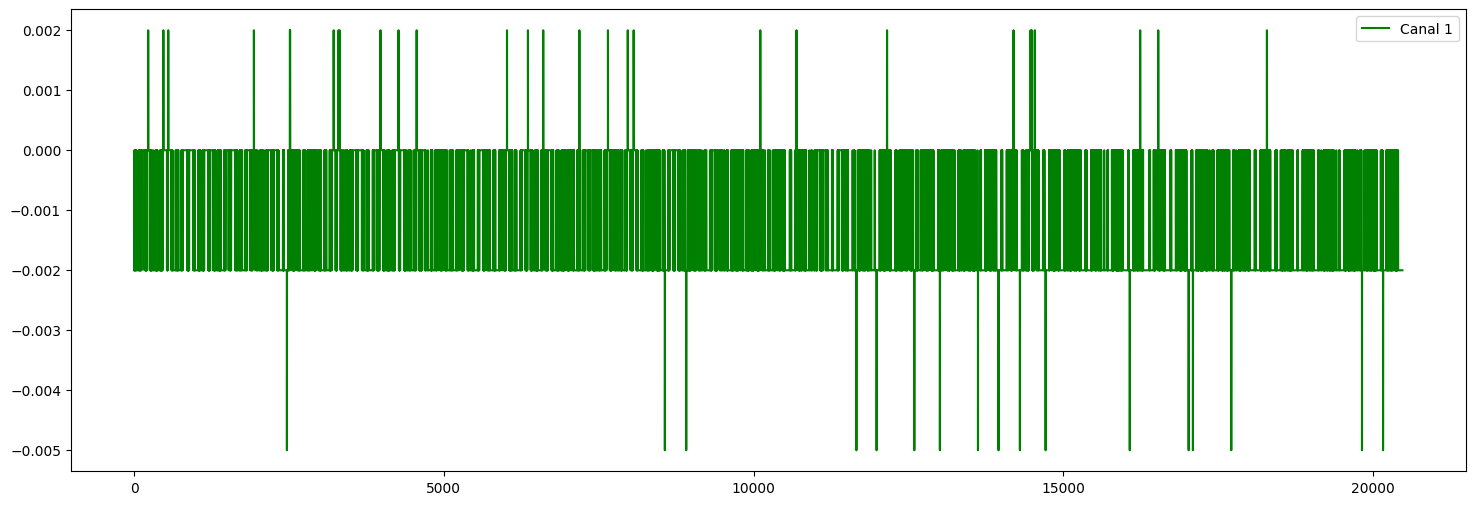

In [45]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 1 (Falla en la pista exterior)
dataset[['Canal 1']].plot(figsize=(18,6), color='green');

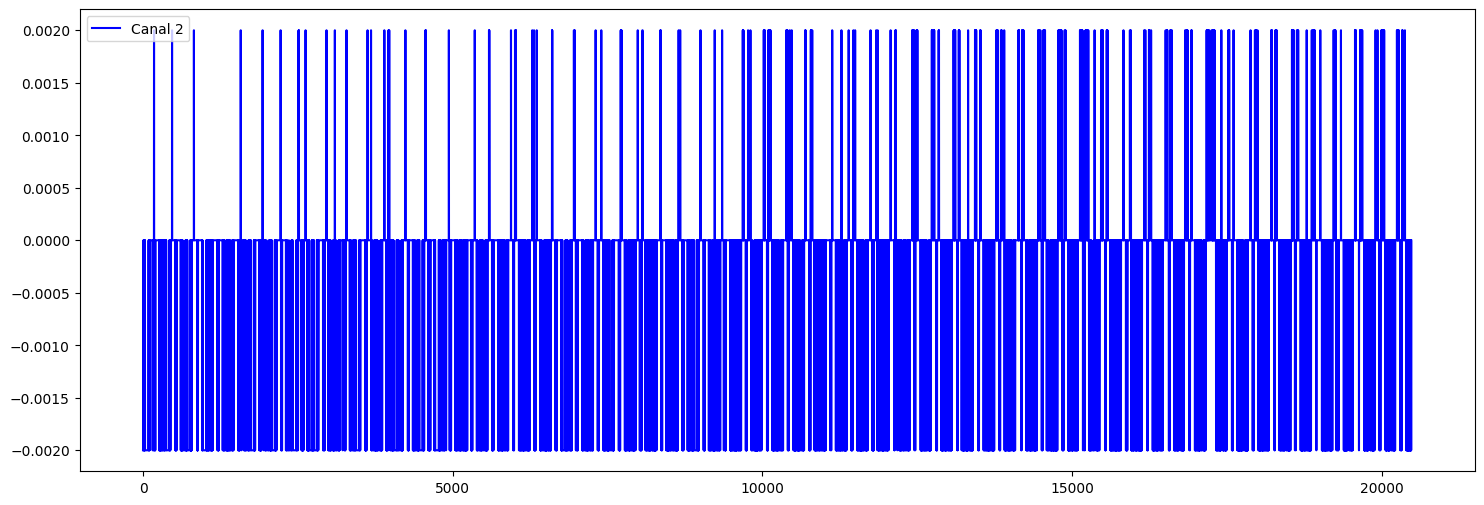

In [46]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 2
dataset[['Canal 2']].plot(figsize=(18,6), color='blue');

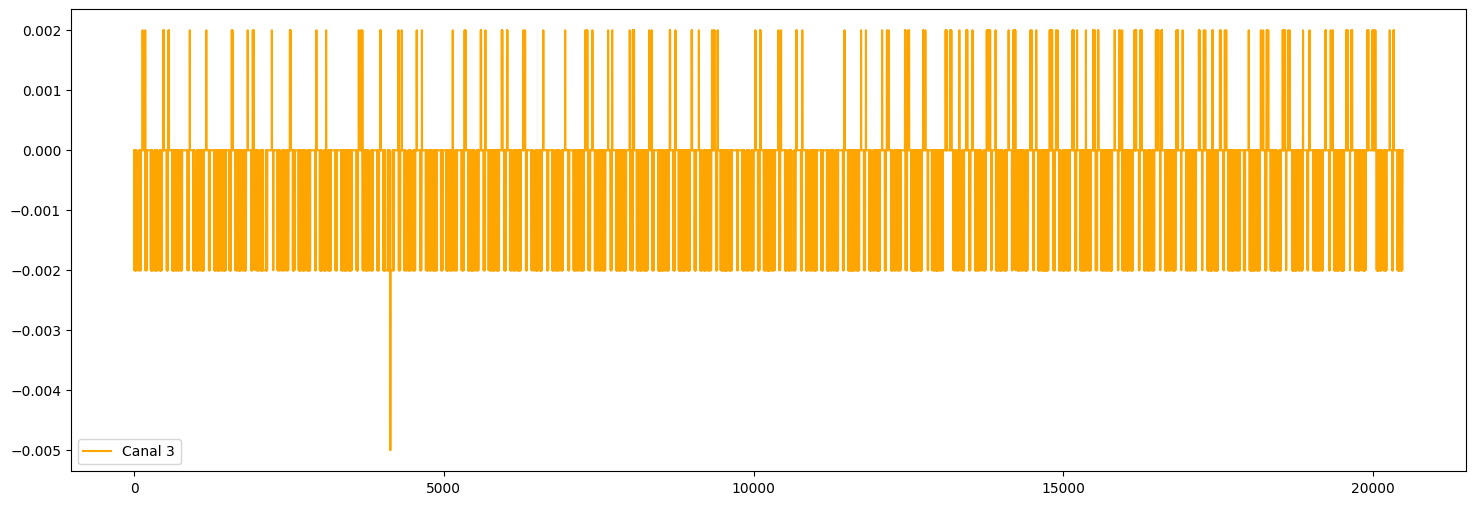

In [47]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 3
dataset[['Canal 3']].plot(figsize=(18,6), color='orange');

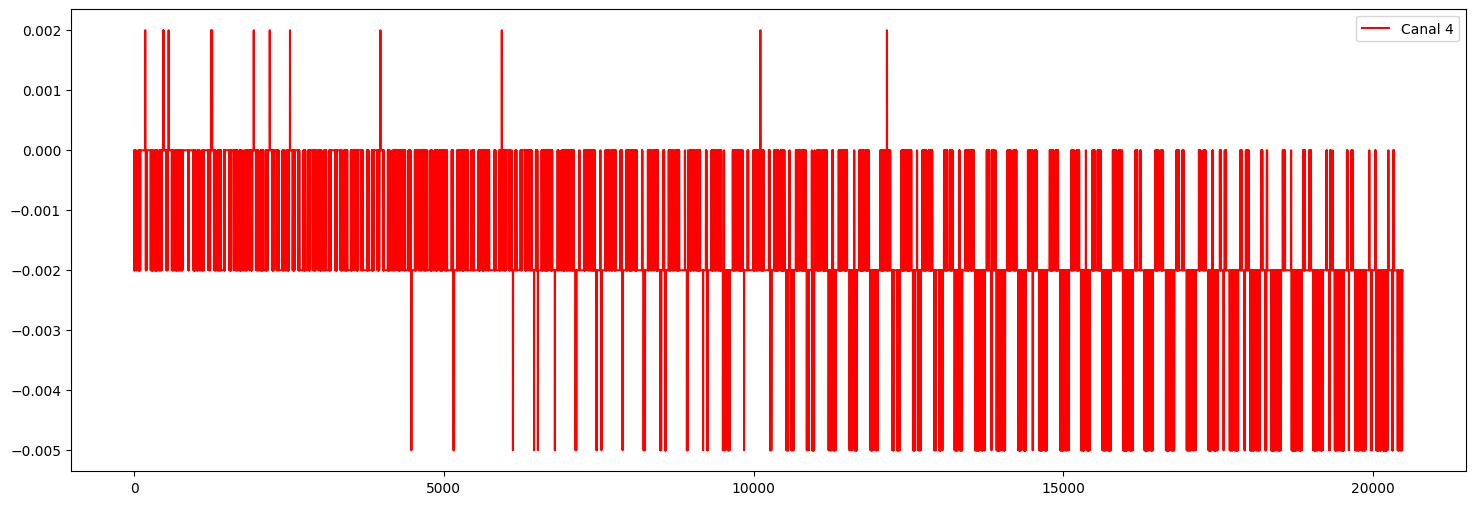

In [48]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 4
dataset[['Canal 4']].plot(figsize=(18,6), color='red');

## Gráfica de 3rd_test

* Contienen 4 sensores montados en 4 rodamientos

In [49]:
dataset = pd.read_csv(f'{path_3rd_test}/2004.04.18.02.42.55', sep='\t')
dataset.columns = ['Canal 1','Canal 2','Canal 3','Canal 4']
dataset.head()


,Canal 1,Canal 2,Canal 3,Canal 4
0,0.002,0.002,0.002,0.002
1,0.002,0.002,0.005,0.002
2,0.000,0.002,0.002,0.002
3,0.000,0.002,0.005,0.002
4,0.000,0.000,0.002,0.005


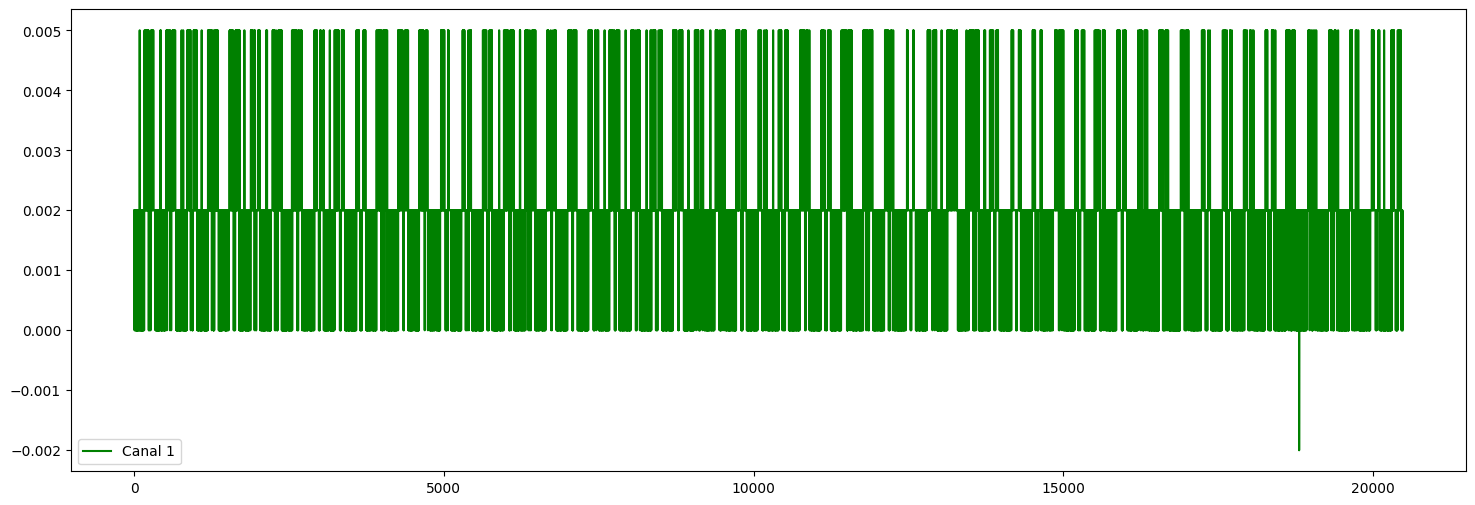

In [50]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 1 (Falla en la pista exterior)
dataset[['Canal 1']].plot(figsize=(18,6), color='green');

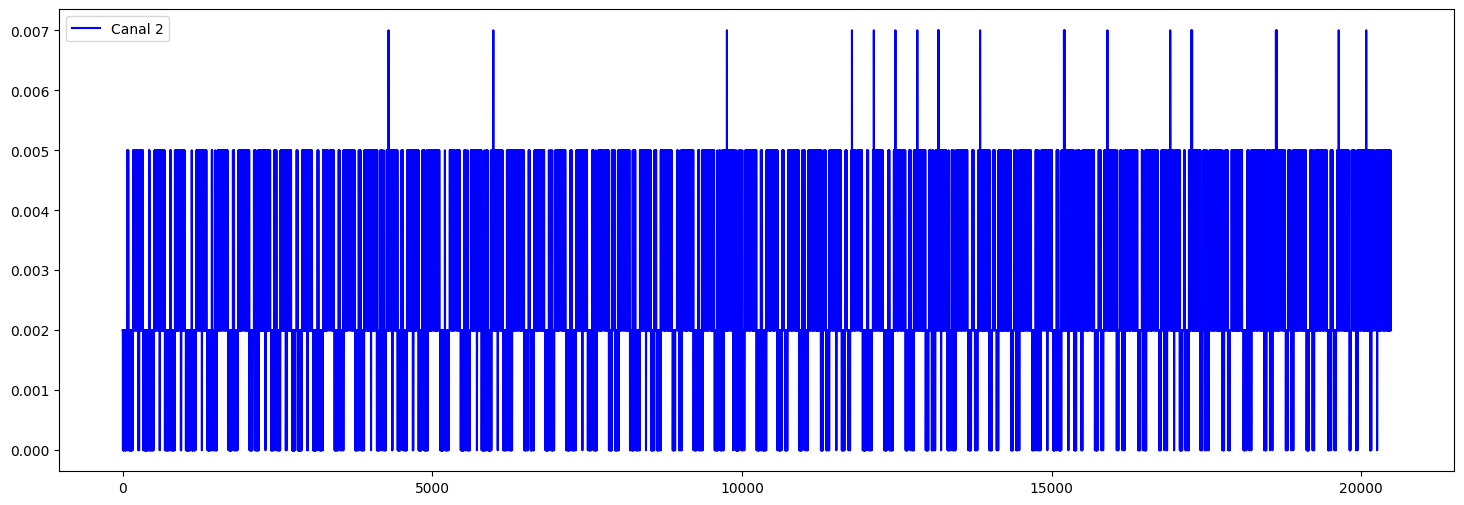

In [51]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 2
dataset[['Canal 2']].plot(figsize=(18,6), color='blue');

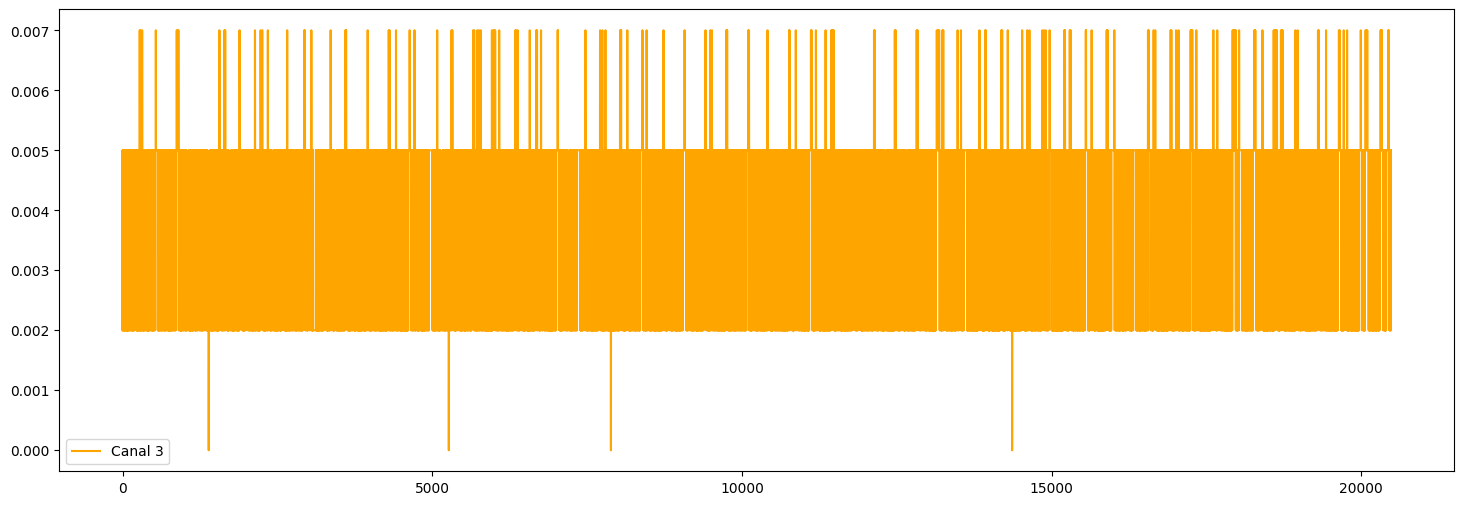

In [52]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 3 (falla en la pista exterior)
dataset[['Canal 3']].plot(figsize=(18,6), color='orange');

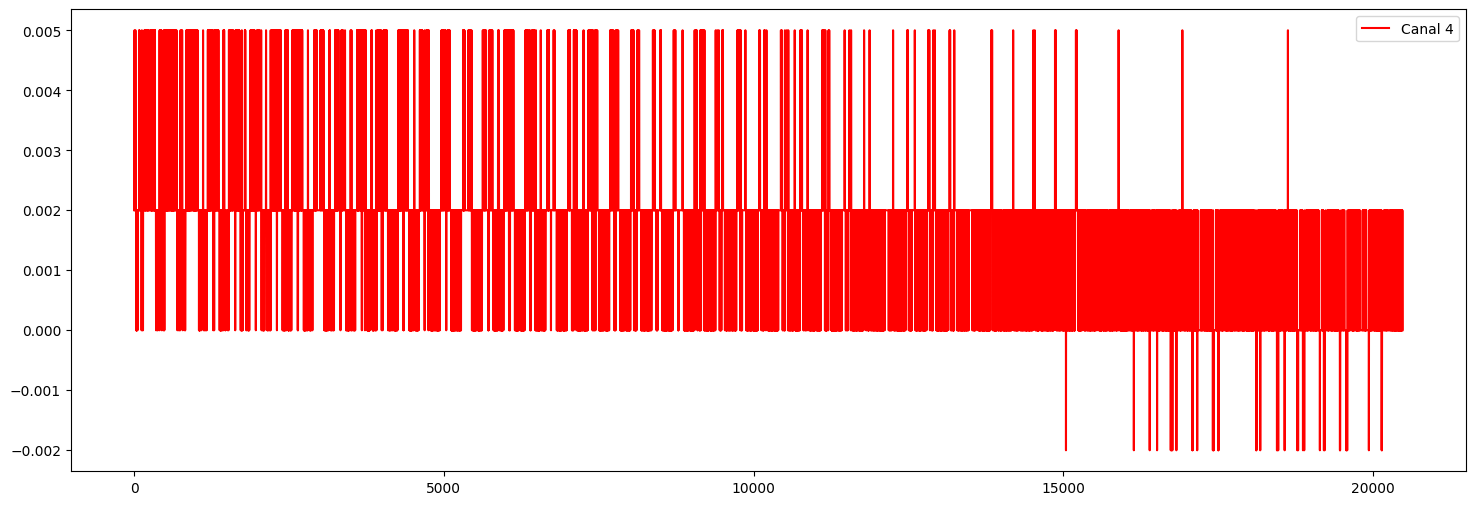

In [53]:
# Lecturas de los acelerómetros montados en el RODAMIENTO 4
dataset[['Canal 4']].plot(figsize=(18,6), color='red');

## Análisis

Las gráficas de los datos en el experimentos 1st_test tienen formas de señales muy variadas con picos muy marcados. De los otros experimentos se observa que la forma de la señales es muy diferente (señales cuadradas). Destacar que la presencia de picos en las gráficas no es un indicativo de fallas, dado que estos se observaron también en las gráficas de los primeros archivos. Por último a pesar de que el documento [Readme Document for IMS Bearing Data.pdf](https://file.notion.so/f/f/1022c098-f574-4b46-86a3-faf147fb3f26/76e16648-6f57-4f28-9589-caa2c6149a49/Readme_Document_for_IMS_Bearing_Data.pdf?table=block&id=22603b0a-b1d2-80eb-9df2-e5344fa9474c&spaceId=1022c098-f574-4b46-86a3-faf147fb3f26&expirationTimestamp=1753948800000&signature=5eKVFHFalBteXRsy7uQgwUos4nivNGgSFkoi9WjiXdY&downloadName=Readme+Document+for+IMS+Bearing+Data.pdf) indica claramente donde se hallaron fallas en los distintos rodamientos estos defectos no se traducen en picos diferenciables a simple vista.

# Gráficas de los elementos con fallos 

Ahora para intentar observar alguna tendencia provocada por los fallos se procede a graficar sólo las mediciones indicadas con fallos para cada prueba.

En este ejercicio se procede a graficar los 3 últimos archivos de las mediciones que presentaron alguna falla. Luego se dibujará una asintota vertical en zonas donde, a criterio personal, la medición mostrada fue provocada por la presencia de alguna falla.


## Gráficas de 1st_test

En la prueba 1st_test el rodamiento 3, que tenía equipado el sensor 5 y 6, presentó fallos en la pista interior. Mientras que el rodamiento 4, con el sensor 7 y 8, presentó fallos en el elemento rodante.


In [55]:
# Últimos 5 archivos en 1st_test:
for file_name in copy_files_1st_test[-5:]:
  print(file_name)

2003.11.25.16.07.32
2003.11.25.23.13.21
2003.11.25.23.19.56
2003.11.25.23.29.56
2003.11.25.23.39.56


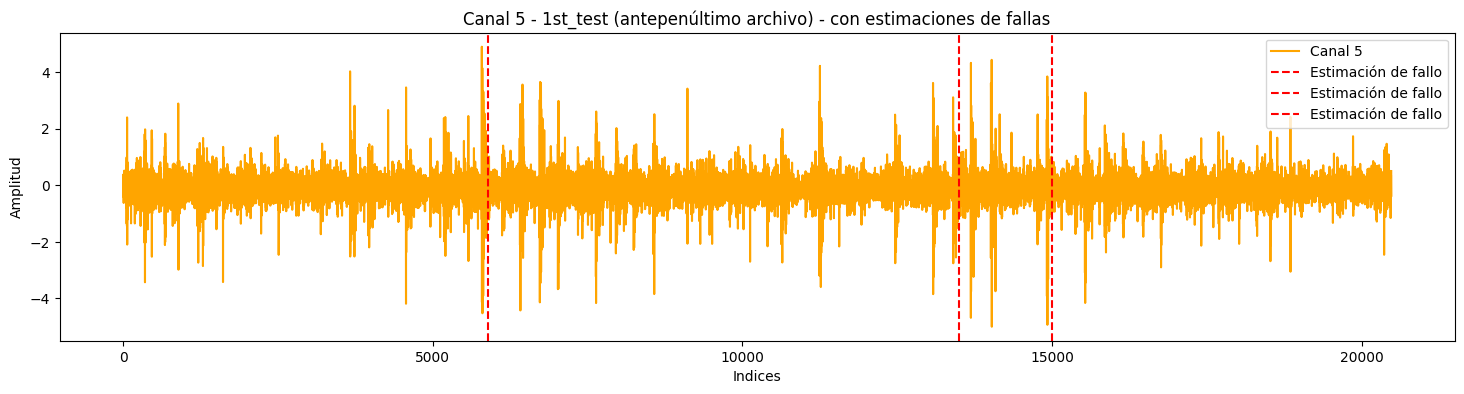

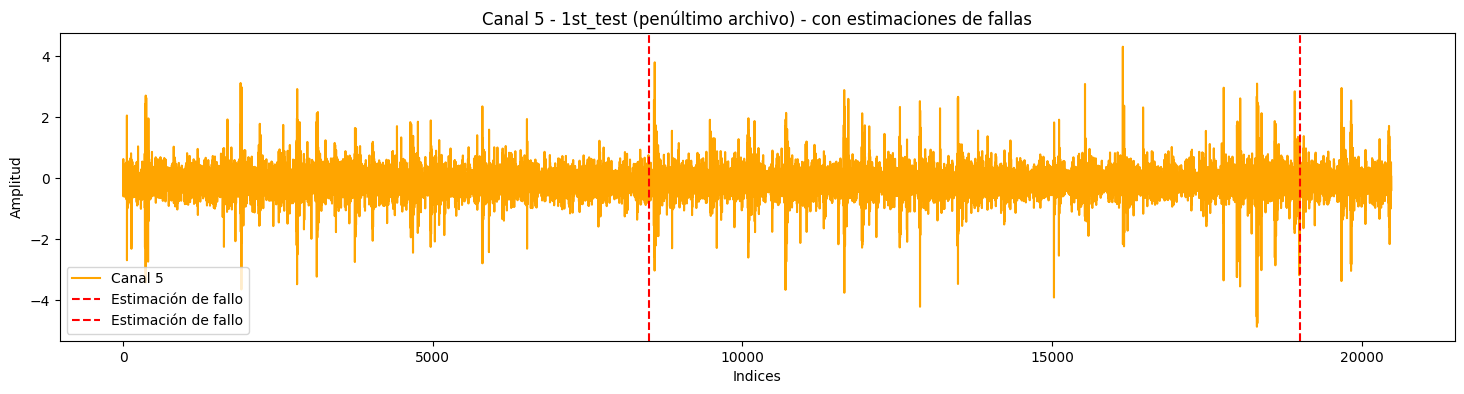

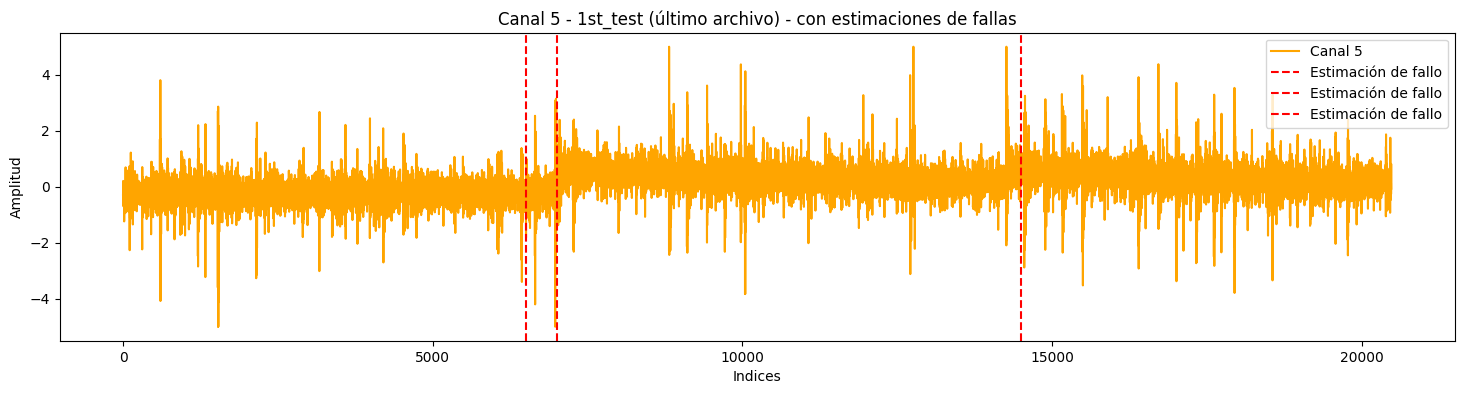

In [56]:
# Lecturas del canal 5 montado en el RODAMIENTO 3 (Falla en la pista interior)
dataset = cargar_archivo(f'{path_1st_test}/2003.11.25.23.19.56')
ax = dataset[['Canal 5']].plot(figsize=(18,4), color='orange')

# Gráfica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=5900, color='red', linestyle='--', label='Estimación de fallo')
ax.axvline(x=15000, color='red', linestyle='--', label='Estimación de fallo')
ax.axvline(x=13500, color='red', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 5 - 1st_test (antepenúltimo archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()



dataset = cargar_archivo(f'{path_1st_test}/2003.11.25.23.29.56')
ax = dataset[['Canal 5']].plot(figsize=(18,4), color='orange')

# Gráfica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=8500, color='red', linestyle='--', label='Estimación de fallo')
ax.axvline(x=19000, color='red', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 5 - 1st_test (penúltimo archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()

dataset = cargar_archivo(f'{path_1st_test}/2003.11.25.23.39.56')
ax = dataset[['Canal 5']].plot(figsize=(18,4), color='orange')

# Grafica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=6500, color='red', linestyle='--', label='Estimación de fallo')
ax.axvline(x=7000, color='red', linestyle='--', label='Estimación de fallo')
ax.axvline(x=14500, color='red', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 5 - 1st_test (último archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()

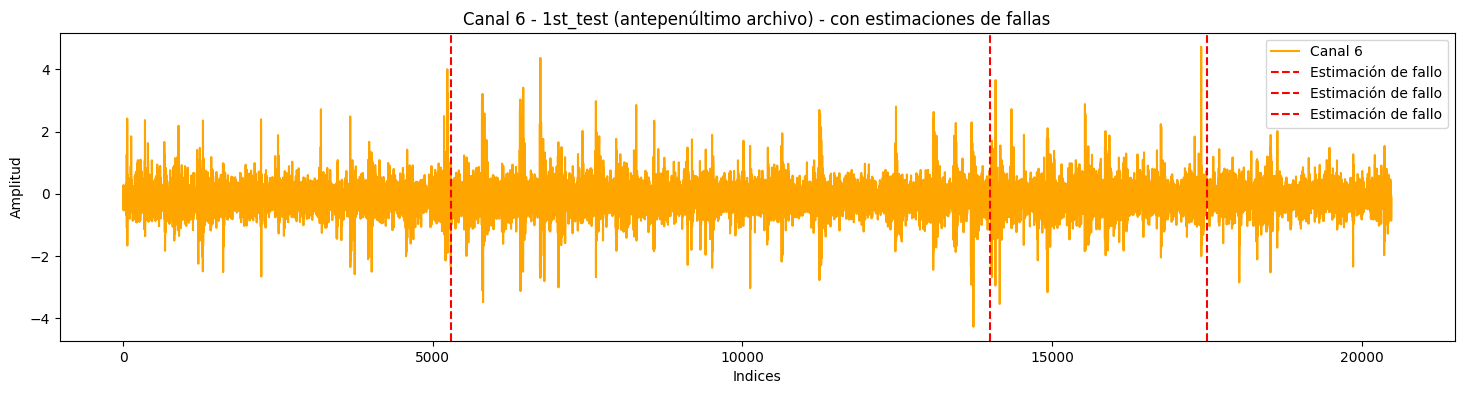

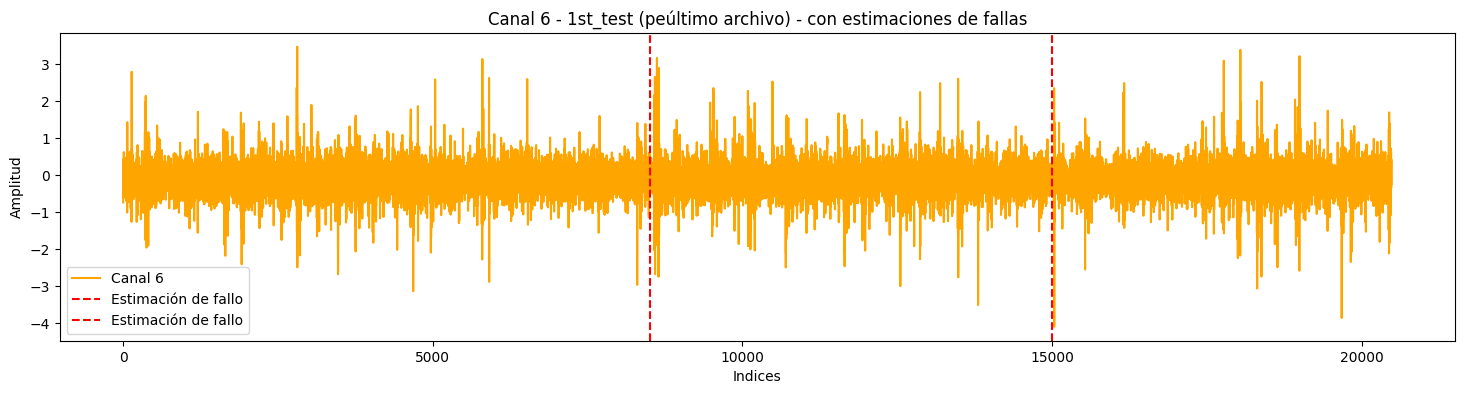

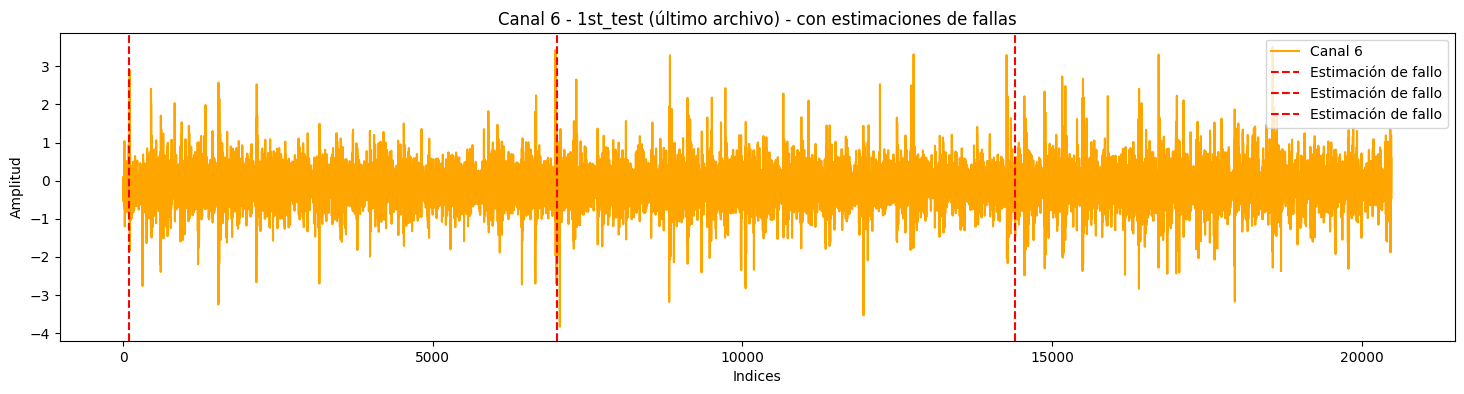

In [57]:
# Lecturas del canal 6 montado en el RODAMIENTO 3 (Falla en la pista interior)
dataset = cargar_archivo(f'{path_1st_test}/2003.11.25.23.19.56')
ax = dataset[['Canal 6']].plot(figsize=(18,4), color='orange')

# Gráfica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=5300, color='red', linestyle='--', label='Estimación de fallo')
ax.axvline(x=14000, color='red', linestyle='--', label='Estimación de fallo')
ax.axvline(x=17500, color='red', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 6 - 1st_test (antepenúltimo archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()



dataset = cargar_archivo(f'{path_1st_test}/2003.11.25.23.29.56')
ax = dataset[['Canal 6']].plot(figsize=(18,4), color='orange')

# Gráfica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=8500, color='red', linestyle='--', label='Estimación de fallo')
ax.axvline(x=15000, color='red', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 6 - 1st_test (peúltimo archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()

dataset = cargar_archivo(f'{path_1st_test}/2003.11.25.23.39.56')
ax = dataset[['Canal 6']].plot(figsize=(18,4), color='orange')

# Gráfica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=100, color='red', linestyle='--', label='Estimación de fallo')
ax.axvline(x=7000, color='red', linestyle='--', label='Estimación de fallo')
ax.axvline(x=14400, color='red', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 6 - 1st_test (último archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()

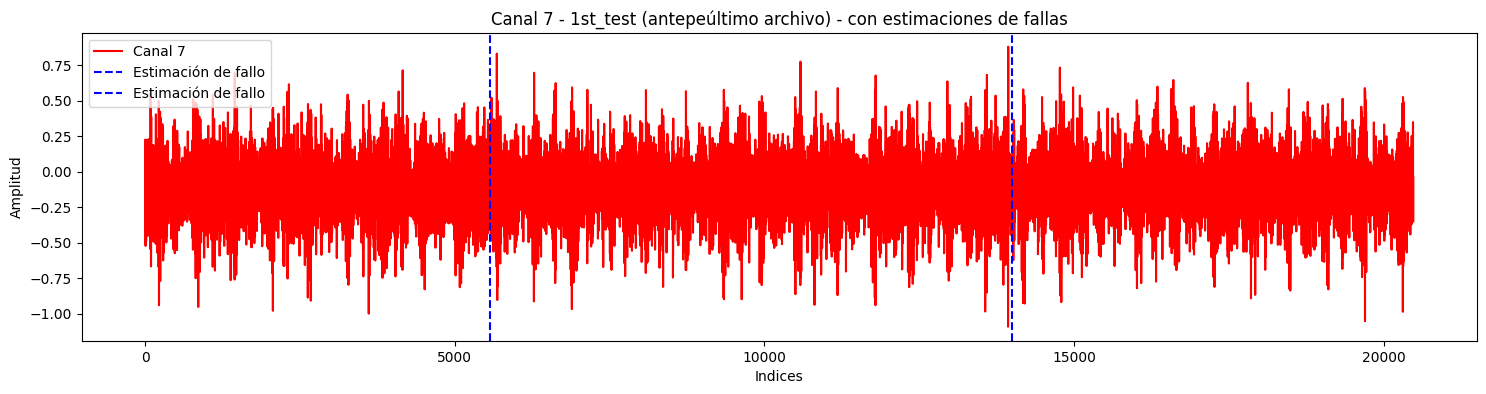

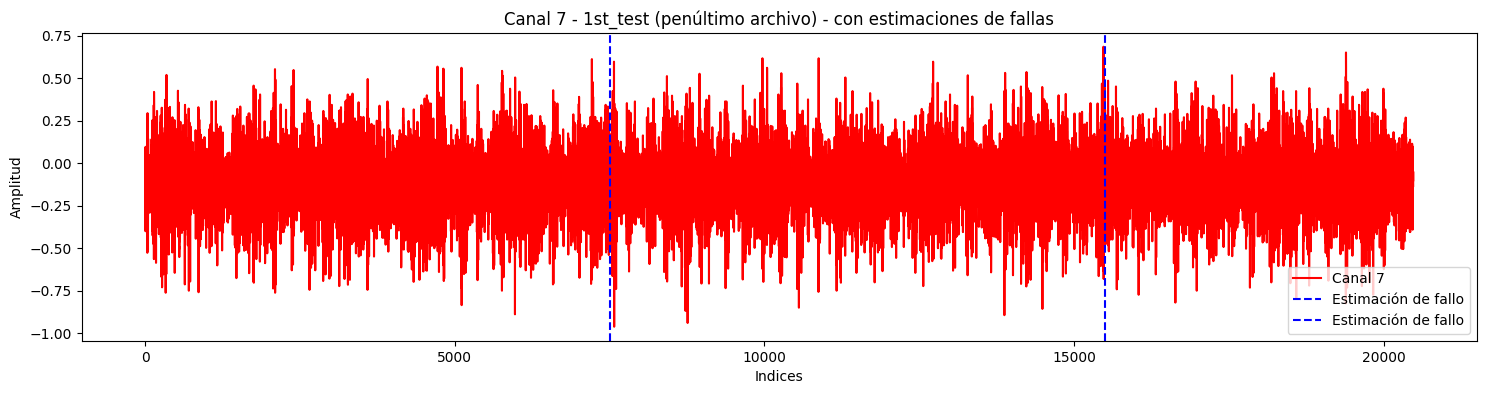

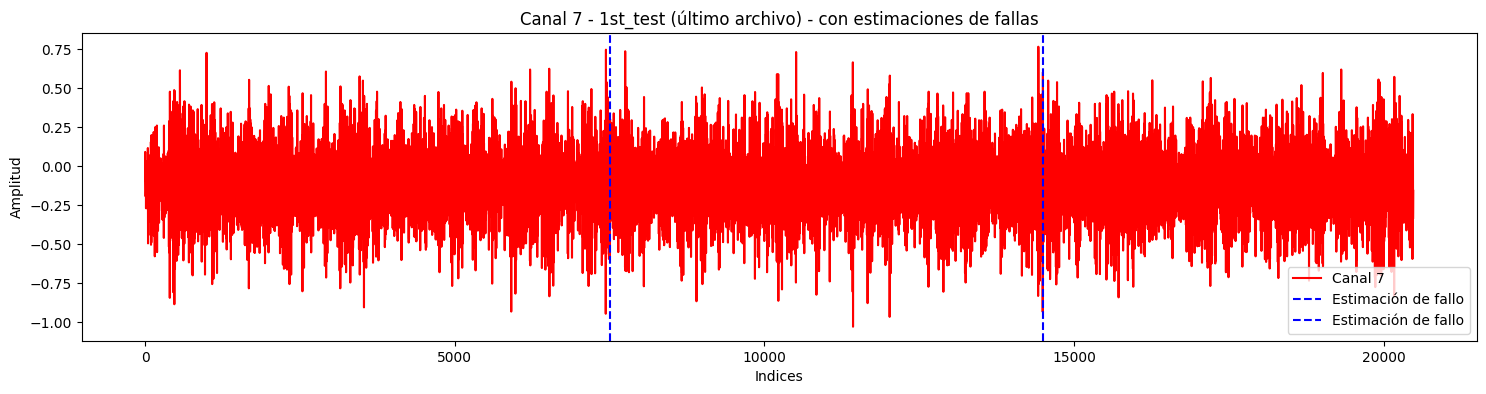

In [58]:
# Lecturas del canal 7 montado en el RODAMIENTO 4 (Falla en el elemento rodante)
dataset = cargar_archivo(f'{path_1st_test}/2003.11.25.23.19.56')
ax = dataset[['Canal 7']].plot(figsize=(18,4), color='red')

# Gráfica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=5570, color='blue', linestyle='--', label='Estimación de fallo')
ax.axvline(x=14000, color='blue', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 7 - 1st_test (antepeúltimo archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()



dataset = cargar_archivo(f'{path_1st_test}/2003.11.25.23.29.56')
ax = dataset[['Canal 7']].plot(figsize=(18,4), color='red')

# Grafica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=7500, color='blue', linestyle='--', label='Estimación de fallo')
ax.axvline(x=15500, color='blue', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 7 - 1st_test (penúltimo archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()

dataset = cargar_archivo(f'{path_1st_test}/2003.11.25.23.39.56')
ax = dataset[['Canal 7']].plot(figsize=(18,4), color='red')

# Grafica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=7500, color='blue', linestyle='--', label='Estimación de fallo')
ax.axvline(x=14500, color='blue', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 7 - 1st_test (último archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()

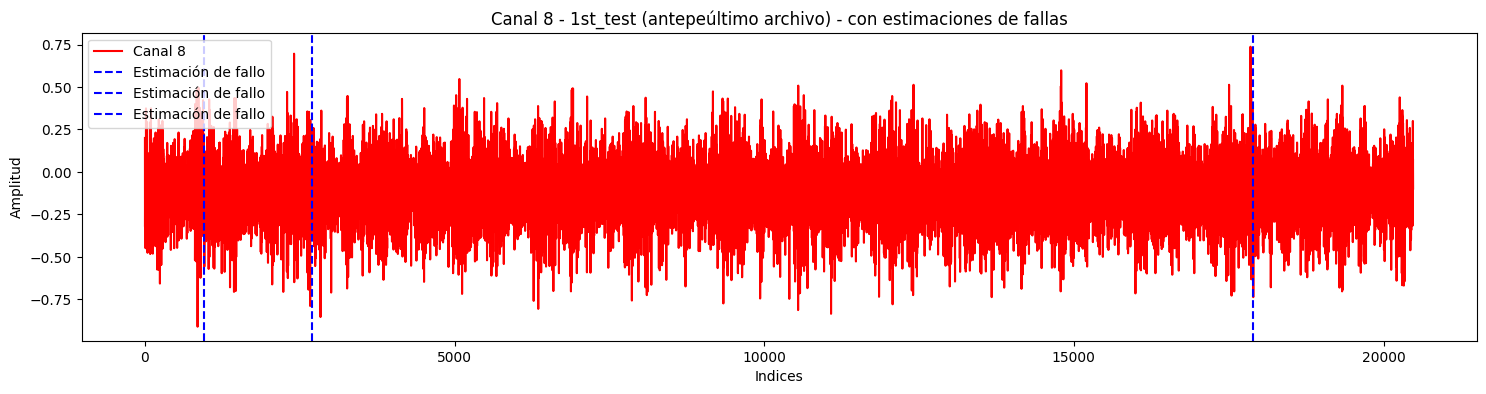

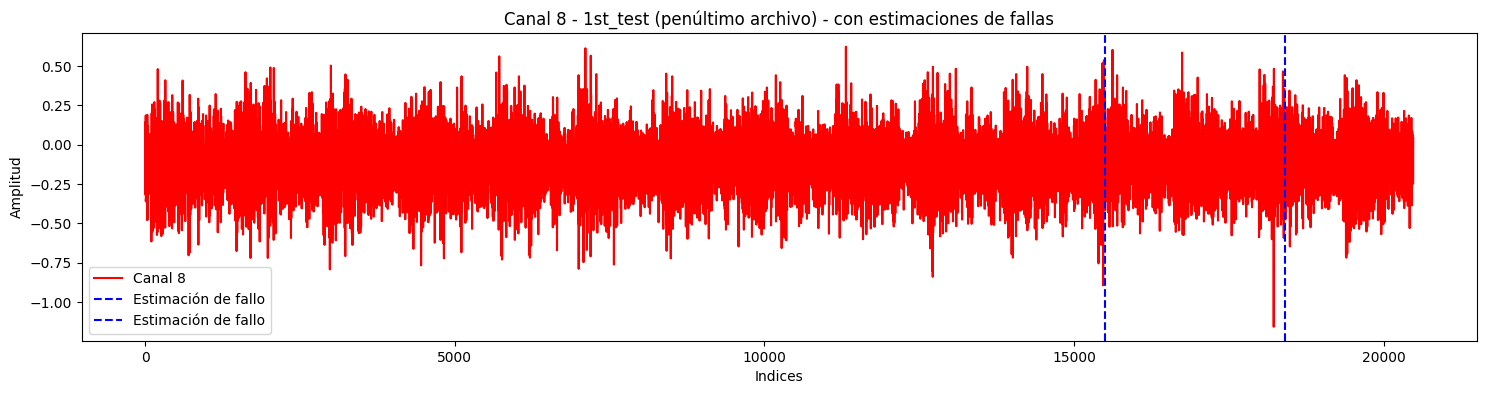

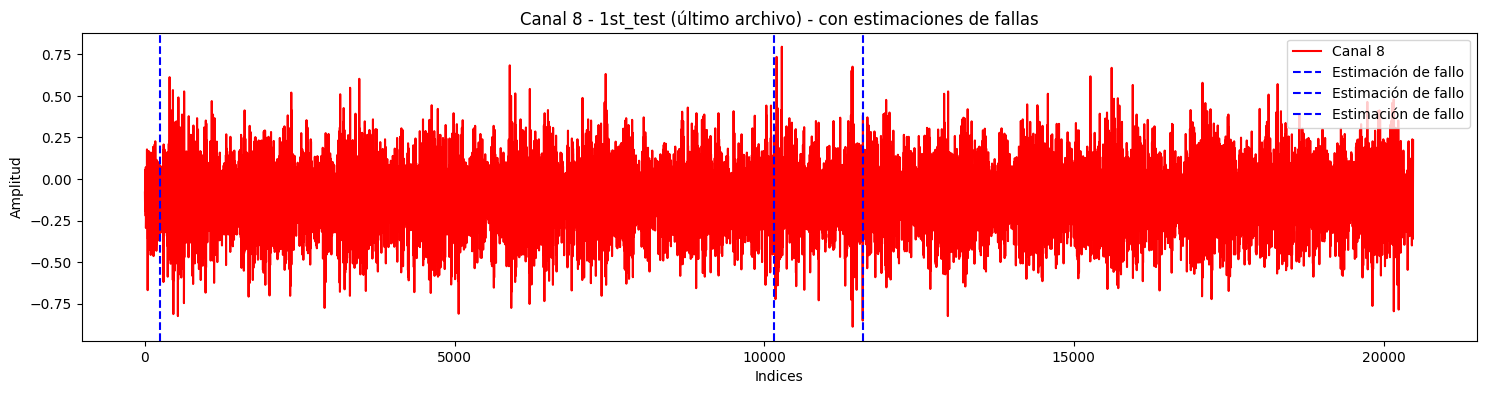

In [59]:
# Lecturas del canal 8 montado en el RODAMIENTO 4 (Falla en el elemento rodante)
dataset = cargar_archivo(f'{path_1st_test}/2003.11.25.23.19.56')
ax = dataset[['Canal 8']].plot(figsize=(18,4), color='red')

# Gráfica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=950, color='blue', linestyle='--', label='Estimación de fallo')
ax.axvline(x=2700, color='blue', linestyle='--', label='Estimación de fallo')
ax.axvline(x=17900, color='blue', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 8 - 1st_test (antepeúltimo archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()



dataset = cargar_archivo(f'{path_1st_test}/2003.11.25.23.29.56')
ax = dataset[['Canal 8']].plot(figsize=(18,4), color='red')

# Grafica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=15500, color='blue', linestyle='--', label='Estimación de fallo')
ax.axvline(x=18400, color='blue', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 8 - 1st_test (penúltimo archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()

dataset = cargar_archivo(f'{path_1st_test}/2003.11.25.23.39.56')
ax = dataset[['Canal 8']].plot(figsize=(18,4), color='red')

# Grafica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=250, color='blue', linestyle='--', label='Estimación de fallo')
ax.axvline(x=10150, color='blue', linestyle='--', label='Estimación de fallo')
ax.axvline(x=11600, color='blue', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 8 - 1st_test (último archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()

## Gráficas de 2nd_test

En la prueba 2nd_test el rodamiento 1 presentó una falla en la pista exterior.


In [60]:
# Últimos 5 archivos en 2nd_test:
for file_name in copy_files_2nd_test[-5:]:
  print(file_name)

2004.02.19.05.42.39
2004.02.19.05.52.39
2004.02.19.06.02.39
2004.02.19.06.12.39
2004.02.19.06.22.39


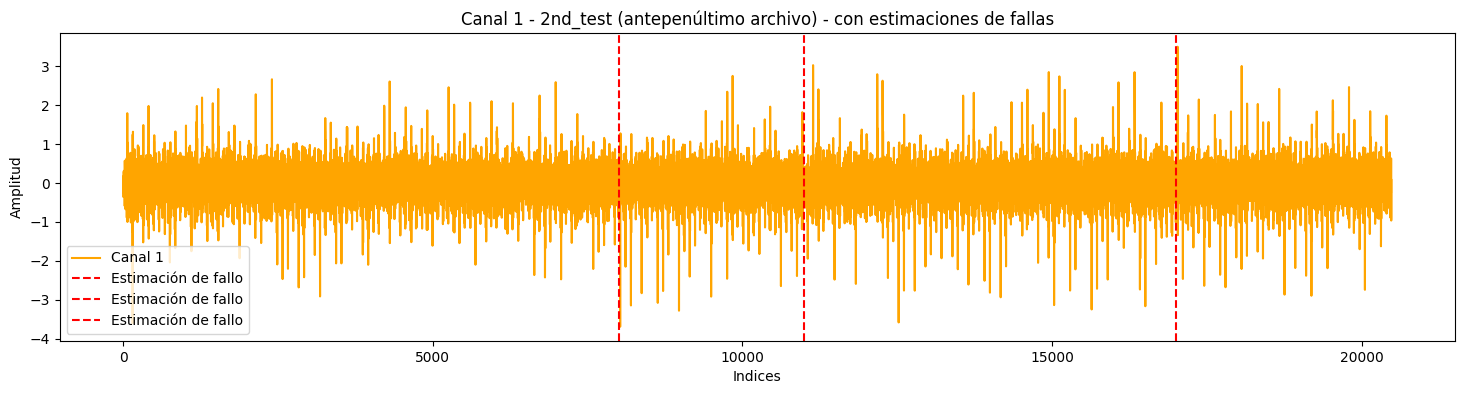

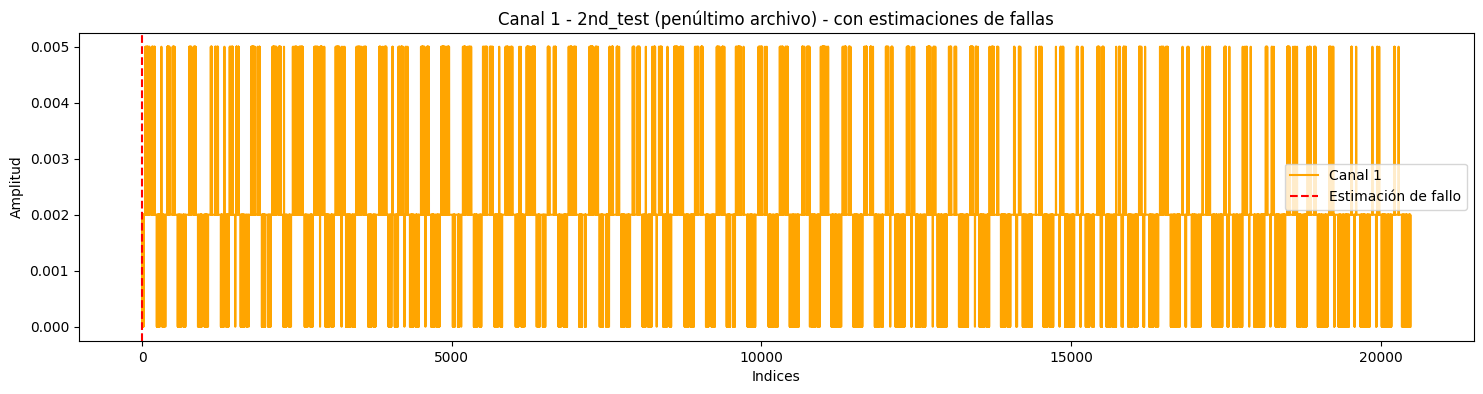

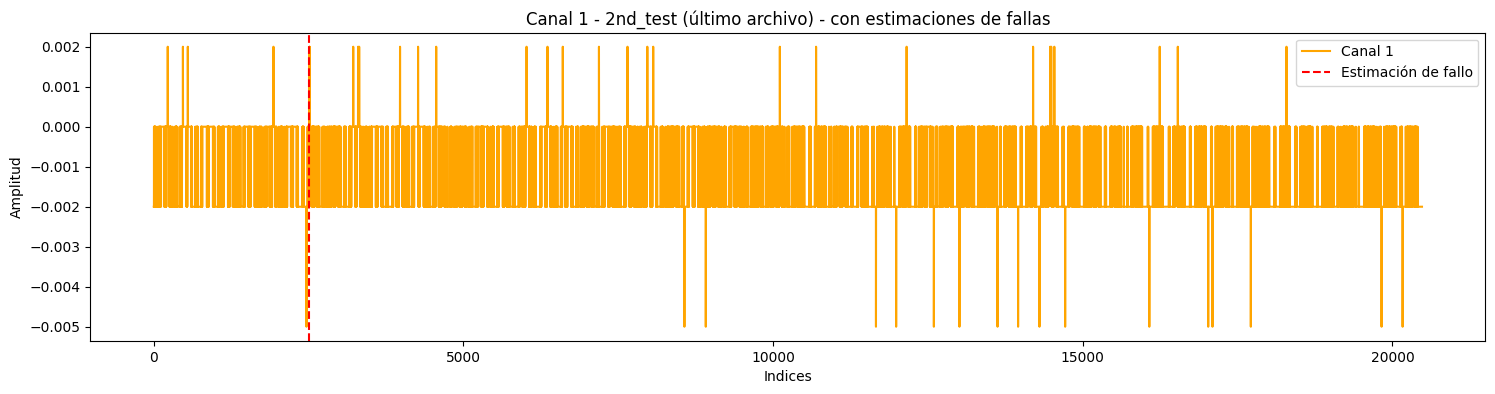

In [61]:
# Lecturas del canal 1 montado en el RODAMIENTO 1 (Falla en la pista exterior)
dataset = cargar_archivo(f'{path_2nd_test}/2004.02.19.06.02.39')
ax = dataset[['Canal 1']].plot(figsize=(18,4), color='orange')

# Grafica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=8000, color='red', linestyle='--', label='Estimación de fallo')
ax.axvline(x=11000, color='red', linestyle='--', label='Estimación de fallo')
ax.axvline(x=17000, color='red', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 1 - 2nd_test (antepenúltimo archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()



dataset = cargar_archivo(f'{path_2nd_test}/2004.02.19.06.12.39')
ax = dataset[['Canal 1']].plot(figsize=(18,4), color='orange')

# Grafica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=0, color='red', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 1 - 2nd_test (penúltimo archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()

dataset = cargar_archivo(f'{path_2nd_test}/2004.02.19.06.22.39')
ax = dataset[['Canal 1']].plot(figsize=(18,4), color='orange')

# Grafica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=2500, color='red', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 1 - 2nd_test (último archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()

## Gráficas de 3rd_test

En la prueba 3rd_test el rodamiento 3 presentó una falla en en al pista exterior.


In [62]:
# Últimos 5 archivos en 3rd_test:
for file_name in copy_files_3rd_test[-5:]:
  print(file_name)

2004.04.18.02.02.55
2004.04.18.02.12.55
2004.04.18.02.22.55
2004.04.18.02.32.55
2004.04.18.02.42.55


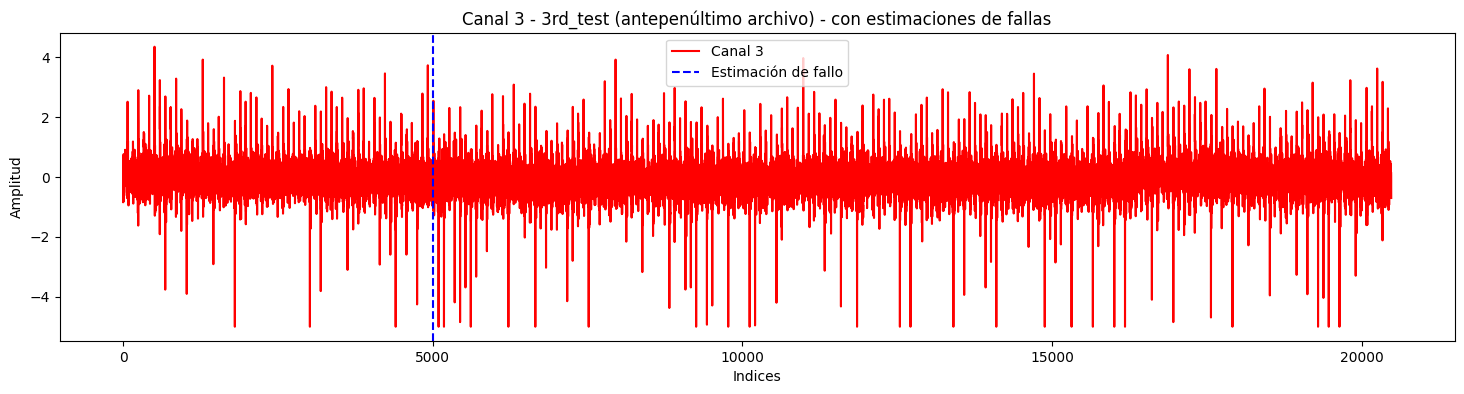

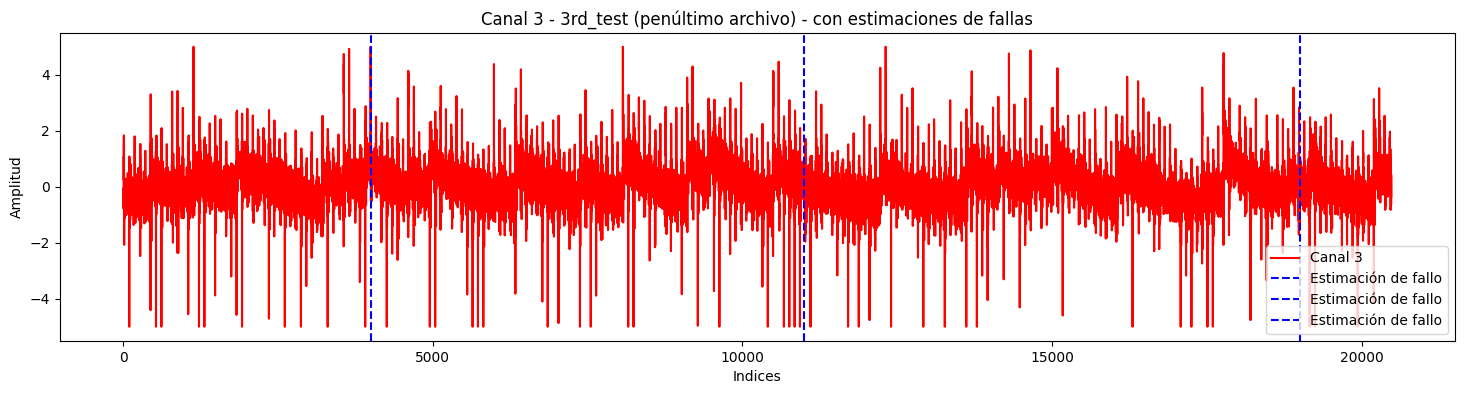

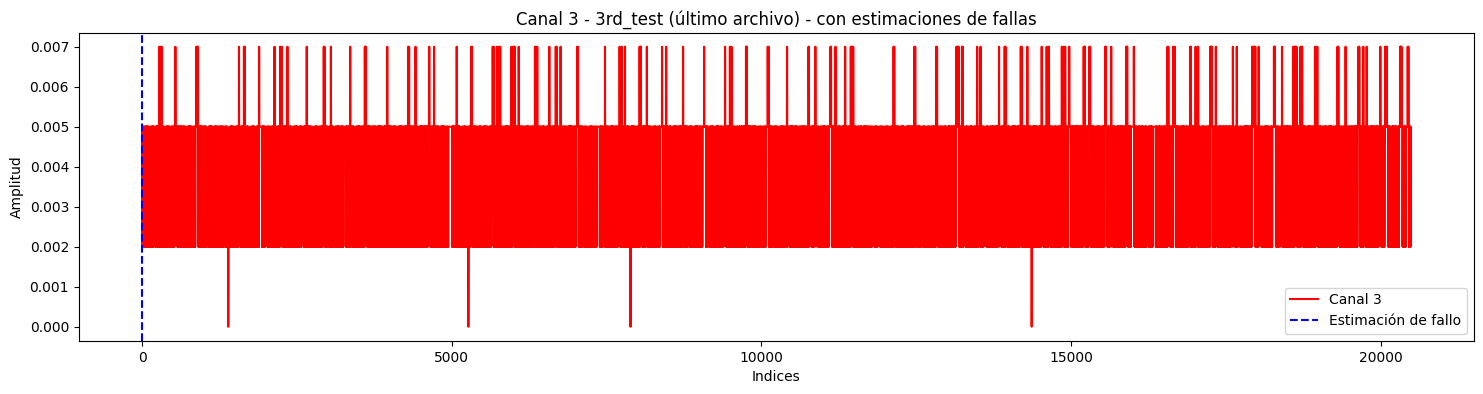

In [63]:
# Lecturas del canal 3 montado en el RODAMIENTO 3 (Falla en la pista exterior)
dataset = cargar_archivo(f'{path_3rd_test}/2004.04.18.02.22.55')
ax = dataset[['Canal 3']].plot(figsize=(18,4), color='red')

# Gráfica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=5000, color='blue', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 3 - 3rd_test (antepenúltimo archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()



dataset = cargar_archivo(f'{path_3rd_test}/2004.04.18.02.32.55')
ax = dataset[['Canal 3']].plot(figsize=(18,4), color='red')

# Grafica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=4000, color='blue', linestyle='--', label='Estimación de fallo')
ax.axvline(x=11000, color='blue', linestyle='--', label='Estimación de fallo')
ax.axvline(x=19000, color='blue', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 3 - 3rd_test (penúltimo archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()

dataset = cargar_archivo(f'{path_3rd_test}/2004.04.18.02.42.55')
ax = dataset[['Canal 3']].plot(figsize=(18,4), color='red')

# Grafica de asintota vertical indicando una aproximación natural del fallo
ax.axvline(x=0, color='blue', linestyle='--', label='Estimación de fallo')

ax.legend()
plt.title('Canal 3 - 3rd_test (último archivo) - con estimaciones de fallas')
plt.xlabel('Indices')
plt.ylabel('Amplitud')
plt.show()

## Análisis

En los experimentos 2nd_test y 3rd_test se puede observar que las señales cuadradas sólo están presentes a final de los experimentos. Previo a la aparición de las señales cuadradas se puede ver una forma regular con varios picos.

Las señales cuadradas observadas al final de los experimentos 2nd_test y 3rd_test presentan una amplitud menor con respecto a las señales regulares que se observan en otras mediciones, estas señales pueden estar relacionadas con la paralización del experimento. La última afirmación se confirmará más adelante con el análisis conjunto de todos los archivos.

En las señales de los experimentos 1st_test y 2nd_test no se observa una tendencia clara que muestre la presencia de fallas en los rodamientos. Tampoco se puede diferencia a simple vista una modificacion en la señal en comparacion al estado incial de los experimentos.

En la señal creada con el penúltimo archivo del experimento 3rd_test se puede ver una clara modificación de la forma de la señal con respecto a un estado incial del experimento.



# Uso de filtros para resaltar fallas

Se procede a aplicar filtros para resaltar fallas en los datasets mas prometedores:

* **1st_test**: último archivo "2003.11.25.23.39.56" - RODAMIENTO 3 - canal 5 (Falla en la pista interior)
* **2nd_test**: antepenúltimo archivo "2004.02.19.06.02.39" - RODAMIENTO 1 - canal 1 (Falla en la pista exterior)
* **3rd_test**: penúltimo archivo "2004.04.18.02.32.55" - RODAMIENTO 3 - canal 3 (Falla en la pista exterior)

In [14]:
# Librerías necesarias

import matplotlib.pyplot as plt
import pywt

## Filtros de wavelet

Se comenzará empleando una de las wavelets más simples, la wavelet de Daubechies. También conocida como Haar.

Al emplear esta transformada en una señal se obtienen coficientes de detalles (cD) y de aproximación (cA). Además se tiene el parámetro "nivel" con el que se puede controlar el suavidado que se hará sobre la señal.

Al aumentar un nivel en la trasformada la señal se reduce a la mitad en tamaño. Entonces el nivel más bajo (cD1) captura detalles más finos (alta resolución temporal, poca resolución en frecuencia). Mientras los niveles más altos (cD2, cD3 ... cDN) capturan detalles más amplios (menor resolución temporal, mejor resolución en frecuencia).

Asi por ejemplo:

* **Nivel 1 (cD1)** : detecta cambios bruscos instantáneos (picos, ruido).
* **Nivel 2 (cD2)** : detecta oscilaciones un poco más lentas.
* **Nivel 3 (cD3)** : detecta patrones más prolongados, como variaciones lentas.

Mientras que el coeficiente de aproximación al nivel 3 (cA3) será una versión muy suavizada de la señal original, casi una “línea de tendencia”.


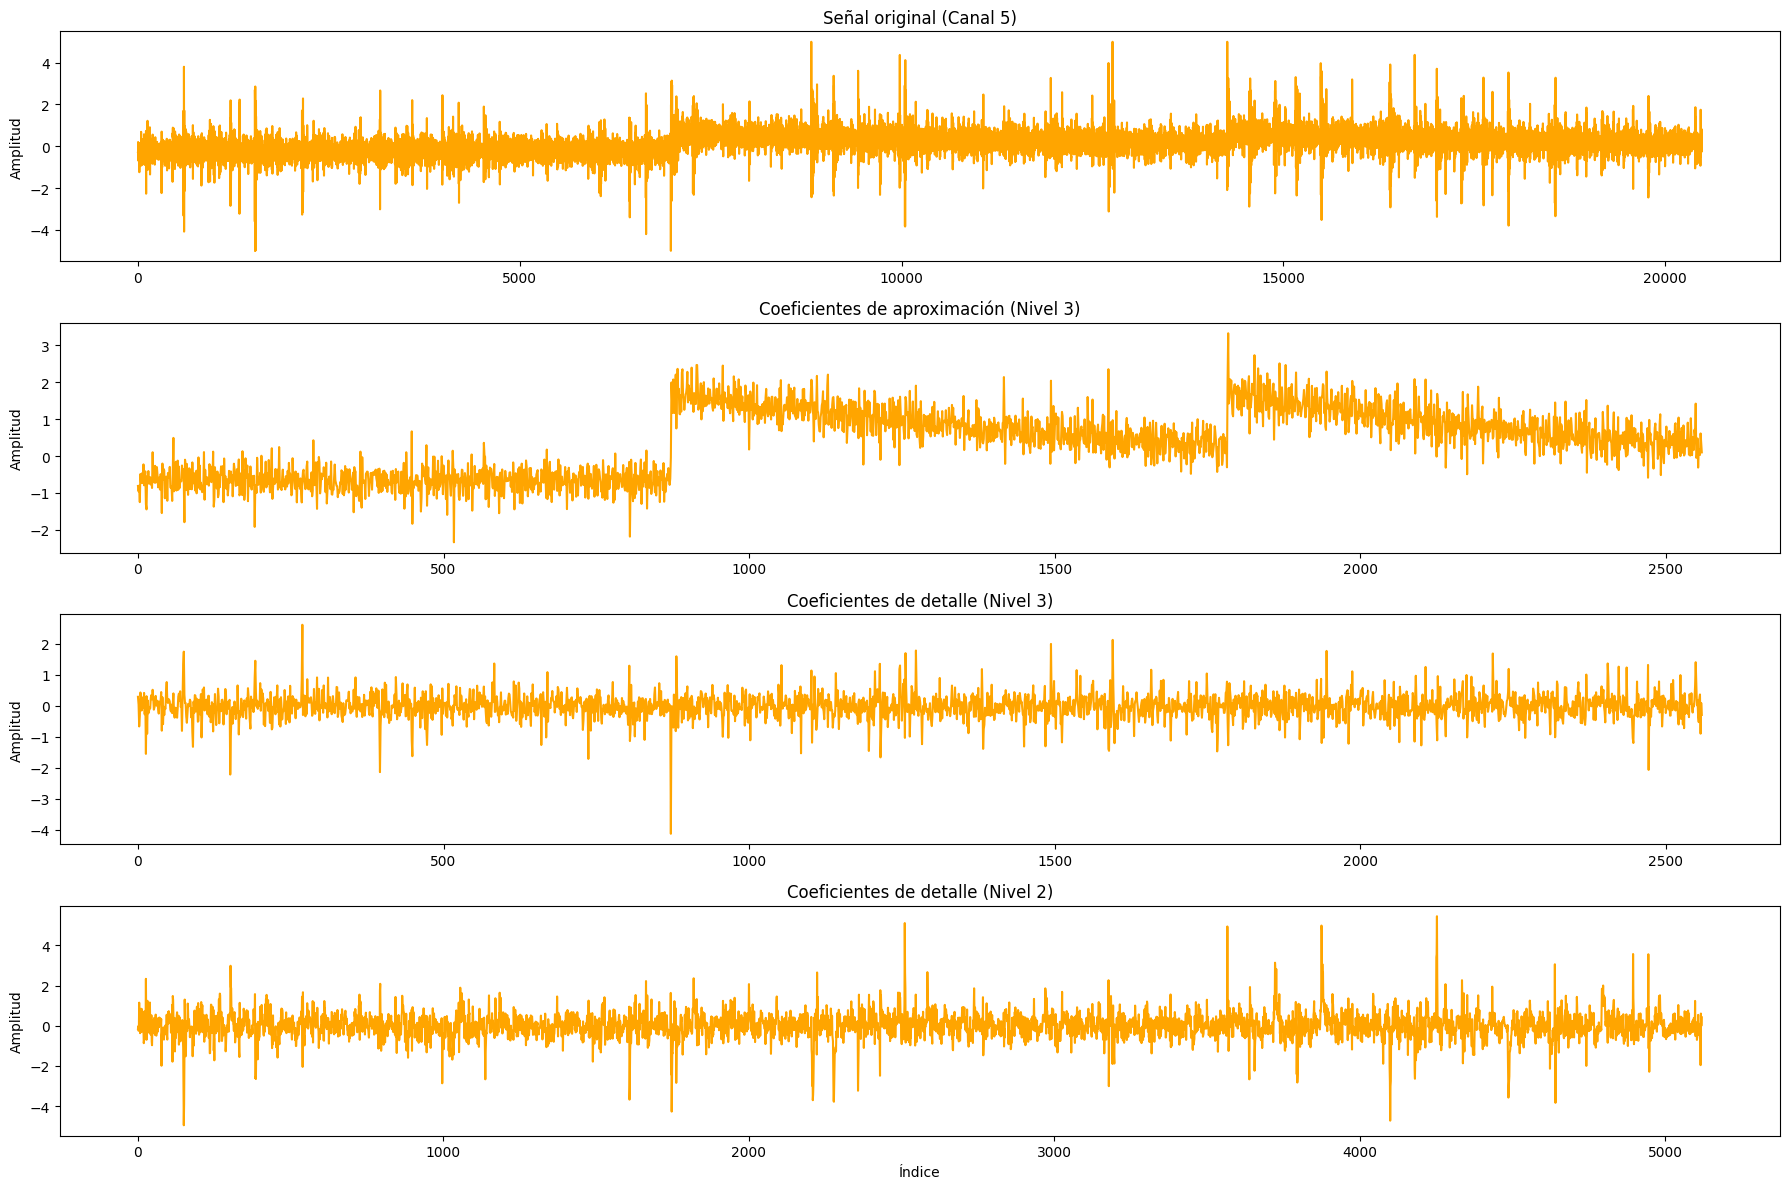

In [ ]:
# 1st_test: último archivo "2003.11.25.23.39.56" - RODAMIENTO 3 - canal 5 (Falla en la pista interior)
dataset = cargar_archivo(f'datos/IMS_bearing_dataset/1st_test/1st_test/2003.11.25.23.39.56')

# mode='db1': usa el wavelet Daubechies
# level=1 : Nivel de descomposición, sólo se obtendrán los coeficientes de nivel 1 (cA1 y cD1).
# Aplicar la descomposición wavelet Daubechies 1 (db1) con 3 niveles
coeffs = pywt.wavedec(dataset.loc[:, 'Canal 5'], 'db1', level=3)

# coeficientes de aproximación cA1 → baja frecuencia.
# coeficientes de detalle cD1 → alta frecuencia.
cA3, cD3, cD2, cD1 = coeffs

# Graficar la señal original y los coeficientes de cada nivel
plt.figure(figsize=(18, 12))

plt.subplot(4, 1, 1)
plt.plot(dataset['Canal 5'], color='orange')
plt.title('Señal original (Canal 5)')
plt.ylabel('Amplitud')

plt.subplot(4, 1, 2)
plt.plot(cA3, color='orange')
plt.title('Coeficientes de aproximación (Nivel 3)')
plt.ylabel('Amplitud')

plt.subplot(4, 1, 3)
plt.plot(cD3, color='orange')
plt.title('Coeficientes de detalle (Nivel 3)')
plt.ylabel('Amplitud')

plt.subplot(4, 1, 4)
plt.plot(cD2, color='orange')
plt.title('Coeficientes de detalle (Nivel 2)')
plt.ylabel('Amplitud')
plt.xlabel('Índice')

plt.tight_layout()
plt.show()


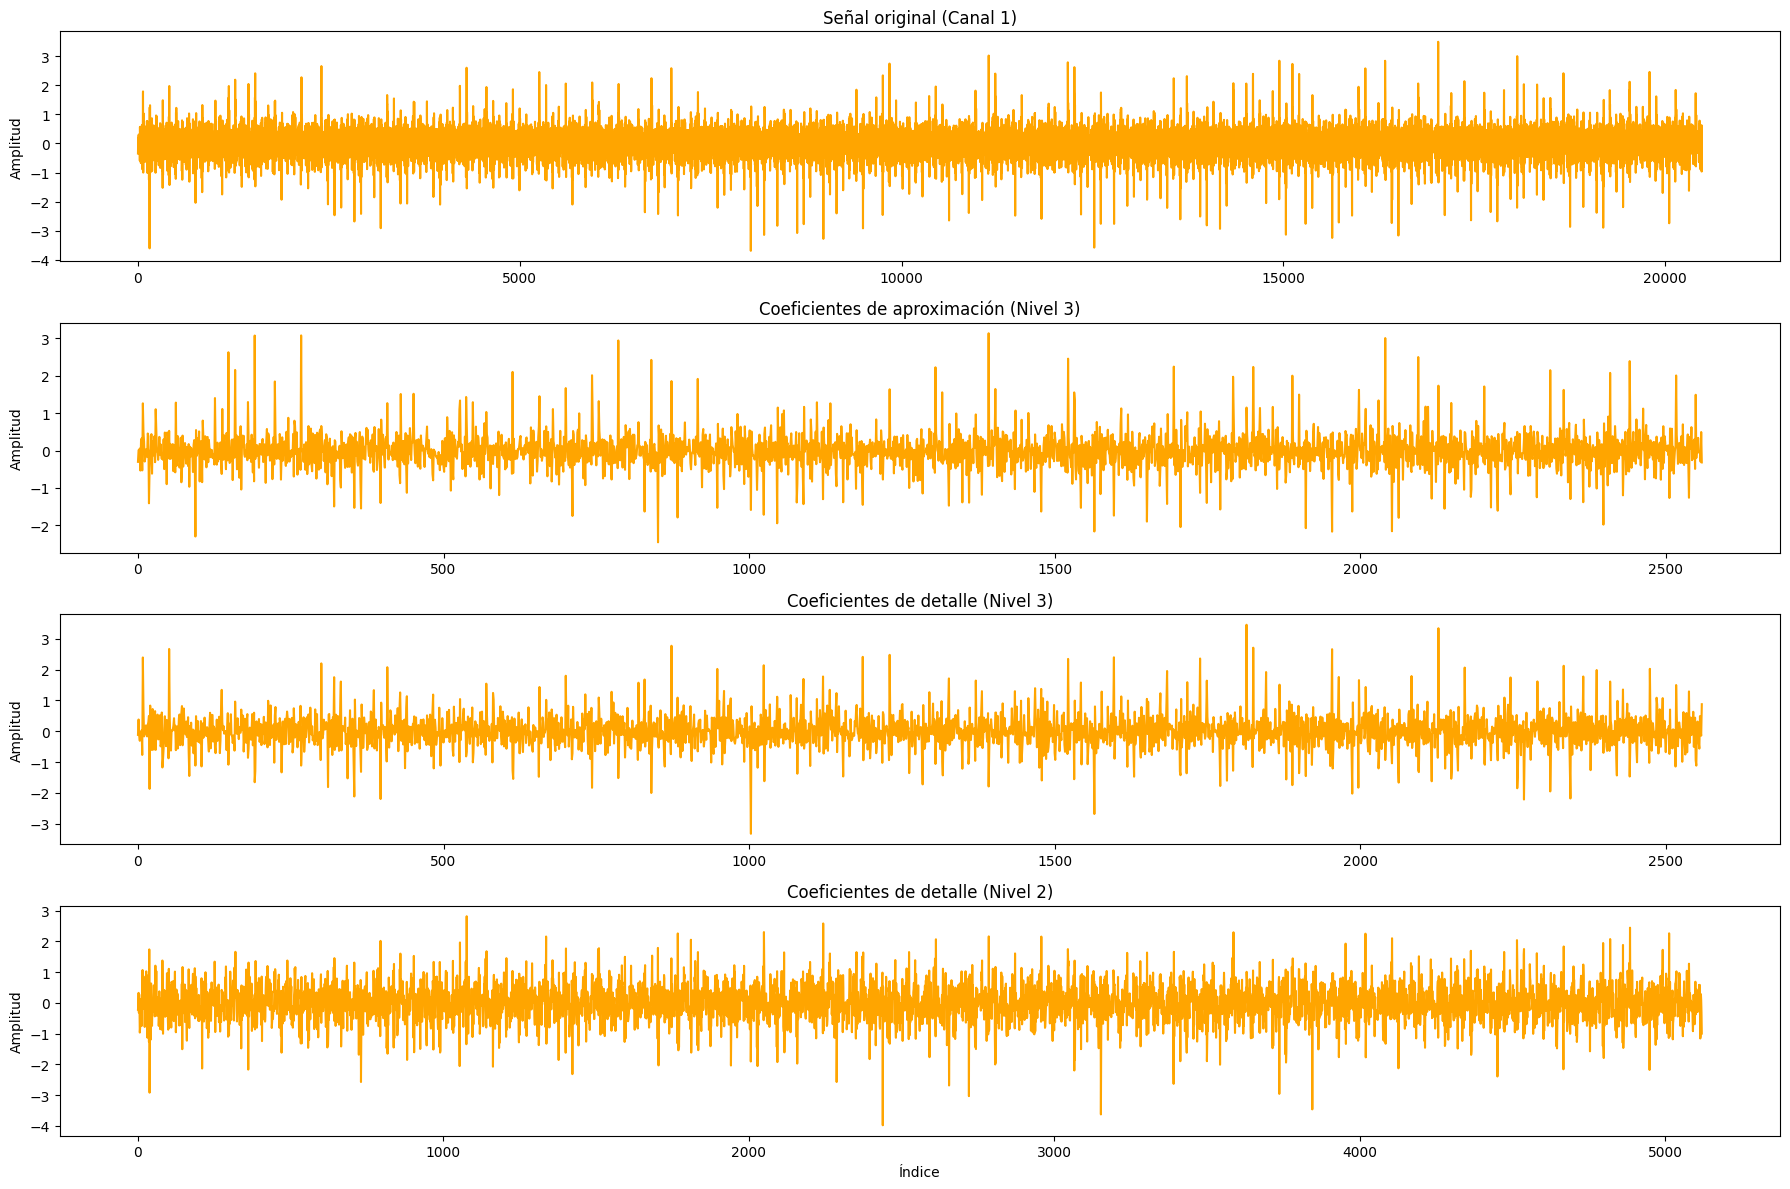

In [18]:
# 2nd_test: antepenúltimo archivo "2004.02.19.06.02.39" - RODAMIENTO 1 - canal 1 (Falla en la pista exterior)
# 
dataset = cargar_archivo(f'datos/IMS_bearing_dataset/2nd_test/2nd_test/2004.02.19.06.02.39')

# mode='db1': usa el wavelet Daubechies
# level=1 : Nivel de descomposición, sólo se obtendrán los coeficientes de nivel 1 (cA1 y cD1).
# Aplicar la descomposición wavelet Daubechies 1 (db1) con 3 niveles
coeffs = pywt.wavedec(dataset.loc[:, 'Canal 1'], 'db1', level=3)

# coeficientes de aproximación cA1 → baja frecuencia.
# coeficientes de detalle cD1 → alta frecuencia.
cA3, cD3, cD2, cD1 = coeffs

# Graficar la señal original y los coeficientes de cada nivel
plt.figure(figsize=(18, 12))

plt.subplot(4, 1, 1)
plt.plot(dataset['Canal 1'], color='orange')
plt.title('Señal original (Canal 1)')
plt.ylabel('Amplitud')

plt.subplot(4, 1, 2)
plt.plot(cA3, color='orange')
plt.title('Coeficientes de aproximación (Nivel 3)')
plt.ylabel('Amplitud')

plt.subplot(4, 1, 3)
plt.plot(cD3, color='orange')
plt.title('Coeficientes de detalle (Nivel 3)')
plt.ylabel('Amplitud')

plt.subplot(4, 1, 4)
plt.plot(cD2, color='orange')
plt.title('Coeficientes de detalle (Nivel 2)')
plt.ylabel('Amplitud')
plt.xlabel('Índice')

plt.tight_layout()
plt.show()


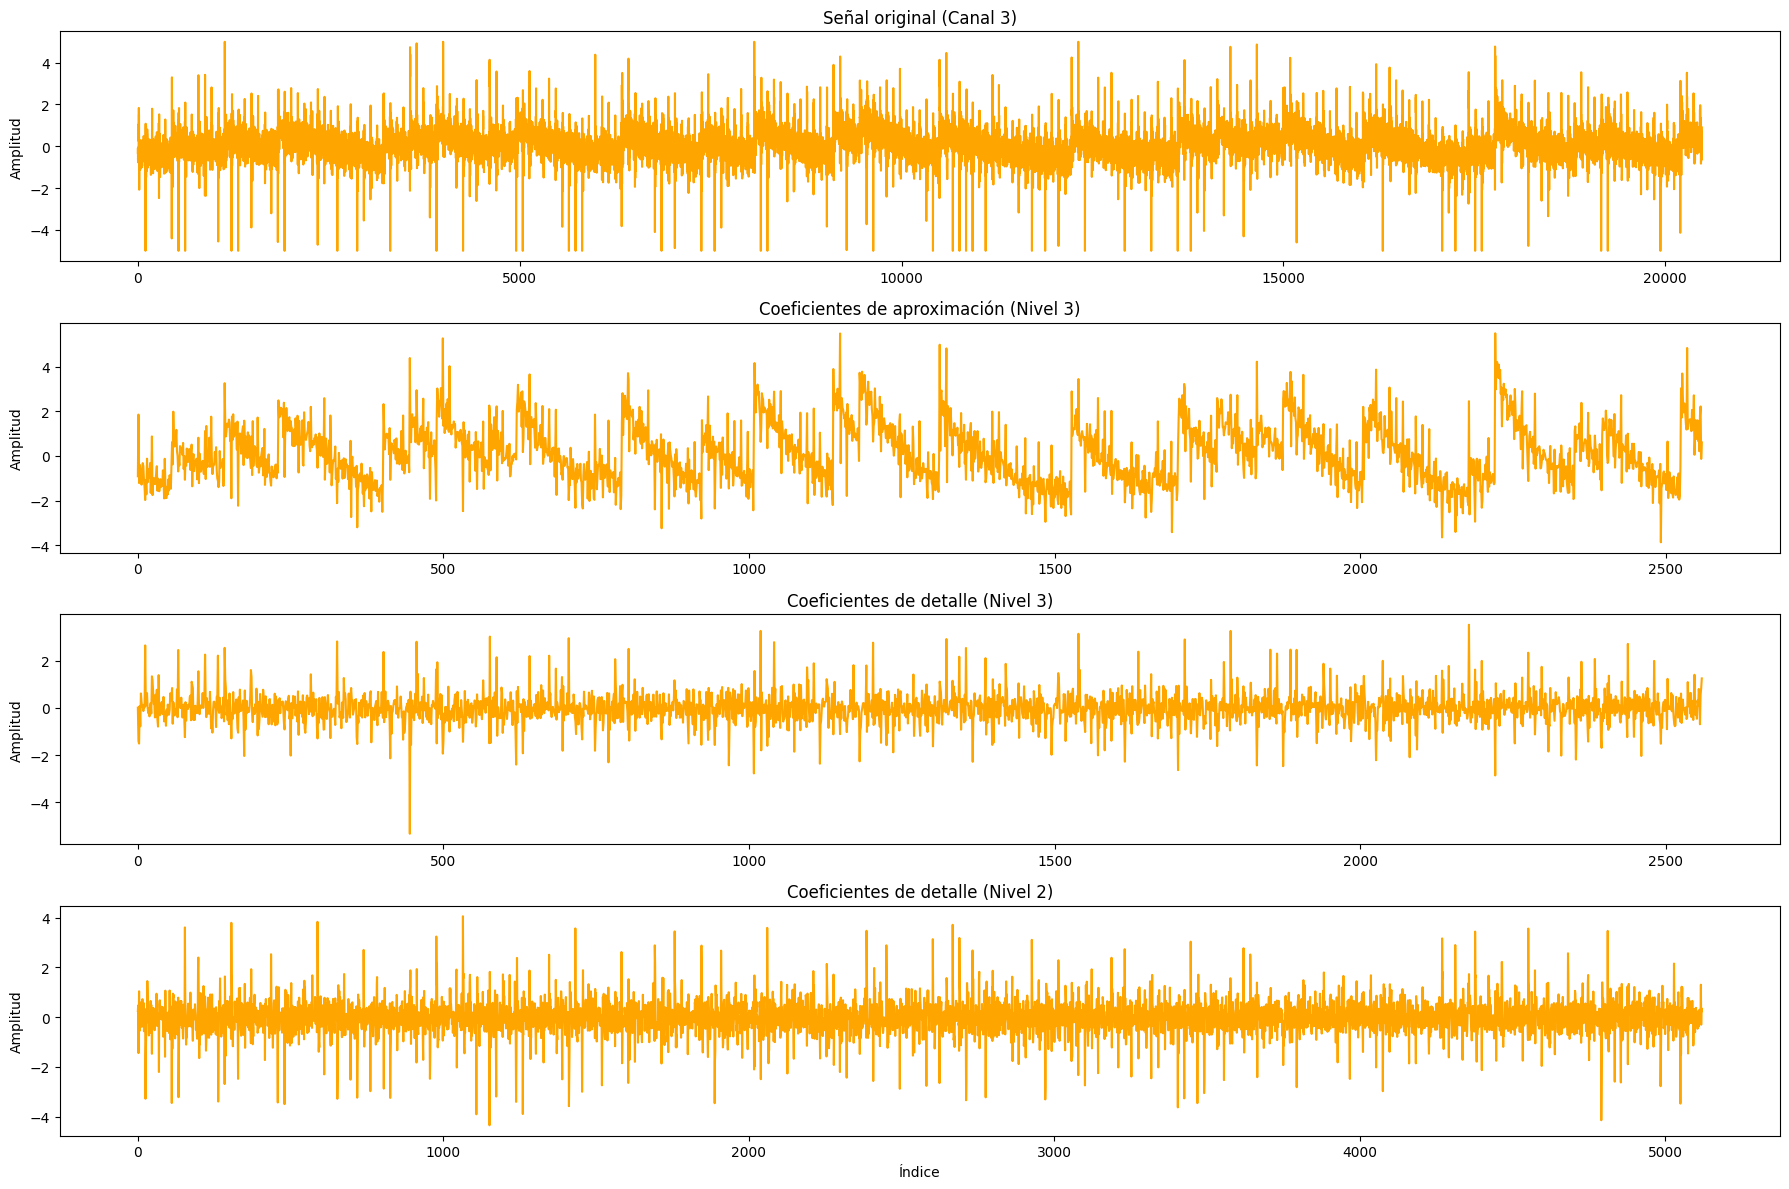

In [19]:
# 3rd_test: penúltimo archivo "2004.04.18.02.32.55" - RODAMIENTO 3 - canal 3 (Falla en la pista exterior)

dataset = cargar_archivo(f'datos/IMS_bearing_dataset/3rd_test/4th_test/txt/2004.04.18.02.32.55')

# mode='db1': usa el wavelet Daubechies
# level=1 : Nivel de descomposición, sólo se obtendrán los coeficientes de nivel 1 (cA1 y cD1).
# Aplicar la descomposición wavelet Daubechies 1 (db1) con 3 niveles
coeffs = pywt.wavedec(dataset.loc[:, 'Canal 3'], 'db1', level=3)

# coeficientes de aproximación cA1 → baja frecuencia.
# coeficientes de detalle cD1 → alta frecuencia.
cA3, cD3, cD2, cD1 = coeffs

# Graficar la señal original y los coeficientes de cada nivel
plt.figure(figsize=(18, 12))

plt.subplot(4, 1, 1)
plt.plot(dataset['Canal 3'], color='orange')
plt.title('Señal original (Canal 3)')
plt.ylabel('Amplitud')

plt.subplot(4, 1, 2)
plt.plot(cA3, color='orange')
plt.title('Coeficientes de aproximación (Nivel 3)')
plt.ylabel('Amplitud')

plt.subplot(4, 1, 3)
plt.plot(cD3, color='orange')
plt.title('Coeficientes de detalle (Nivel 3)')
plt.ylabel('Amplitud')

plt.subplot(4, 1, 4)
plt.plot(cD2, color='orange')
plt.title('Coeficientes de detalle (Nivel 2)')
plt.ylabel('Amplitud')
plt.xlabel('Índice')

plt.tight_layout()
plt.show()


## Filtros de Fourier

# Otras cosas a validar

* analizar datos estadisticos similar a Miltos-90
* concatenar los archivos
  * promedios
  * crudos

  

* Buscar que estadisticos describen una senial cuadrada de una organica. determinar si hay mas seniales cuadradas
  * A recomendacion probar con varianza

* Considerar las graficas del 3er test para demostrar como se ve una senial en buen estado y una que no lo está

In [ ]:
import os
import pandas as pd


path_1st_test = '/content/1st_test/1st_test'
file_list_1st_test = os.listdir(path_1st_test)

file_data = []

print(f"Checking row counts for files in: {path_1st_test}")

for file_name in file_list_1st_test:
    file_path = os.path.join(path_1st_test, file_name)
    try:
        df = pd.read_csv(file_path, sep='\t', header=None) # Assuming no header and tab separation
        file_data.append({'archivo': file_name, 'longitud': len(df)})
    except Exception as e:
        print(f"Could not read file {file_name}: {e}")

file_lengths_df = pd.DataFrame(file_data)
print(file_lengths_df['longitud'].unique())

Checking row counts for files in: /content/1st_test/1st_test


,archivo,longitud
0,2003.11.16.16.18.46,20480
1,2003.10.31.07.19.46,20480
2,2003.10.31.12.21.44,20480
3,2003.10.22.20.04.13,20480
4,2003.11.07.18.01.44,20480


In [ ]:
import os
import pandas as pd

path_1st_test = '/content/1st_test/1st_test'
file_list_1st_test = os.listdir(path_1st_test)

print(f"Checking row counts for files in: {path_1st_test}")

for file_name in file_list_1st_test:
    file_path = os.path.join(path_1st_test, file_name)
    try:
        df = pd.read_csv(file_path, sep='\t', header=None) # Assuming no header and tab separation
        print(f"File: {file_name}, Rows: {len(df)}")
    except Exception as e:
        print(f"Could not read file {file_name}: {e}")

# Búsqueda de las señales 
A continuación se procede a realizar una búsqueda de las señales cuadradas encontradas al final de los experimentos. Primero mediante datos estadísticos de los valores en los experimentos y luego mediante irregularidades en el proceso de obtención de los datos.

## Datos Estadísticos: 2nd_test

Hasta el momento se han hallados varias señales cuadradas al final del 2nd_test. Posiblemente vinculadas al fin de operación del anadamio de pruebas. Se conoce que la toma de muestras para la elaboración de los experimentos fue un proceso de varios días, con interrupciones realizadas por ejemplo el termino de la jornada laboral, asi que se espera encontrar más de estas señales cuadradas a los largo de los archivos que conforman los experimentos y no sólo al final.


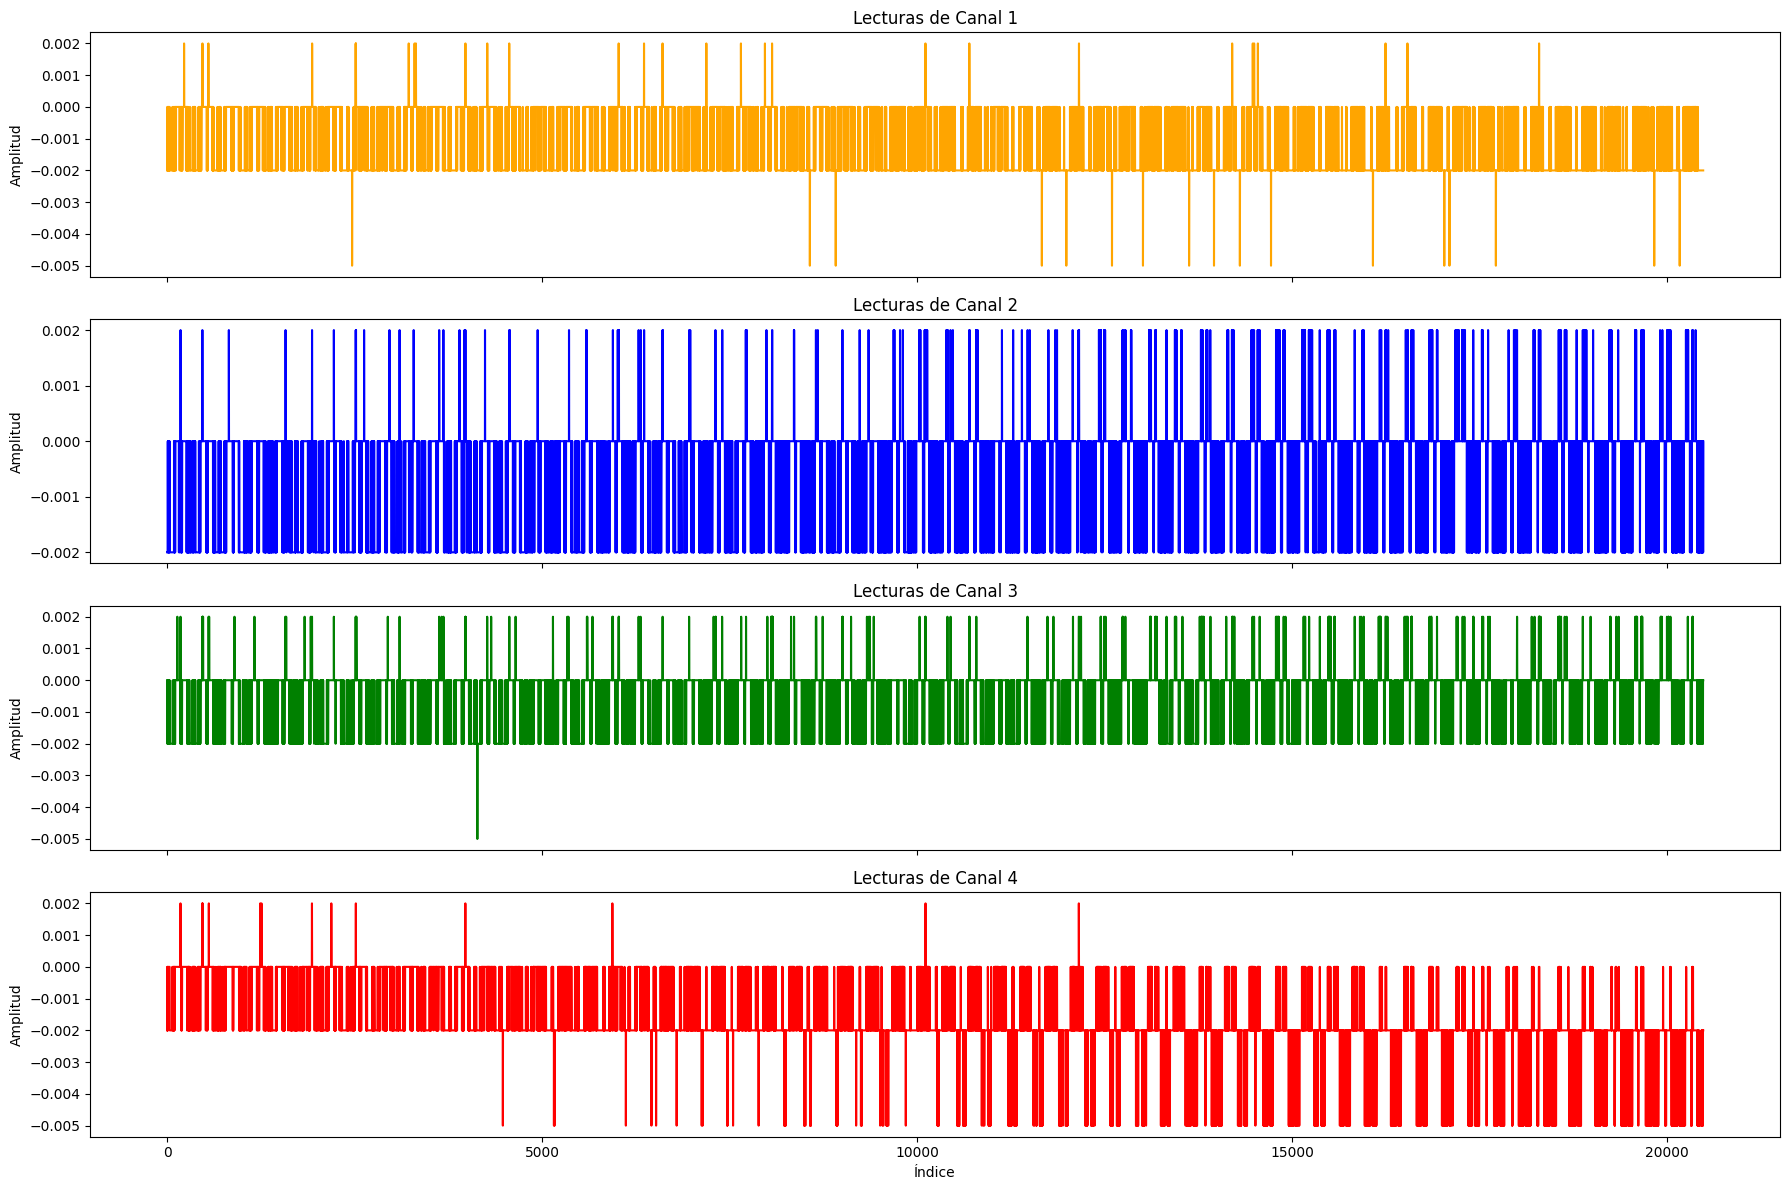

In [119]:
# Visualización de un ejemplo de señal cuadrada (último archivo del 2nd_test)
dataset = cargar_archivo(f'{dataset_path_2nd}/2004.02.19.06.22.39')

fig, axs = plt.subplots(4, 1, figsize=(18, 12), sharex=True)

canales = ['Canal 1', 'Canal 2', 'Canal 3', 'Canal 4']
colores = ['orange', 'blue', 'green', 'red']

for i, (canal, color) in enumerate(zip(canales, colores)):
    axs[i].plot(dataset[canal], color=color)
    axs[i].set_title(f'Lecturas de {canal}')
    axs[i].set_ylabel('Amplitud')

axs[-1].set_xlabel('Índice')
plt.tight_layout()
plt.show()

### Amplitud mínima y máxima
A simple vista se puede distinguir que las señales con forma cuadrada presentan una amplitud mucho menor a las que no. Por lo que se plantea usar las amplitudes del último archivo como refencia para discriminar a los demás archivos y encontrar más señales cuadradas.

In [18]:
# Umbrales para determinar si la señal es cuadrada
amplitude_canal1 = dataset['Canal 1'].max() + abs( dataset['Canal 1'].min() )
amplitude_canal2 = dataset['Canal 2'].max() + abs( dataset['Canal 2'].min() )
amplitude_canal3 = dataset['Canal 3'].max() + abs( dataset['Canal 3'].min() )
amplitude_canal4 = dataset['Canal 4'].max() + abs( dataset['Canal 4'].min() )

print(f"amplitud del canal 1 : {amplitude_canal1}")
print(f"amplitud del canal 2 : {amplitude_canal2}")
print(f"amplitud del canal 3 : {amplitude_canal3}")
print(f"amplitud del canal 4 : {amplitude_canal4}")


amplitud del canal 1 : 0.007
amplitud del canal 2 : 0.004
amplitud del canal 3 : 0.007
amplitud del canal 4 : 0.007


In [60]:
""" Diccionario para almacenar las señales cuadradas de cada canal.
Las claves de este corresponden a la ruta de los archivos y los valores son los canales con señal cuadrada."""
files_signal_square = {}
coef_mult = 59  # Coeficiente para ajustar el umbral 
# Nota: a penas con coeficientes mayores a 59 se empiezan a detectar más de 2 archivos


for file_name in os.listdir(dataset_path_2nd) :
    file_path = os.path.join(dataset_path_2nd, file_name)
    
    try:
        df = pd.read_csv(file_path, sep='\t', header=None) # Assuming no header and tab separation
        df.columns = ['Canal 1','Canal 2','Canal 3','Canal 4']
        
        canales_cuadrados = []
        
        # Verificar si cada canal tiene una señal cuadrada
        if df['Canal 1'].max() + abs( df['Canal 1'].min() ) <= amplitude_canal1 * coef_mult:
            canales_cuadrados.append('Canal 1')
        if df['Canal 2'].max() + abs( df['Canal 2'].min() ) <= amplitude_canal2 * coef_mult:
            canales_cuadrados.append('Canal 2')
        if df['Canal 3'].max() + abs( df['Canal 3'].min() ) <= amplitude_canal3 * coef_mult:
            canales_cuadrados.append('Canal 3')
        if df['Canal 4'].max() + abs( df['Canal 4'].min() ) <= amplitude_canal4 * coef_mult:
            canales_cuadrados.append('Canal 4')
        
        if canales_cuadrados: # Si se encontró al menos un canal con señal cuadrada
            files_signal_square[file_path] = canales_cuadrados
            
    except Exception as e:
        print(f"Could not read file {file_name}: {e}")

print(f"Se encontraron {len(files_signal_square)} archivos con señales cuadradas.")


Se encontraron 7 archivos con señales cuadradas.


In [61]:
files_signal_square

{'datos/IMS_bearing_dataset/2nd_test/2nd_test/2004.02.16.08.42.39': ['Canal 4'],
 'datos/IMS_bearing_dataset/2nd_test/2nd_test/2004.02.15.06.12.39': ['Canal 4'],
 'datos/IMS_bearing_dataset/2nd_test/2nd_test/2004.02.15.10.32.39': ['Canal 4'],
 'datos/IMS_bearing_dataset/2nd_test/2nd_test/2004.02.15.17.52.39': ['Canal 4'],
 'datos/IMS_bearing_dataset/2nd_test/2nd_test/2004.02.19.06.22.39': ['Canal 1',
  'Canal 2',
  'Canal 3',
  'Canal 4'],
 'datos/IMS_bearing_dataset/2nd_test/2nd_test/2004.02.14.16.32.39': ['Canal 4'],
 'datos/IMS_bearing_dataset/2nd_test/2nd_test/2004.02.19.06.12.39': ['Canal 1',
  'Canal 2',
  'Canal 3',
  'Canal 4']}

In [65]:
list(files_signal_square.keys())[0]

'datos/IMS_bearing_dataset/2nd_test/2nd_test/2004.02.16.08.42.39'

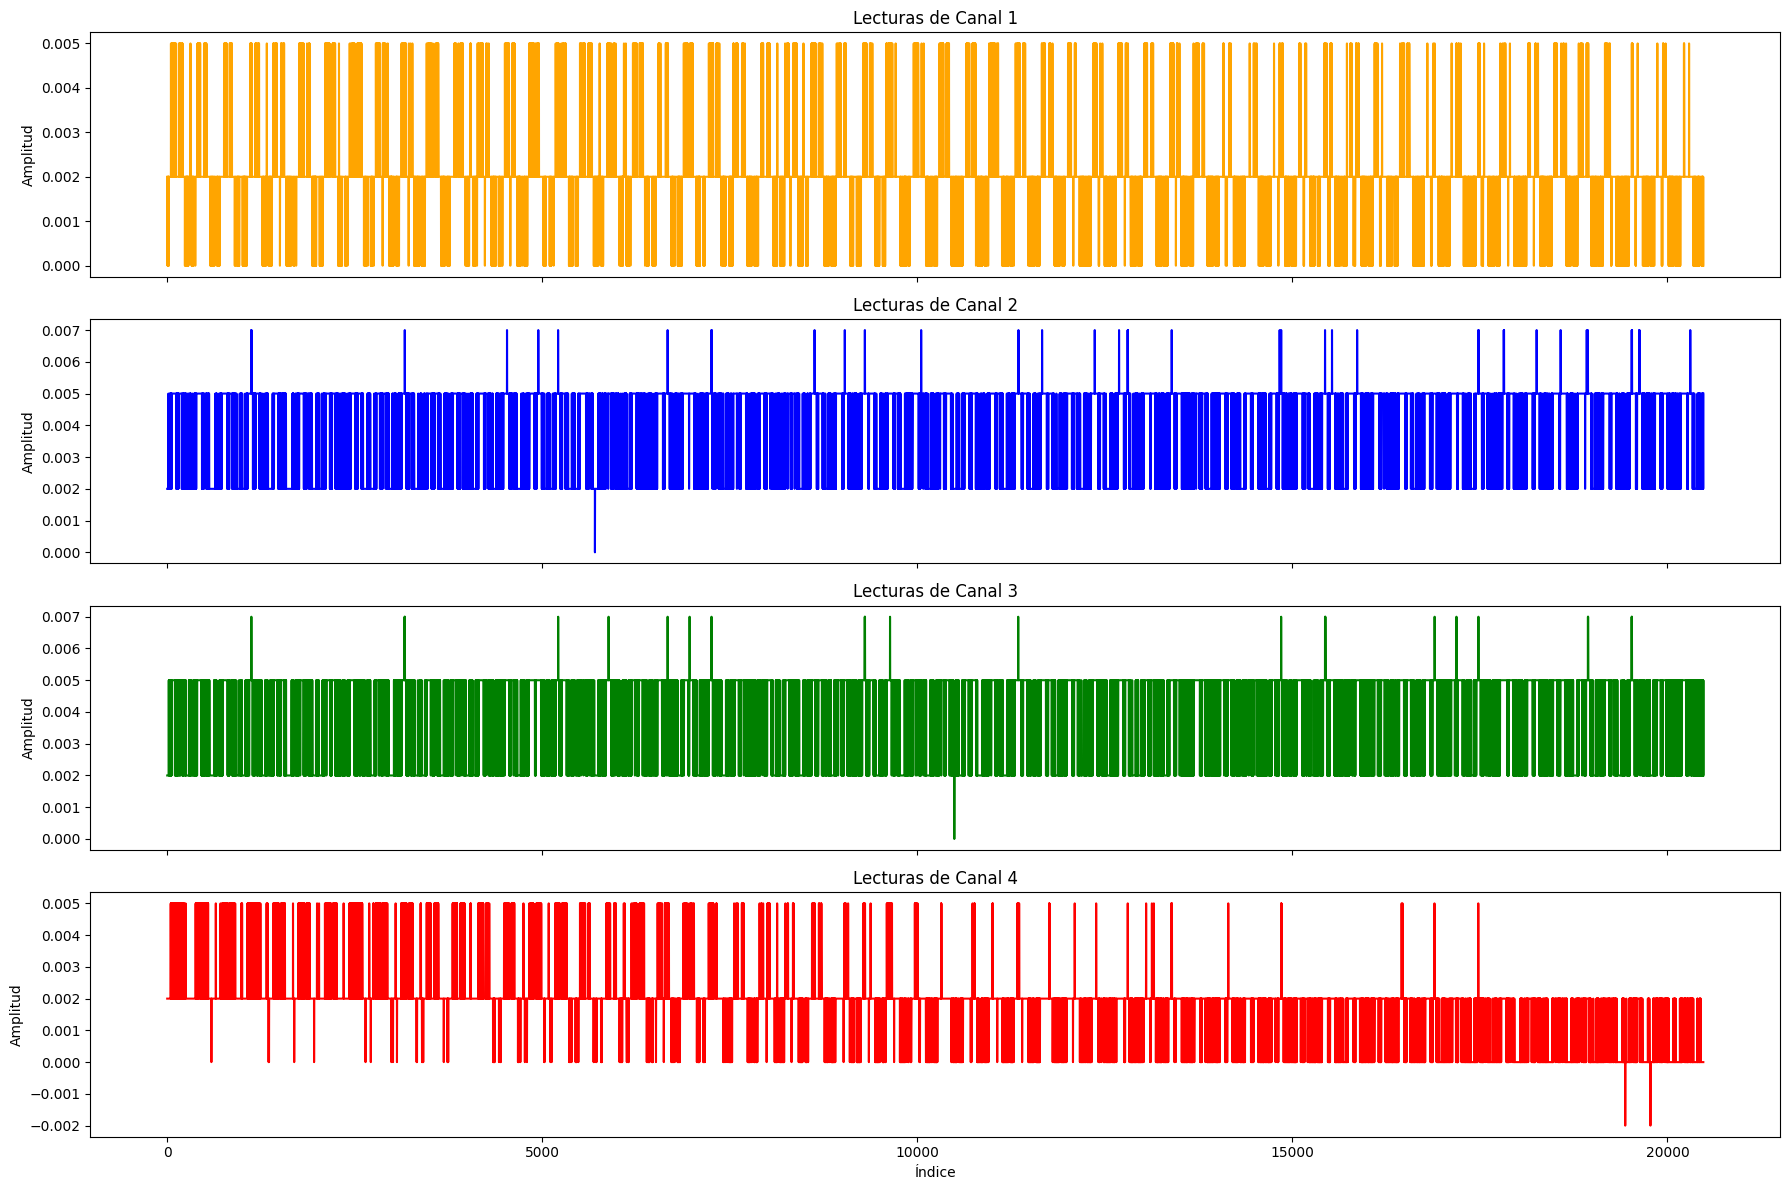

In [71]:
dataset = cargar_archivo(list(files_signal_square.keys())[6])

fig, axs = plt.subplots(4, 1, figsize=(18, 12), sharex=True)

canales = ['Canal 1', 'Canal 2', 'Canal 3', 'Canal 4']
colores = ['orange', 'blue', 'green', 'red']

for i, (canal, color) in enumerate(zip(canales, colores)):
    axs[i].plot(dataset[canal], color=color)
    axs[i].set_title(f'Lecturas de {canal}')
    axs[i].set_ylabel('Amplitud')

axs[-1].set_xlabel('Índice')
plt.tight_layout()
plt.show()

**Análisis**

Se encontraron 1 archivo difente al último archivo del 2nd_test, el cual si presentaba señales cuadradas. Se intentó aumentando los valores de referencia multiplicandolos con un coeficiente, pero sólo con coeficientes mayores a 59 se pudo detectar más de 2 archivos. Obteniendo 7, donde los otros 5 no presentaban señales cuadradas.



### Estadísticos básicos

In [ ]:
dataset.describe()

,Canal 1,Canal 2,Canal 3,Canal 4
count,20479.000000,20479.000000,20479.000000,20479.000000
mean,-0.001162,-0.000701,-0.000664,-0.001695
std,0.001000,0.001021,0.000996,0.001280
min,-0.005000,-0.002000,-0.005000,-0.005000
25%,-0.002000,-0.002000,-0.002000,-0.002000
50%,-0.002000,0.000000,0.000000,-0.002000
75%,0.000000,0.000000,0.000000,0.000000
max,0.002000,0.002000,0.002000,0.002000


In [ ]:
# Se carga el primer archivo del 2nd_test par comparar los valores con el archivo con señal cuadrada
dataset_normal = cargar_archivo(f'{dataset_path_2nd}/2004.02.12.10.32.39')
dataset_normal.describe()


,Canal 1,Canal 2,Canal 3,Canal 4
count,20479.000000,20479.000000,20479.000000,20479.000000
mean,-0.010194,-0.012692,-0.014535,-0.010026
std,0.073478,0.090057,0.108436,0.053169
min,-0.386000,-0.513000,-0.911000,-0.264000
25%,-0.059000,-0.073000,-0.081000,-0.046000
50%,-0.010000,-0.015000,-0.015000,-0.010000
75%,0.037000,0.046000,0.051000,0.027000
max,0.454000,0.464000,1.023000,0.193000


In [ ]:
# Búsqueda de señales cuadradas usando la desviación estándar

""" Diccionario para almacenar las señales cuadradas de cada canal.
Las claves de este corresponden a la ruta de los archivos y los valores son los canales con señal cuadrada."""
files_signal_square = {}
coef_mult = 1  # Coeficiente para ajustar el umbral 

std_canal1 = dataset['Canal 1'].std()
std_canal2 = dataset['Canal 2'].std()
std_canal3 = dataset['Canal 3'].std()
std_canal4 = dataset['Canal 4'].std()

for file_name in os.listdir(dataset_path_2nd) :
    file_path = os.path.join(dataset_path_2nd, file_name)
    
    try:
        df = pd.read_csv(file_path, sep='\t', header=None) # Assuming no header and tab separation
        df.columns = ['Canal 1','Canal 2','Canal 3','Canal 4']
        
        canales_cuadrados = []
        
        # Verificar si cada canal tiene una señal cuadrada
        if df['Canal 1'].std() <= std_canal1 * coef_mult:
            canales_cuadrados.append('Canal 1')
        if df['Canal 2'].std() <= std_canal2 * coef_mult:
            canales_cuadrados.append('Canal 2')
        if df['Canal 3'].std() <= std_canal3 * coef_mult:
            canales_cuadrados.append('Canal 3')
        if df['Canal 4'].std() <= std_canal4 * coef_mult:
            canales_cuadrados.append('Canal 4')
        
        if canales_cuadrados: # Si se encontró al menos un canal con señal cuadrada
            files_signal_square[file_path] = canales_cuadrados
            
    except Exception as e:
        print(f"Could not read file {file_name}: {e}")

print(f"Se encontraron {len(files_signal_square)} archivos con señales cuadradas.")


Se encontraron 2 archivos con señales cuadradas.


In [ ]:
# Se observa que son los mismos archivos obtenidos con el método de amplitud
files_signal_square

{'datos/IMS_bearing_dataset/2nd_test/2nd_test/2004.02.19.06.22.39': ['Canal 1',
  'Canal 4'],
 'datos/IMS_bearing_dataset/2nd_test/2nd_test/2004.02.19.06.12.39': ['Canal 1',
  'Canal 4']}

In [127]:
list(files_signal_square.keys())[0]

'datos/IMS_bearing_dataset/2nd_test/2nd_test/2004.02.19.06.22.39'

In [131]:
# Búsqueda de señales cuadradas usando el promedio

""" Diccionario para almacenar las señales cuadradas de cada canal.
Las claves de este corresponden a la ruta de los archivos y los valores son los canales con señal cuadrada."""
files_signal_square = {}
coef_mult = 1  # Coeficiente para ajustar el umbral 

dataset = cargar_archivo(f'{dataset_path_2nd}/2004.02.19.06.22.39')
mean_canal1 = dataset['Canal 1'].mean()
mean_canal2 = dataset['Canal 2'].mean()
mean_canal3 = dataset['Canal 3'].mean()
mean_canal4 = dataset['Canal 4'].mean()

for file_name in os.listdir(dataset_path_2nd) :
    file_path = os.path.join(dataset_path_2nd, file_name)
    
    try:
        df = pd.read_csv(file_path, sep='\t', header=None) # Assuming no header and tab separation
        df.columns = ['Canal 1','Canal 2','Canal 3','Canal 4']
        
        canales_cuadrados = []
        
        # Verificar si cada canal tiene una señal cuadrada
        if df['Canal 1'].mean() <= mean_canal1 * coef_mult:
            canales_cuadrados.append('Canal 1')
        if df['Canal 2'].mean() <= mean_canal2 * coef_mult:
            canales_cuadrados.append('Canal 2')
        if df['Canal 3'].mean() <= mean_canal3 * coef_mult:
            canales_cuadrados.append('Canal 3')
        if df['Canal 4'].mean() <= mean_canal4 * coef_mult:
            canales_cuadrados.append('Canal 4')
        
        if canales_cuadrados: # Si se encontró al menos un canal con señal cuadrada
            files_signal_square[file_path] = canales_cuadrados
            
    except Exception as e:
        print(f"Could not read file {file_name}: {e}")

print(f"Se encontraron {len(files_signal_square)} archivos con señales cuadradas.\n\n")
files_signal_square

Se encontraron 983 archivos con señales cuadradas.




{'datos/IMS_bearing_dataset/2nd_test/2nd_test/2004.02.16.08.12.39': ['Canal 1',
  'Canal 2',
  'Canal 3',
  'Canal 4'],
 'datos/IMS_bearing_dataset/2nd_test/2nd_test/2004.02.12.12.32.39': ['Canal 1',
  'Canal 2',
  'Canal 3',
  'Canal 4'],
 'datos/IMS_bearing_dataset/2nd_test/2nd_test/2004.02.15.09.52.39': ['Canal 1',
  'Canal 3',
  'Canal 4'],
 'datos/IMS_bearing_dataset/2nd_test/2nd_test/2004.02.14.15.22.39': ['Canal 1',
  'Canal 2',
  'Canal 4'],
 'datos/IMS_bearing_dataset/2nd_test/2nd_test/2004.02.15.04.22.39': ['Canal 1',
  'Canal 2',
  'Canal 3',
  'Canal 4'],
 'datos/IMS_bearing_dataset/2nd_test/2nd_test/2004.02.15.16.32.39': ['Canal 1',
  'Canal 2',
  'Canal 3',
  'Canal 4'],
 'datos/IMS_bearing_dataset/2nd_test/2nd_test/2004.02.16.22.32.39': ['Canal 1',
  'Canal 3',
  'Canal 4'],
 'datos/IMS_bearing_dataset/2nd_test/2nd_test/2004.02.17.13.22.39': ['Canal 1',
  'Canal 2',
  'Canal 3',
  'Canal 4'],
 'datos/IMS_bearing_dataset/2nd_test/2nd_test/2004.02.17.15.12.39': ['Canal 1',

**Análisis**

Se observó algunos de los archivos devueltos comparando el promedio, sin embargo estos no presentaban una forma cuadrada.
El promedio entonces, como medida estadística, no nos ayuda a distinguir si una señal es cudrada de las que no. Esto posiblemente porque el promedio nos provee una forma de observar la concentración de los datos, pero nos nos permite distinguir que tanto cambian los datos que es precisamete los que búscamos.

Tampoco se empleará el conteo ya que no presenta alguna distinción para las señales cuadradas. Finalmente,  no se hicieron pruebas con los cuantiles ya que el análisis con estos valores es similar al obtenido con la amplidud (recordemos que esta la calculamos restando al máximo y el mínimo).


## Datos Estadísticos: 3rd_test

Al igual que en el 2nd_test se procede a realizar las mismas pruebas en los otros experimentos


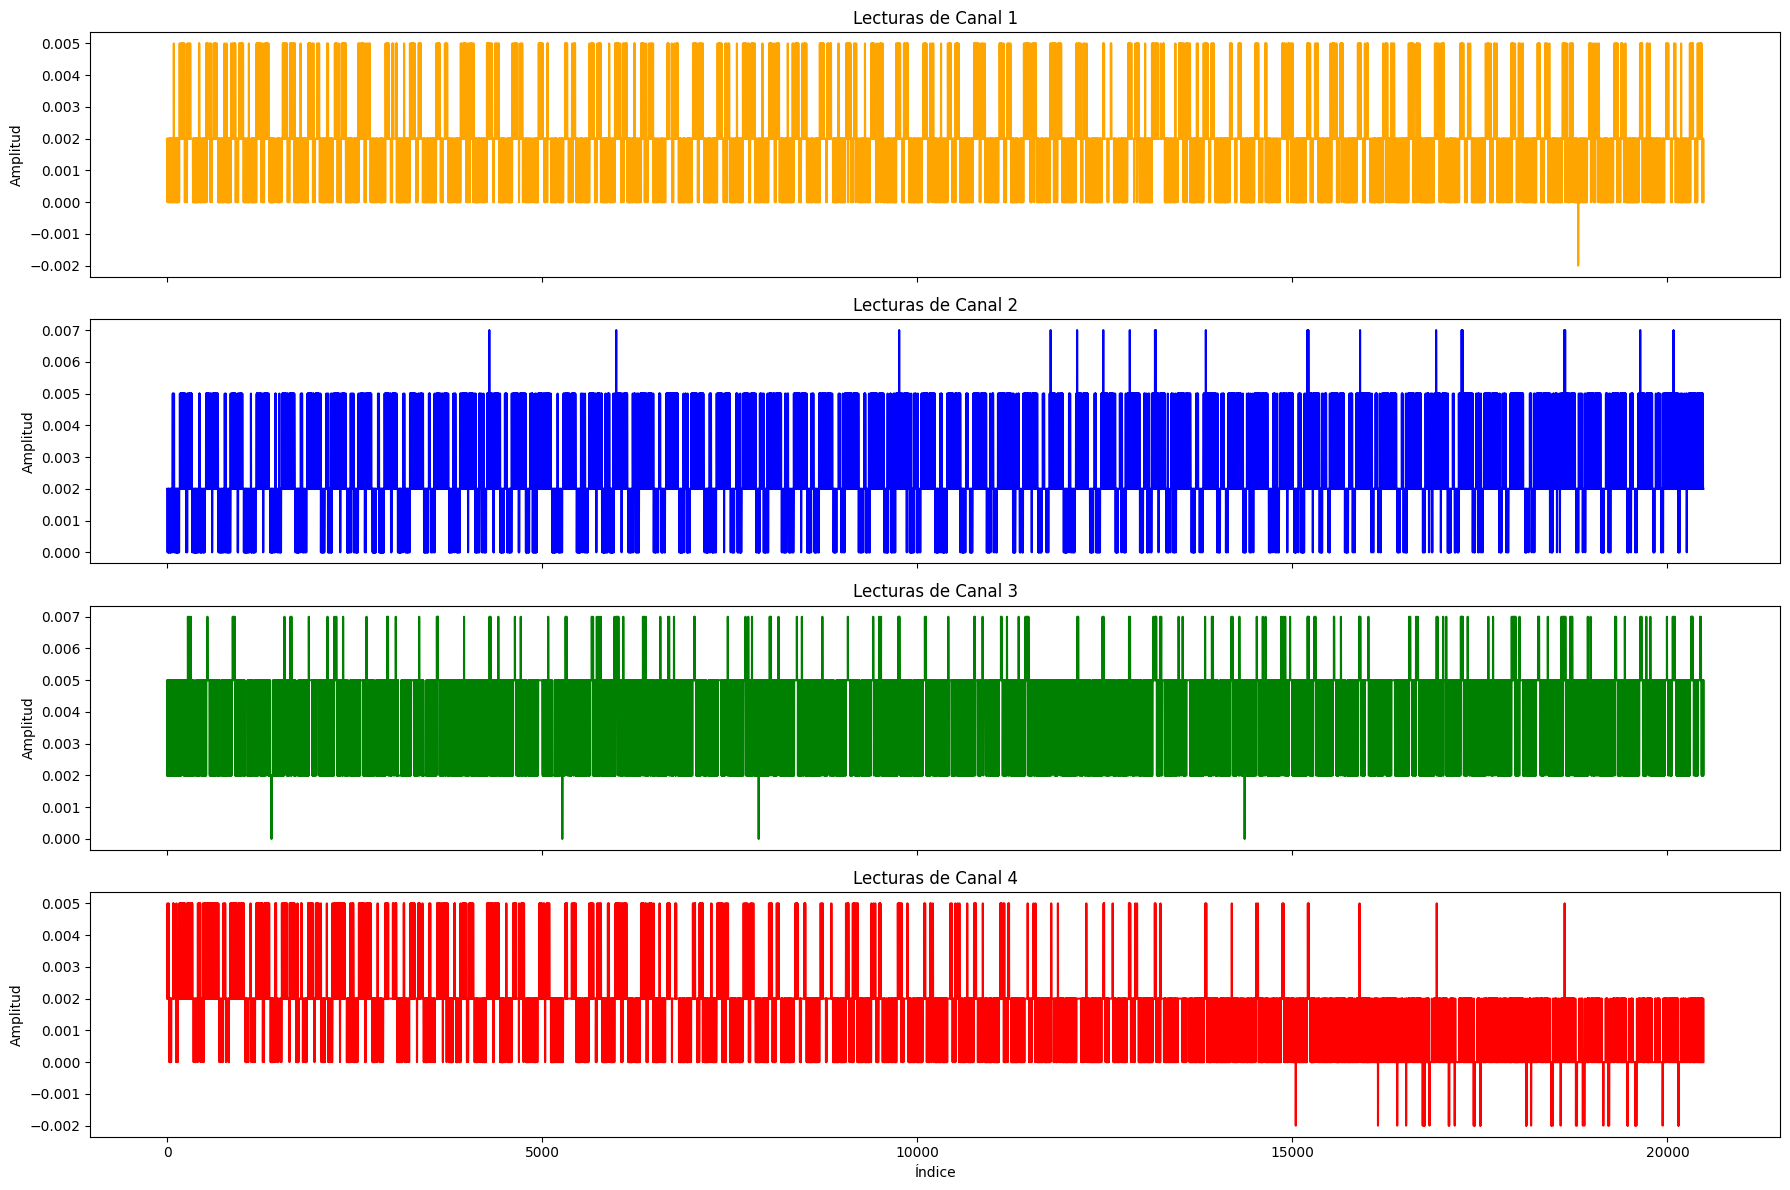

In [8]:
# Visualización de un ejemplo de señal cuadrada (último archivo del 3rd_test)
dataset = cargar_archivo(f'{dataset_path_3rd}/2004.04.18.02.42.55')

fig, axs = plt.subplots(4, 1, figsize=(18, 12), sharex=True)

canales = ['Canal 1', 'Canal 2', 'Canal 3', 'Canal 4']
colores = ['orange', 'blue', 'green', 'red']

for i, (canal, color) in enumerate(zip(canales, colores)):
    axs[i].plot(dataset[canal], color=color)
    axs[i].set_title(f'Lecturas de {canal}')
    axs[i].set_ylabel('Amplitud')

axs[-1].set_xlabel('Índice')
plt.tight_layout()
plt.show()

### Amplitud mínima y máxima
A simple vista se puede distinguir que las señales con forma cuadrada presentan una amplitud mucho menor a las que no. Por lo que se plantea usar las amplitudes del último archivo como refencia para discriminar a los demás archivos y encontrar más señales cuadradas.

In [9]:
# Umbrales para determinar si la señal es cuadrada
amplitude_canal1 = dataset['Canal 1'].max() + abs( dataset['Canal 1'].min() )
amplitude_canal2 = dataset['Canal 2'].max() + abs( dataset['Canal 2'].min() )
amplitude_canal3 = dataset['Canal 3'].max() + abs( dataset['Canal 3'].min() )
amplitude_canal4 = dataset['Canal 4'].max() + abs( dataset['Canal 4'].min() )

print(f"amplitud del canal 1 : {amplitude_canal1}")
print(f"amplitud del canal 2 : {amplitude_canal2}")
print(f"amplitud del canal 3 : {amplitude_canal3}")
print(f"amplitud del canal 4 : {amplitude_canal4}")


amplitud del canal 1 : 0.007
amplitud del canal 2 : 0.007
amplitud del canal 3 : 0.007
amplitud del canal 4 : 0.007


In [10]:
""" Diccionario para almacenar las señales cuadradas de cada canal.
Las claves de este corresponden a la ruta de los archivos y los valores son los canales con señal cuadrada."""
files_signal_square = {}
coef_mult = 53  # Coeficiente para ajustar el umbral 
# Nota: a penas con coeficientes mayores a 51 se empiezan a detectar más de 1 archivo


for file_name in os.listdir(dataset_path_3rd) :
    file_path = os.path.join(dataset_path_3rd, file_name)
    
    try:
        df = pd.read_csv(file_path, sep='\t', header=None) # Assuming no header and tab separation
        df.columns = ['Canal 1','Canal 2','Canal 3','Canal 4']
        
        canales_cuadrados = []
        
        # Verificar si cada canal tiene una señal cuadrada
        if df['Canal 1'].max() + abs( df['Canal 1'].min() ) <= amplitude_canal1 * coef_mult:
            canales_cuadrados.append('Canal 1')
        if df['Canal 2'].max() + abs( df['Canal 2'].min() ) <= amplitude_canal2 * coef_mult:
            canales_cuadrados.append('Canal 2')
        if df['Canal 3'].max() + abs( df['Canal 3'].min() ) <= amplitude_canal3 * coef_mult:
            canales_cuadrados.append('Canal 3')
        if df['Canal 4'].max() + abs( df['Canal 4'].min() ) <= amplitude_canal4 * coef_mult:
            canales_cuadrados.append('Canal 4')
        
        if canales_cuadrados: # Si se encontró al menos un canal con señal cuadrada
            files_signal_square[file_path] = canales_cuadrados
            
    except Exception as e:
        print(f"Could not read file {file_name}: {e}")

print(f"Se encontraron {len(files_signal_square)} archivos con señales cuadradas.")


Se encontraron 3 archivos con señales cuadradas.


In [11]:
files_signal_square

{'datos/IMS_bearing_dataset/3rd_test/4th_test/txt/2004.03.18.07.45.20': ['Canal 4'],
 'datos/IMS_bearing_dataset/3rd_test/4th_test/txt/2004.04.18.02.42.55': ['Canal 1',
  'Canal 2',
  'Canal 3',
  'Canal 4'],
 'datos/IMS_bearing_dataset/3rd_test/4th_test/txt/2004.03.18.06.35.20': ['Canal 4']}

In [12]:
list(files_signal_square.keys())[1]

'datos/IMS_bearing_dataset/3rd_test/4th_test/txt/2004.04.18.02.42.55'

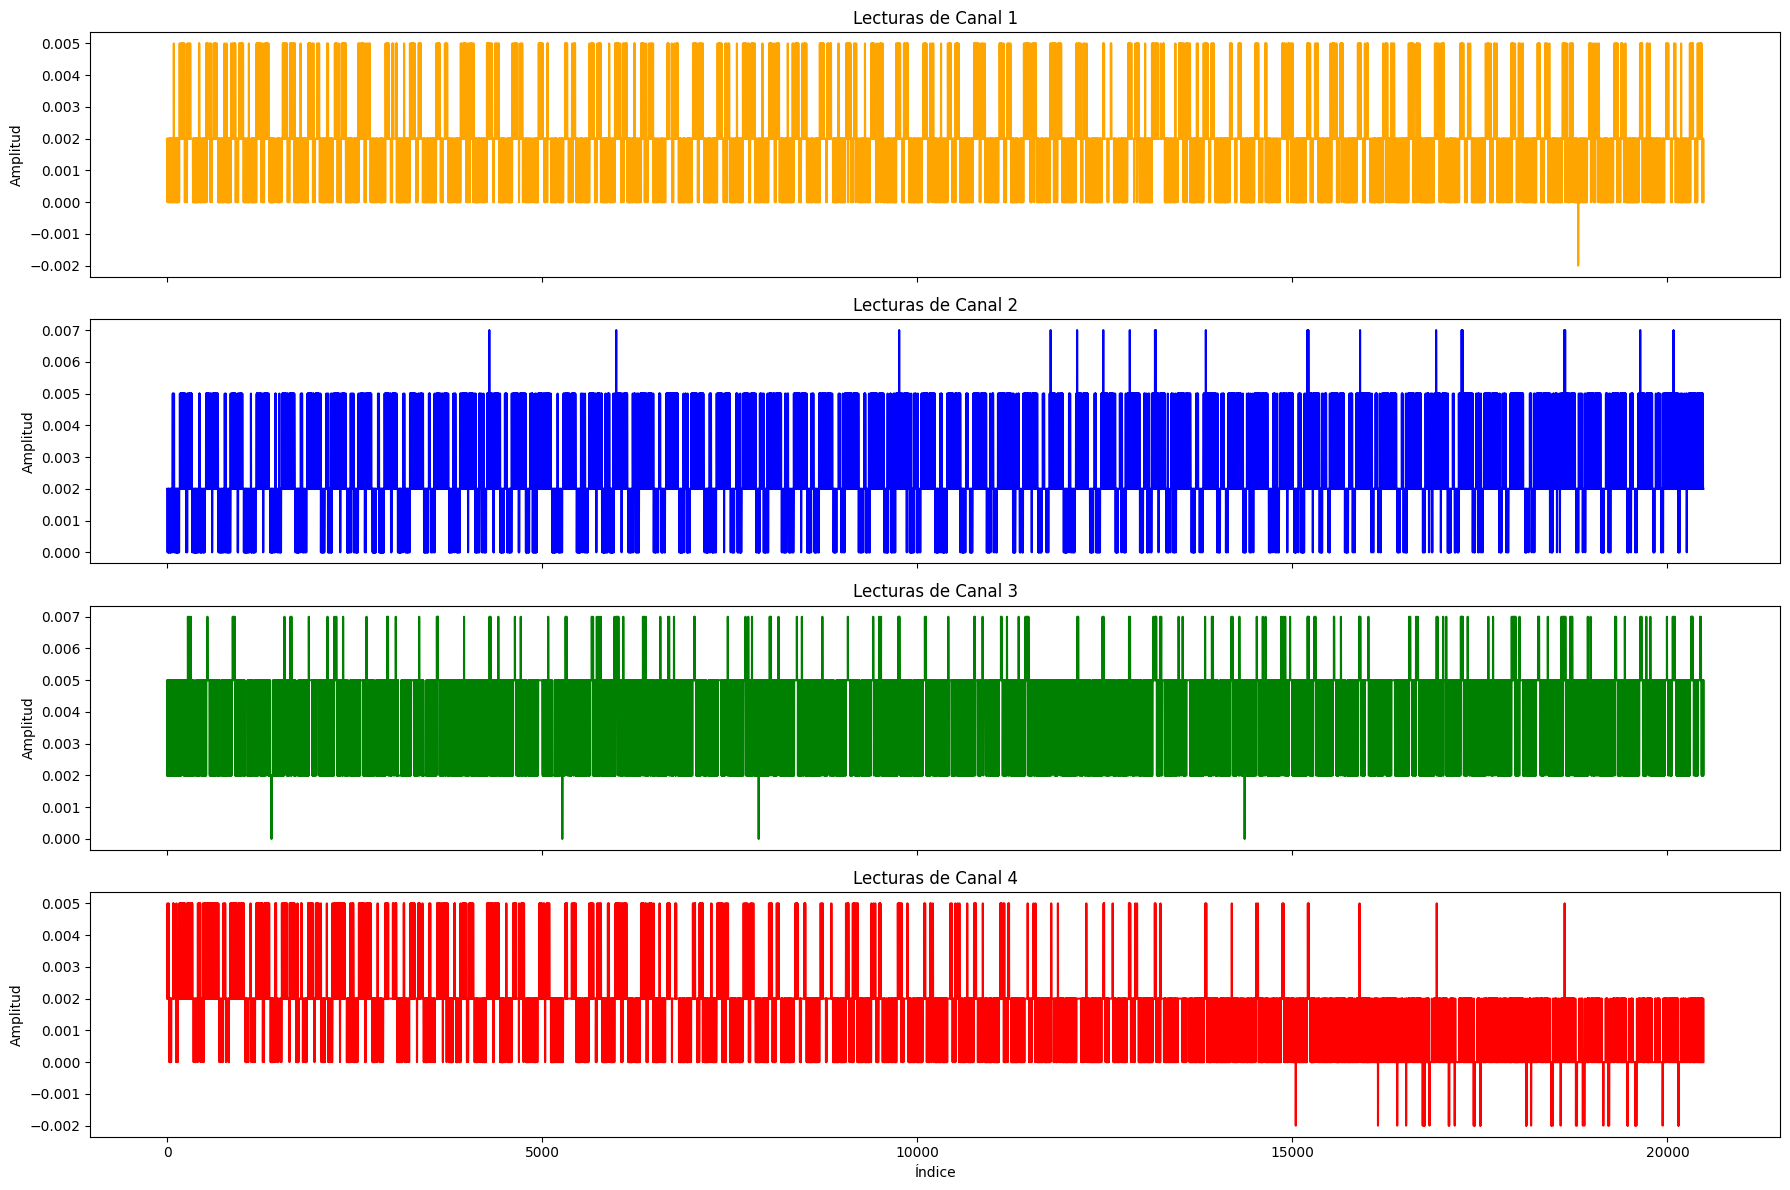

In [14]:
dataset = cargar_archivo(list(files_signal_square.keys())[1])

fig, axs = plt.subplots(4, 1, figsize=(18, 12), sharex=True)

canales = ['Canal 1', 'Canal 2', 'Canal 3', 'Canal 4']
colores = ['orange', 'blue', 'green', 'red']

for i, (canal, color) in enumerate(zip(canales, colores)):
    axs[i].plot(dataset[canal], color=color)
    axs[i].set_title(f'Lecturas de {canal}')
    axs[i].set_ylabel('Amplitud')

axs[-1].set_xlabel('Índice')
plt.tight_layout()
plt.show()

## Datos Estadísticos: 1st_test

Al igual que en el 2nd_test se procede a realizar las mismas pruebas en los otros experimentos.

Dado que en los últimos archivos del experimento 1 no se observaron señales cuadradas se usarán los valores del experimento 2 (2nd_test)


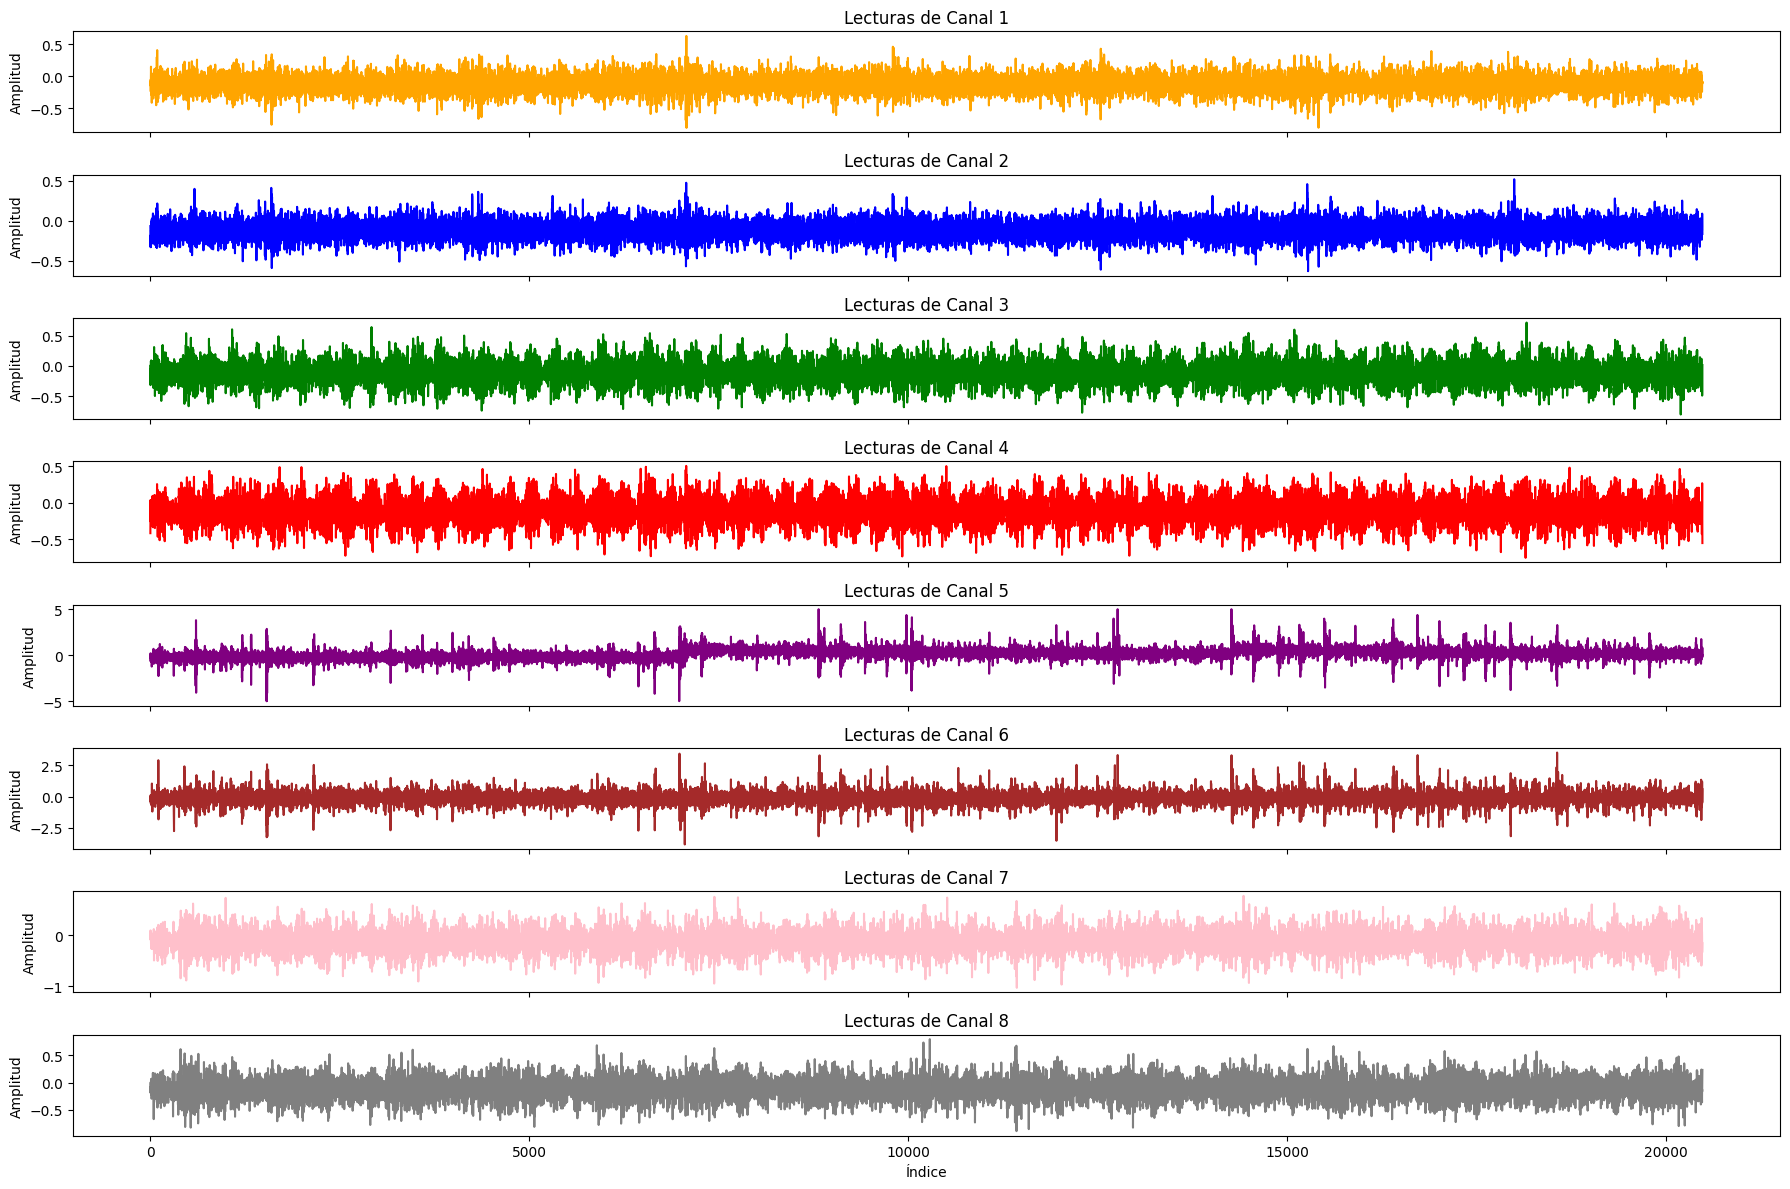

In [102]:
# Visualización de un ejemplo de señal cuadrada (último archivo del 3rd_test)
dataset = cargar_archivo(f'{dataset_path_1st}/2003.11.25.23.39.56')

fig, axs = plt.subplots(8, 1, figsize=(18, 12), sharex=True)

canales = ['Canal 1', 'Canal 2', 'Canal 3', 'Canal 4', 'Canal 5', 'Canal 6', 'Canal 7', 'Canal 8']
colores = ['orange', 'blue', 'green', 'red', 'purple', 'brown', 'pink', 'gray']

for i, (canal, color) in enumerate(zip(canales, colores)):
    axs[i].plot(dataset[canal], color=color)
    axs[i].set_title(f'Lecturas de {canal}')
    axs[i].set_ylabel('Amplitud')

axs[-1].set_xlabel('Índice')
plt.tight_layout()
plt.show()

### Amplitud mínima y máxima
A simple vista se puede distinguir que las señales con forma cuadrada presentan una amplitud mucho menor a las que no. Por lo que se plantea usar las amplitudes del último archivo como refencia para discriminar a los demás archivos y encontrar más señales cuadradas.

In [ ]:
# Umbrales para determinar si la señal es cuadrada. En esta ocasion sólo se usara un valor
dataset2 = cargar_archivo(f'{dataset_path_2nd}/2004.02.19.06.22.39')

amplitude_canal1 = dataset2['Canal 1'].max() + abs( dataset2['Canal 1'].min() )

print(f"amplitud de referencia : {amplitude_canal1}")


amplitud de referencia : 0.007


In [ ]:
""" Diccionario para almacenar las señales cuadradas de cada canal.
Las claves de este corresponden a la ruta de los archivos y los valores son los canales con señal cuadrada."""
files_signal_square = {}
coef_mult = 80  # Coeficiente para ajustar el umbral 
# Nota: a penas con coeficientes mayores a 79 se empiezan a detectar más de 1 archivo


for file_name in os.listdir(dataset_path_1st) :
    file_path = os.path.join(dataset_path_1st, file_name)
    
    try:
        df = pd.read_csv(file_path, sep='\t', header=None) # Assuming no header and tab separation
        df.columns = ['Canal 1','Canal 2','Canal 3','Canal 4', 'Canal 5','Canal 6','Canal 7','Canal 8']
        
        canales_cuadrados = []
        
        # Verificar si cada canal tiene una señal cuadrada
        for canal in df.columns:
            if df[canal].max() + abs( df[canal].min() ) <= amplitude_canal1 * coef_mult:
                canales_cuadrados.append(canal)
        
        if canales_cuadrados: # Si se encontró al menos un canal con señal cuadrada
            files_signal_square[file_path] = canales_cuadrados
            
    except Exception as e:
        print(f"Could not read file {file_name}: {e}")

print(f"Se encontraron {len(files_signal_square)} archivos con señales cuadradas.")


Se encontraron 1 archivos con señales cuadradas.


In [114]:
files_signal_square

{'datos/IMS_bearing_dataset/1st_test/1st_test/2003.10.22.12.29.13': ['Canal 7']}

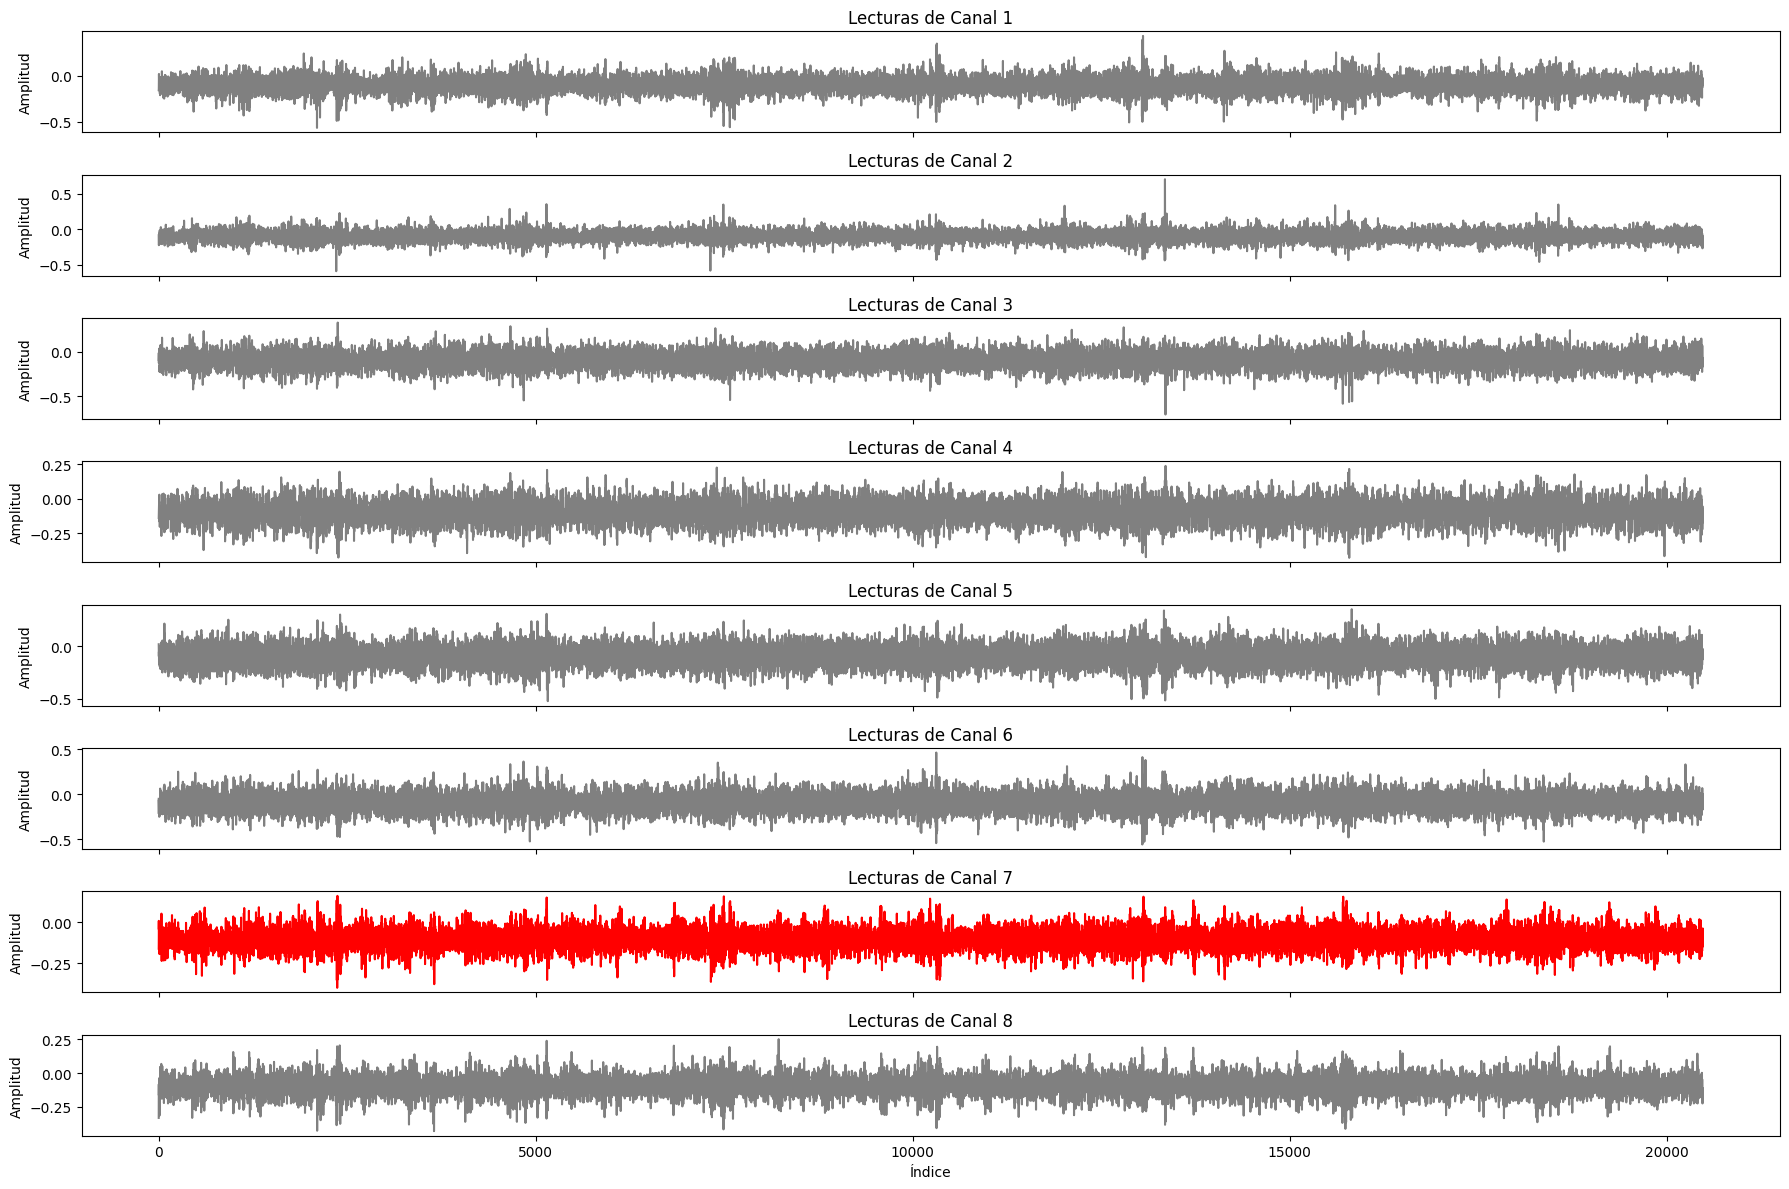

In [118]:
dataset = cargar_archivo(list(files_signal_square.keys())[0])

fig, axs = plt.subplots(8, 1, figsize=(18, 12), sharex=True)

canales = ['Canal 1', 'Canal 2', 'Canal 3', 'Canal 4', 'Canal 5', 'Canal 6', 'Canal 7', 'Canal 8']
colores = ['gray', 'gray', 'gray', 'gray', 'gray', 'gray', 'red', 'gray']

for i, (canal, color) in enumerate(zip(canales, colores)):
    axs[i].plot(dataset[canal], color=color)
    axs[i].set_title(f'Lecturas de {canal}')
    axs[i].set_ylabel('Amplitud')

axs[-1].set_xlabel('Índice')
plt.tight_layout()
plt.show()

## Conclusiones

* En el experimento 1st_test no se hallaron señales cuadradas. Ni se halló alguna medición con amplitudes cercanas a las de señal cuadrada (se emplearon los valores del 2nd_test para la búsqueda).
* En el Experimento 2nd_test sólo los archivos "2004.02.19.06.22.39" y "2004.02.19.06.12.39" presentaron señales cuadradas. Estos dos corresponden al último y penultimo archivo. 
* En el experimento 3rd_test sólo el archivo "2004.04.18.02.42.55" presentaba una señal cuadrada, este corresponde al último archivo.


* La ficha de información del dataset indica que hubieron cortes durante las pruebas. Inicialmente se creía que las señales cuadradas podrían haber sido causadas por las interrupciones durante la medición. Sin embargo dado que no se hallaron señales cuadradas en puntos medios del dataset (sólamente en las mediciones finales) ahora se plantea revisar la presencia de los cortes mencionados en la ficha de información del dataset.

## Interrupciones de tiempo 

Se procede a realizar un dataframe que permita observar la cantidad de tiempo que transcurrió entre cada medición con la intención de inspeccionar si las mediciones previas a ceses o interrupciones presentan señales cuadradas.

In [52]:
import os

# Listar los nombres de los archivos en dataset_path_1st
archivos_1st_test = os.listdir(dataset_path_1st)
archivos_2nd_test = os.listdir(dataset_path_2nd)
archivos_3rd_test = os.listdir(dataset_path_3rd)
print(archivos_1st_test)

['2003.11.01.02.51.44', '2003.11.19.16.06.07', '2003.11.19.12.46.07', '2003.11.21.18.56.56', '2003.11.16.15.08.46', '2003.11.21.17.36.56', '2003.11.22.02.26.56', '2003.11.22.04.16.56', '2003.11.20.19.49.03', '2003.11.23.06.26.56', '2003.10.31.16.41.44', '2003.11.23.12.06.56', '2003.11.21.04.54.03', '2003.11.23.21.41.24', '2003.10.29.15.09.46', '2003.11.09.14.35.58', '2003.11.19.21.26.07', '2003.11.19.12.06.07', '2003.10.31.23.31.44', '2003.10.31.18.41.44', '2003.11.16.05.08.46', '2003.11.18.08.02.30', '2003.11.24.01.11.24', '2003.11.01.14.31.44', '2003.11.19.13.16.07', '2003.11.15.02.38.46', '2003.11.20.18.34.03', '2003.11.23.04.46.56', '2003.11.01.19.51.44', '2003.11.21.17.46.56', '2003.10.29.16.09.46', '2003.11.25.11.47.32', '2003.11.25.15.17.32', '2003.11.15.00.18.46', '2003.10.29.15.29.46', '2003.10.31.18.21.44', '2003.11.18.13.02.30', '2003.11.08.14.31.44', '2003.11.21.15.08.36', '2003.11.16.11.48.46', '2003.10.31.05.29.46', '2003.11.18.14.42.30', '2003.11.21.23.16.56', '2003.11.2

In [53]:
def crear_arreglo_diferencias(archivos):
    archivos_ordenados = sorted(archivos)
    diferencias = {}
    for i in range(1, len(archivos_ordenados)):
        s0 = pd.to_datetime(archivos_ordenados[i-1], format="%Y.%m.%d.%H.%M.%S", errors="raise")
        s1 = pd.to_datetime(archivos_ordenados[i], format="%Y.%m.%d.%H.%M.%S", errors="raise")
        diff = s1 - s0
        diferencias[f"{archivos_ordenados[i-1]} - {archivos_ordenados[i]}"] = diff.total_seconds()
    return diferencias

diferencias_1st_test = crear_arreglo_diferencias(archivos_1st_test)
diferencias_2nd_test = crear_arreglo_diferencias(archivos_2nd_test)
diferencias_3rd_test = crear_arreglo_diferencias(archivos_3rd_test)

print(diferencias_1st_test)

{'2003.10.22.12.06.24 - 2003.10.22.12.09.13': 169.0, '2003.10.22.12.09.13 - 2003.10.22.12.14.13': 300.0, '2003.10.22.12.14.13 - 2003.10.22.12.19.13': 300.0, '2003.10.22.12.19.13 - 2003.10.22.12.24.13': 300.0, '2003.10.22.12.24.13 - 2003.10.22.12.29.13': 300.0, '2003.10.22.12.29.13 - 2003.10.22.12.34.13': 300.0, '2003.10.22.12.34.13 - 2003.10.22.12.39.13': 300.0, '2003.10.22.12.39.13 - 2003.10.22.12.44.13': 300.0, '2003.10.22.12.44.13 - 2003.10.22.12.49.13': 300.0, '2003.10.22.12.49.13 - 2003.10.22.12.54.13': 300.0, '2003.10.22.12.54.13 - 2003.10.22.12.59.13': 300.0, '2003.10.22.12.59.13 - 2003.10.22.13.04.13': 300.0, '2003.10.22.13.04.13 - 2003.10.22.13.09.13': 300.0, '2003.10.22.13.09.13 - 2003.10.22.13.14.13': 300.0, '2003.10.22.13.14.13 - 2003.10.22.13.19.13': 300.0, '2003.10.22.13.19.13 - 2003.10.22.13.24.13': 300.0, '2003.10.22.13.24.13 - 2003.10.22.13.29.13': 300.0, '2003.10.22.13.29.13 - 2003.10.22.13.34.13': 300.0, '2003.10.22.13.34.13 - 2003.10.22.13.39.13': 300.0, '2003.10.22

In [54]:
import pandas as pd

FMT = "%Y.%m.%d.%H.%M.%S"

def crear_dataframe_diferencias(archivos, sort=True):
    # Crear DataFrame con los timestamps finales
    stamps = pd.DataFrame(archivos, columns=["s1"])
    # Ordenar los timestamps
    if sort:
        stamps = stamps.sort_values(by="s1",ascending=True).reset_index(drop=True)

    # Crear DataFrame con los timestamps iniciales
    stamps['s0'] = stamps['s1'].shift(1) # Desplazar hacia abajo para obtener el timestamp anterior

    s0 = pd.to_datetime(stamps['s0'], format=FMT)
    s1 = pd.to_datetime(stamps['s1'], format=FMT)

    # Calcular diferencias de tiempo
    stamps['diff'] = (s1 - s0)
    stamps['diff_secs'] = (s1 - s0).dt.total_seconds()
    stamps['diff_mins'] = stamps['diff_secs'] / 60.0
    stamps['diff_h'] = stamps['diff_secs'] / 3600.0

    return stamps


stamps_1st_test = crear_dataframe_diferencias(archivos_1st_test)
stamps_2nd_test = crear_dataframe_diferencias(archivos_2nd_test)
stamps_3rd_test = crear_dataframe_diferencias(archivos_3rd_test)

stamps_1st_test

,s1,s0,diff,diff_secs,diff_mins,diff_h
0,2003.10.22.12.06.24,None,NaT,NaN,NaN,NaN
1,2003.10.22.12.09.13,2003.10.22.12.06.24,0 days 00:02:49,169.0,2.816667,0.046944
2,2003.10.22.12.14.13,2003.10.22.12.09.13,0 days 00:05:00,300.0,5.000000,0.083333
3,2003.10.22.12.19.13,2003.10.22.12.14.13,0 days 00:05:00,300.0,5.000000,0.083333
4,2003.10.22.12.24.13,2003.10.22.12.19.13,0 days 00:05:00,300.0,5.000000,0.083333
...,...,...,...,...,...,...
2151,2003.11.25.16.07.32,2003.11.25.15.57.32,0 days 00:10:00,600.0,10.000000,0.166667
2152,2003.11.25.23.13.21,2003.11.25.16.07.32,0 days 07:05:49,25549.0,425.816667,7.096944
2153,2003.11.25.23.19.56,2003.11.25.23.13.21,0 days 00:06:35,395.0,6.583333,0.109722
2154,2003.11.25.23.29.56,2003.11.25.23.19.56,0 days 00:10:00,600.0,10.000000,0.166667


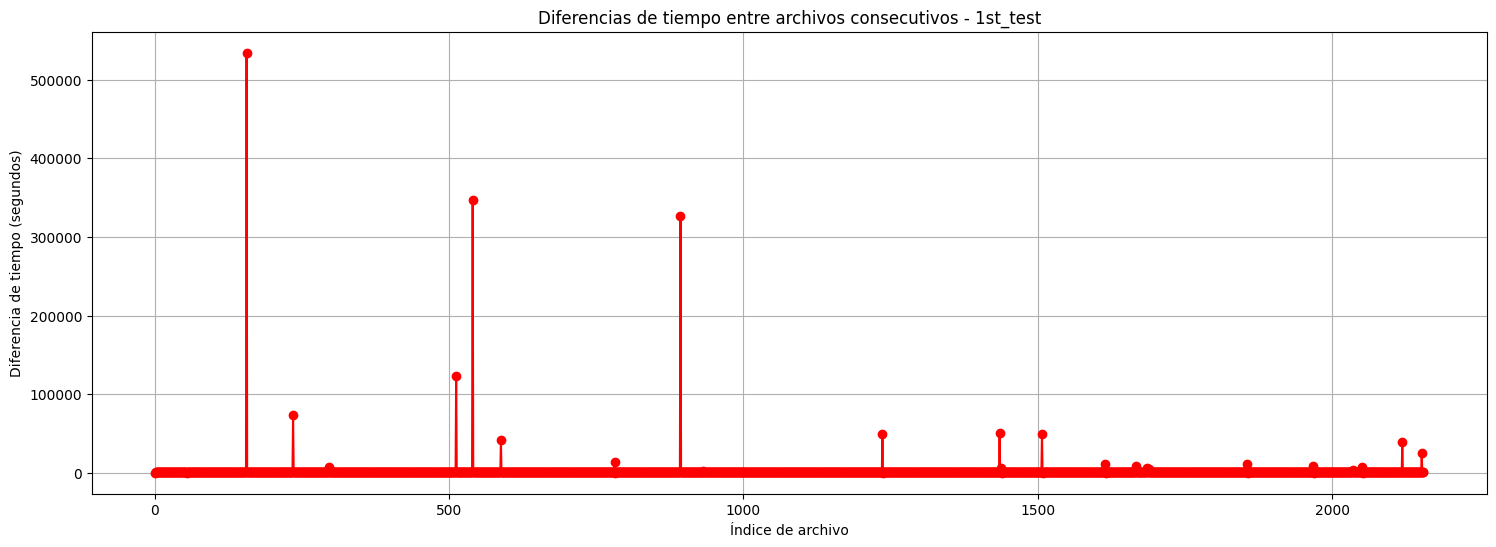

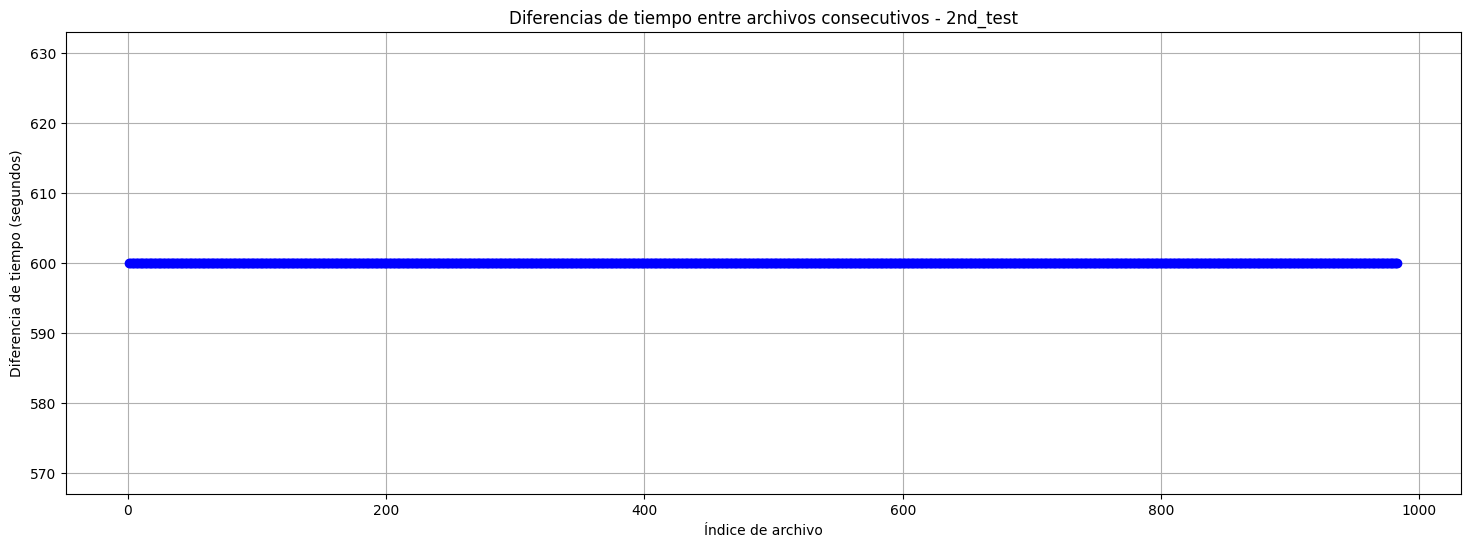

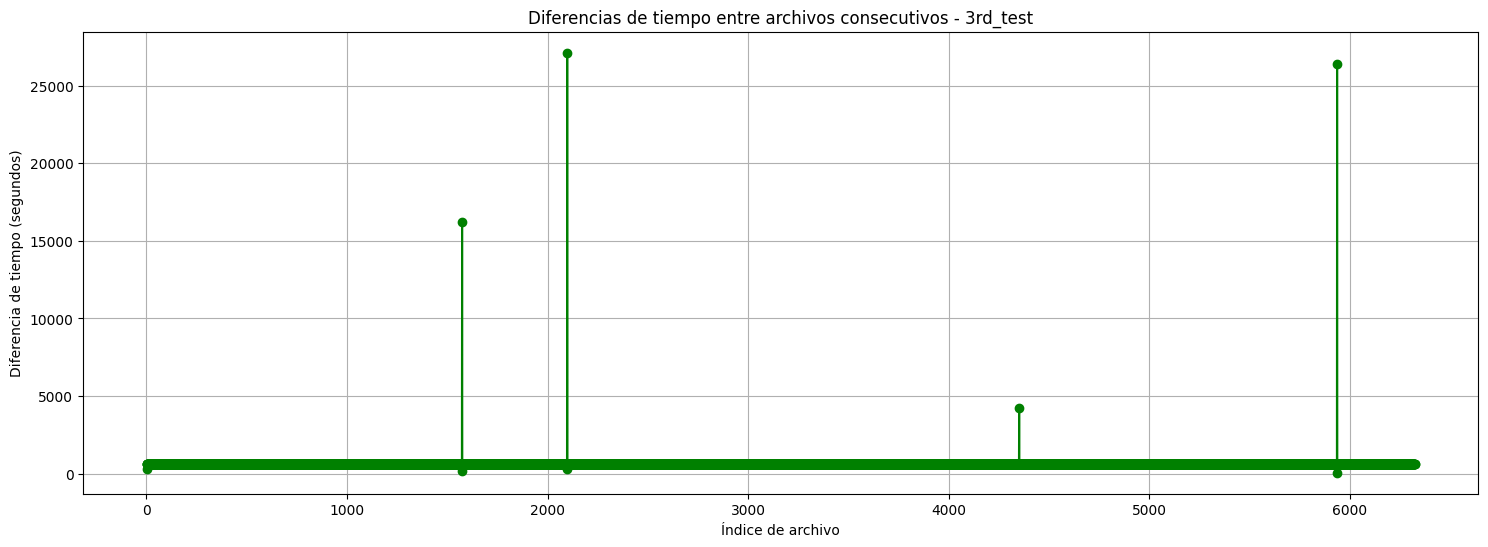

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))
plt.plot(stamps_1st_test['diff_secs'], marker='o', linestyle='-', color='red')
plt.title('Diferencias de tiempo entre archivos consecutivos - 1st_test')
plt.xlabel('Índice de archivo')
plt.ylabel('Diferencia de tiempo (segundos)')
plt.grid(True)
plt.show()

plt.figure(figsize=(18, 6))
plt.plot(stamps_2nd_test['diff_secs'], marker='o', linestyle='-', color='blue')
plt.title('Diferencias de tiempo entre archivos consecutivos - 2nd_test')
plt.xlabel('Índice de archivo')
plt.ylabel('Diferencia de tiempo (segundos)')
plt.grid(True)
plt.show()

plt.figure(figsize=(18, 6))
plt.plot(stamps_3rd_test['diff_secs'], marker='o', linestyle='-', color='green')
plt.title('Diferencias de tiempo entre archivos consecutivos - 3rd_test')
plt.xlabel('Índice de archivo')
plt.ylabel('Diferencia de tiempo (segundos)')
plt.grid(True)
plt.show()

In [73]:
print("Estadísticas del 1st_test")
print(stamps_1st_test.describe())

print("\nEstadísticas del 3rd_test")
print(stamps_3rd_test.describe())

Estadísticas del 1st_test
                            diff      diff_secs    diff_mins       diff_h
count                       2155    2155.000000  2155.000000  2155.000000
mean   0 days 00:23:02.464965197    1382.464965    23.041083     0.384018
std    0 days 04:24:18.942815658   15858.942816   264.315714     4.405262
min              0 days 00:00:13      13.000000     0.216667     0.003611
25%              0 days 00:10:00     600.000000    10.000000     0.166667
50%              0 days 00:10:00     600.000000    10.000000     0.166667
75%              0 days 00:10:00     600.000000    10.000000     0.166667
max              6 days 04:25:33  534333.000000  8905.550000   148.425833

Estadísticas del 3rd_test
                            diff     diff_secs    diff_mins       diff_h
count                       6323   6323.000000  6323.000000  6323.000000
mean   0 days 00:10:11.056302388    611.056302    10.184272     0.169738
std    0 days 00:08:27.015943252    507.015943     8.450266   

In [74]:
print("\nEstadísticas del 2nd_test")
print(stamps_2nd_test.describe())



Estadísticas del 2nd_test
                  diff  diff_secs  diff_mins      diff_h
count              983      983.0      983.0  983.000000
mean   0 days 00:10:00      600.0       10.0    0.166667
std    0 days 00:00:00        0.0        0.0    0.000000
min    0 days 00:10:00      600.0       10.0    0.166667
25%    0 days 00:10:00      600.0       10.0    0.166667
50%    0 days 00:10:00      600.0       10.0    0.166667
75%    0 days 00:10:00      600.0       10.0    0.166667
max    0 days 00:10:00      600.0       10.0    0.166667


Según los gráficos anteriores y datos estadísticos se observa como existen diferencias de tiempo entre las mediciones del experimento 1st_test y 3rd_test. En el experimento 2nd_test además de tener una menor cantidad de mediciones no se observa ninguna variación de tiempo entre los archivos.


### Visualización 3rd_test

In [76]:
higher_diffs_3rd_test = stamps_3rd_test[stamps_3rd_test['diff_secs'] > 600]
higher_diffs_3rd_test

,s1,s0,diff,diff_secs,diff_mins,diff_h
1574,2004.03.15.12.02.57,2004.03.15.07.32.46,0 days 04:30:11,16211.0,270.183333,4.503056
2098,2004.03.19.10.37.17,2004.03.19.03.05.20,0 days 07:31:57,27117.0,451.950000,7.532500
4351,2004.04.04.03.01.57,2004.04.04.01.51.57,0 days 01:10:00,4200.0,70.000000,1.166667
5936,2004.04.15.10.21.53,2004.04.15.03.01.57,0 days 07:19:56,26396.0,439.933333,7.332222


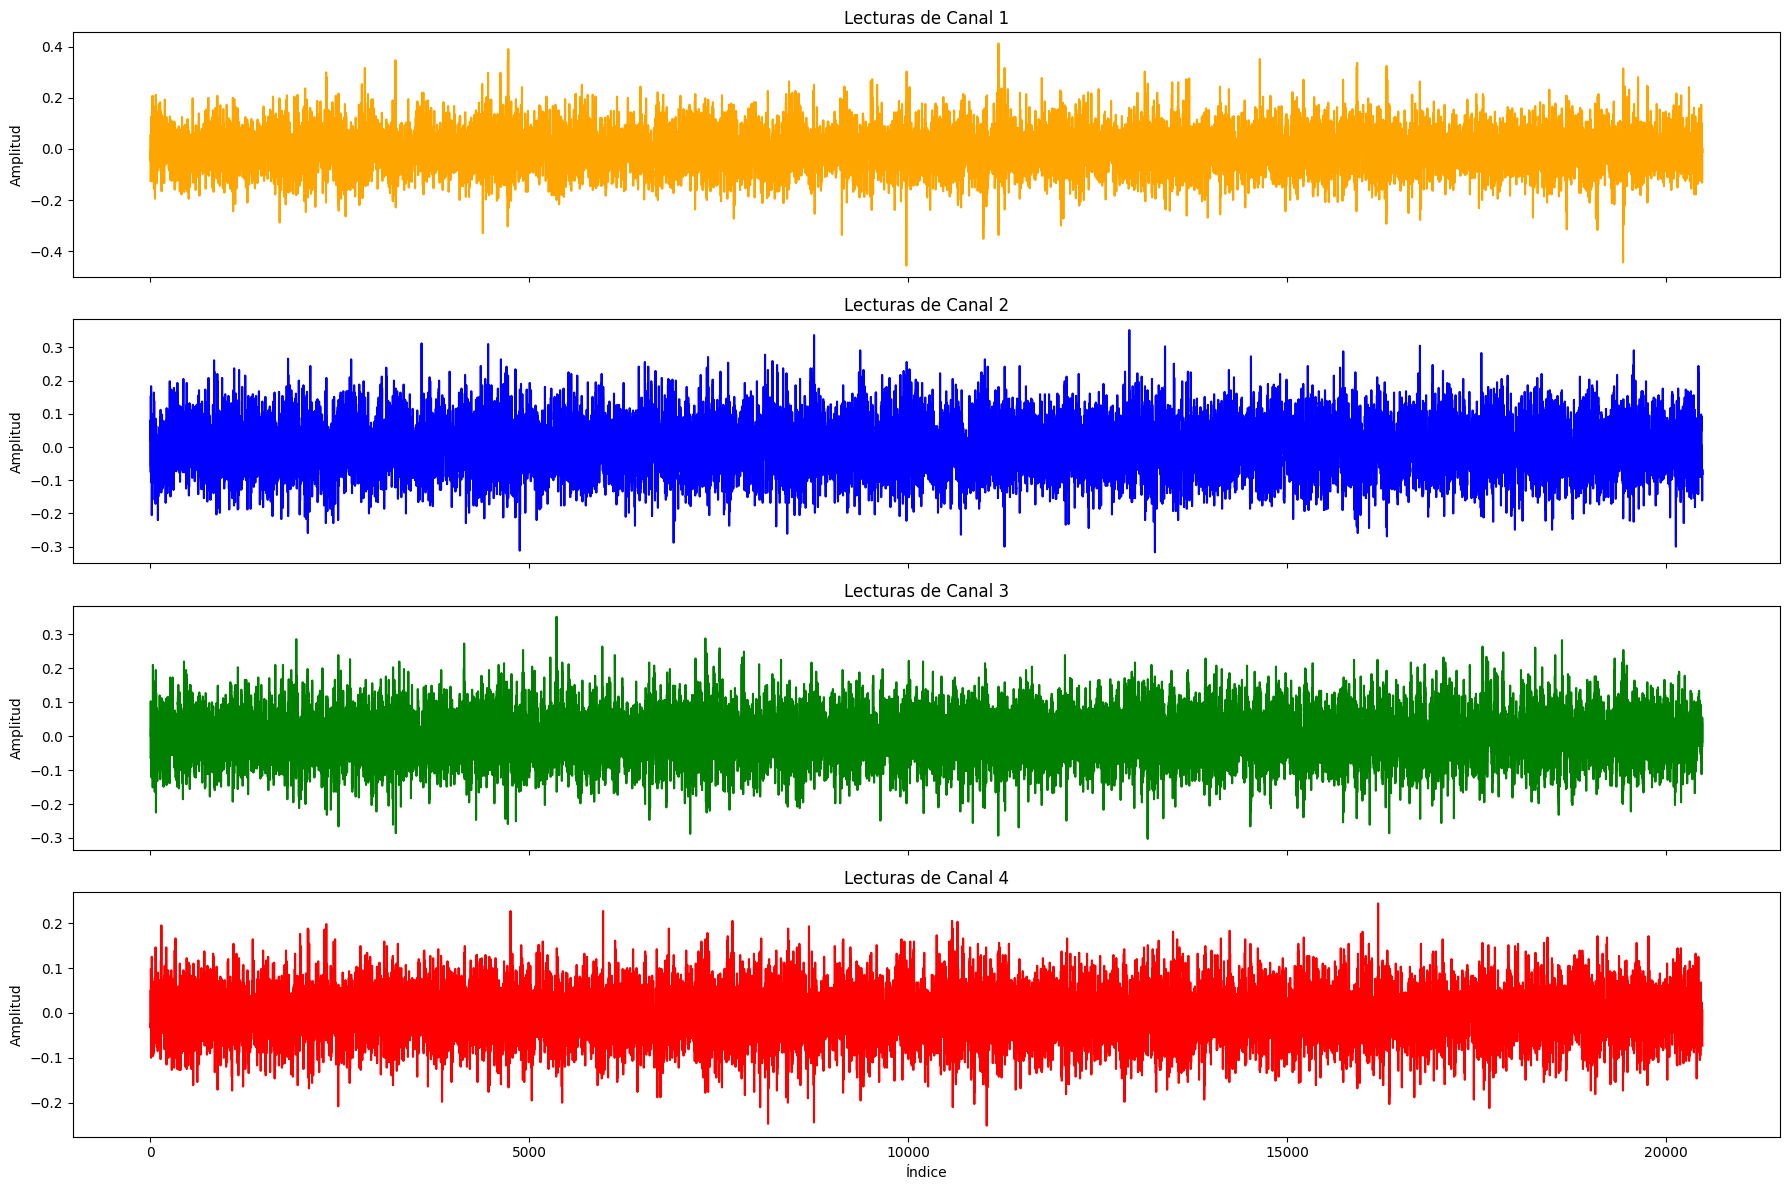

In [103]:
# Visualización de un ejemplo de señal cuadrada (último archivo del 3rd_test)
dataset = cargar_archivo(f'{dataset_path_3rd}/{higher_diffs_3rd_test.iloc[3]["s0"]}')

fig, axs = plt.subplots(4, 1, figsize=(18, 12), sharex=True)

canales = ['Canal 1', 'Canal 2', 'Canal 3', 'Canal 4']
colores = ['orange', 'blue', 'green', 'red']

for i, (canal, color) in enumerate(zip(canales, colores)):
    axs[i].plot(dataset[canal], color=color)
    axs[i].set_title(f'Lecturas de {canal}')
    axs[i].set_ylabel('Amplitud')

axs[-1].set_xlabel('Índice')
plt.tight_layout()
plt.show()

Se observaron las mediciones tanto instantes iniciales y finales que tuvieron un corte de tiempo significativo (mayor al promedio) de interrupción y no se pudo observar ninguna presencia de señales cuadradas. 

### Visualización 1st_test

In [93]:
higher_diffs_1st_test = stamps_1st_test[stamps_1st_test['diff_secs'] > 50000]
higher_diffs_1st_test.sort_values(by='diff_secs', ascending=False)

,s1,s0,diff,diff_secs,diff_mins,diff_h
156,2003.10.29.14.39.46,2003.10.23.10.14.13,6 days 04:25:33,534333.0,8905.550000,148.425833
540,2003.11.07.14.51.44,2003.11.03.14.21.44,4 days 00:30:00,347400.0,5790.000000,96.500000
893,2003.11.14.11.02.17,2003.11.10.16.25.58,3 days 18:36:19,326179.0,5436.316667,90.605278
512,2003.11.03.09.53.55,2003.11.01.23.51.44,1 days 10:02:11,122531.0,2042.183333,34.036389
235,2003.10.31.00.09.46,2003.10.30.03.39.46,0 days 20:30:00,73800.0,1230.000000,20.500000
1435,2003.11.19.09.06.09,2003.11.18.19.12.30,0 days 13:53:39,50019.0,833.650000,13.894167


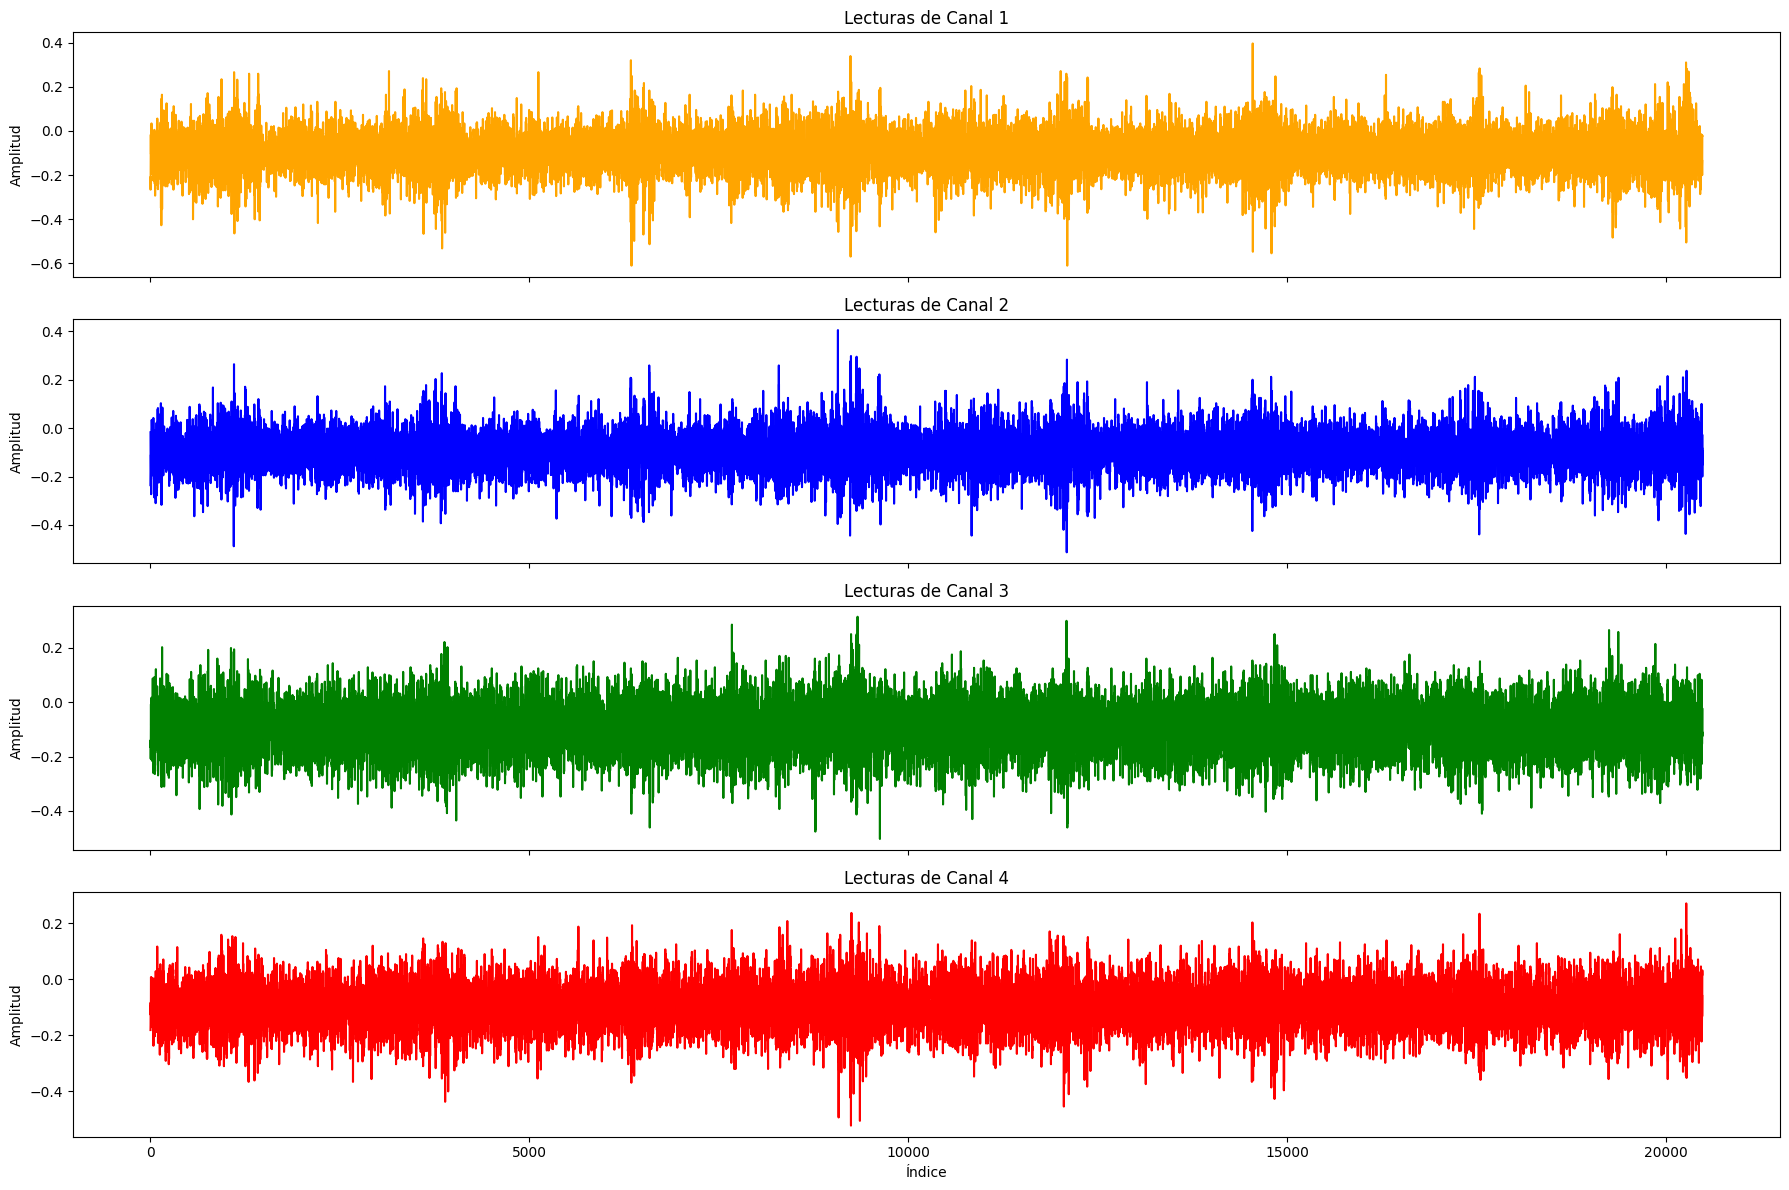

In [109]:
# Visualización de un ejemplo de señal cuadrada (último archivo del 3rd_test)
dataset = cargar_archivo(f'{dataset_path_1st}/{higher_diffs_1st_test.iloc[0]["s0"]}')

fig, axs = plt.subplots(4, 1, figsize=(18, 12), sharex=True)

canales = ['Canal 1', 'Canal 2', 'Canal 3', 'Canal 4']
colores = ['orange', 'blue', 'green', 'red']

for i, (canal, color) in enumerate(zip(canales, colores)):
    axs[i].plot(dataset[canal], color=color)
    axs[i].set_title(f'Lecturas de {canal}')
    axs[i].set_ylabel('Amplitud')

axs[-1].set_xlabel('Índice')
plt.tight_layout()
plt.show()

Al igual que en el 3rd_test se observaron las mediciones tanto instantes iniciales y finales que tuvieron un corte de tiempo significativo (6 mayores valores) de interrupción y no se pudo observar ninguna presencia de señales cuadradas. 

## Conclusiones

* El procedimiento de censado efectivamente presentó cortes durante su operación tal como indicaba la ficha del dataset.
* No se hallaron más señales cuadradas empleando las características estadísticas de las mediciones.
* Las interrupciones no provocaron señales cuadradas.